# 024. テキスト埋め込みと retriever / Text Embedding and Retriever

## 1. 概要 / Overview

**テキスト埋め込み(text embedding)** は、文章を固定次元のベクトルに写し、ベクトルの近さで文章の意味的な近さを測る仕組みである。
query(検索の質問)と passage(検索される文章)を同じ空間に埋め込み、内積の大きい passage を順位づけして返す検索器を
**dense retriever** と呼ぶ。本トピックでは、008 の小型 GPT を encoder として、同じ記事から切り出した 2 つの区間を正例の組にする
教師なしの対照学習(Contriever の independent cropping に相当)で dense retriever を学習し、dual encoder 構造・プーリング・
InfoNCE・Matryoshka Representation Learning・BM25 をスクラッチ実装する。

検証するのは次の 4 つである(いずれも判定つき)。(A)因果マスクのもとで、終端位置のプーリングが平均プールより Recall@10 が高いか、
(B)平均プールで、注意マスクを双方向にすると因果マスクより Recall@10 が高いか、(C)008 の重みから始めると、ランダム初期化から
始めるより Recall@10 が高いか、(D)Matryoshka Representation Learning で学習すると、先頭 16 次元に切り詰めた埋め込みの
Recall@10 が、通常の InfoNCE で学習した埋め込みより高いか。あわせて、判定を設けない観察として、(E)BM25 との比較、(F)対照学習の前後での
異方性(anisotropy)・alignment・uniformity の変化を示す。

### 1.1 実行の手順

本番実行は Google Colab T4 の **1 つのセッションで完結** させる。5.1 節のセットアップセルで`SMOKE_TEST = False`にして、
「すべてのセルを実行」する。

実行時間の予算は 1 セッションあたり **T4 で 120 分** とする。学習を始める前に(6.4 節)、T4 上でのスケーリングの計測(6.3 節)から、
**実行計画**(6.1 節。学習ステップ数 $T$・学習率の較正の方式・**削る段階** の組)のそれぞれについて残りの実行時間を見積もり、予算に収まる
計画のうち優先順位の最も高いものを自動で選ぶ。選択は見積もりのみに基づき、どの実験の結果も参照しない。**選ばれた計画は 6.4 節の
出力に印字される。** 事前の計測のための実行やセッションの分割はしない。

**見積もりが最も下位の計画でも予算を超える場合は、学習の前に停止する。**

学習したモデルのうち、後続のトピック(025)の入力にする **Matryoshka Representation Learning で学習した条件(C5)のシード 0** だけを
Hugging Face Hub(`kojikojiprg/ai-theories-text-embedding-en`)にアップロードする(6.14 節。`UPLOAD_ARTIFACTS`が`True`のときだけ。
既定は`False`)。他のモデルは条件間の比較のためのものであり、保存もアップロードもしない。

### 1.2 本番実行の結果の要約

Google Colab の T4 で 1 セッションで完結した(5.1 節の出力: コミット b68fceb、実行日時 2026-10-06 08:26 UTC、torch 2.13.0+cu130、FP16 の autocast と動的損失スケーリング)。
選ばれた計画は **計画 0**(学習ステップ数 $T = 1024$、全条件の学習率を較正する方式`"all"`、全条件 5 シード。削る段階は適用されなかった)で、全体の実行時間は 64.3 分(予算 120 分、7.8 節)だった。
前提条件 P0〜P2 はすべての実験で成立した(7.2 節)。

| 実験 | 比べたもの(評価用の Recall@10 のシード平均) | 対比量 | $\sigma$ | 閾値($2\sigma$) | 最終判定 |
|---|---|---|---|---|---|
| A | C1(終端位置)0.5702、C2(平均)0.6700 | $\Delta_A = -0.0999$ | 0.0075 | 0.0150 | **反証** |
| B | C3(双方向)0.6779、C2(因果)0.6700 | $\Delta_B = +0.0078$ | 0.0049 | 0.0098 | **判定不能** |
| C | C2(008 の重み)0.6700、C4(ランダム初期化)0.4628 | $\Delta_C = +0.2073$ | 0.0092 | 0.0183 | **支持** |
| D | 先頭 16 次元: C5(Matryoshka Representation Learning)0.5692、C2(通常の InfoNCE)0.3784 | $\Delta_D = +0.1908$ | 0.0074 | 0.0147 | **支持** |

- **実験 A(反証)**: 終端位置のプーリング(C1)は平均プール(C2)より低く、差は 5 シードすべてで負だった。位置ごとの診断量(C2 のモデルで測った量)は、後ろの位置ほど単独の Recall@10 が高い(0.0809 から 0.1729)。
  判定が確かめたのは対比量の向きであり、機構の有無ではない。
- **実験 B(判定不能)**: 双方向の注意(C3)の対比量は正だが閾値に届かなかった。検証用の集合の推移では、序盤は C3 が高く、最後は C2 が高かった。
- **実験 C(支持)**: ランダム初期化(C4)は学習の最後まで検証用の Recall@10 が伸びており、飽和していない状態での比較なので、事前学習の効果の大きさの上限として読む。
- **実験 D(支持)**: 先頭 16 次元で C5 が高く、次元 $m$ が大きいほど差は縮み、全次元($m = 256$)では C5 が C2 より 0.0193 低い(判定に含めない診断量で、検証済みの結論ではない)。
- **観察 E・F**: BM25 の Recall@10(0.7398)は全条件より高かった(最良の dense retriever は C3 の 0.6779)。対照学習の前後で Recall@10 は 0.4834 から 0.6692 に上がったが、ランダムな組のコサイン類似度の平均は 0.4659 から 0.4590 でほぼ変わらなかった(1 本の学習の観察)。
- **アップロード**: C5 のシード 0 を`kojikojiprg/ai-theories-text-embedding-en`にアップロードし、`list_repo_files()`で意図したファイルの存在を確認した。読み込み直した重みの全次元の Recall@10 は 0.6477(7.9 節)。
- 実験 A・B について、なぜそうなったかの考察は **事後的な解釈** として 7.10 節に分けて記した。検証済みの結論ではない。結論の一般化には制約がある(7.10 節: 9,470 記事、約 30% がリスト系、008 の 1 つのチェックポイント、約 0.074 エポックの学習)。

## 2. 参考論文 / References

1. Karpukhin, V., Oğuz, B., Min, S., Lewis, P., Wu, L., Edunov, S., Chen, D., Yih, W.,
   "Dense Passage Retrieval for Open-Domain Question Answering", EMNLP 2020. https://arxiv.org/abs/2004.04906
   (DPR(Dense Passage Retrieval)。dual encoder、in-batch negatives、BM25 による困難な負例。3.2・3.4・3.6 節)
2. Izacard, G., Caron, M., Hosseini, L., Riedel, S., Bojanowski, P., Joulin, A., Grave, E.,
   "Unsupervised Dense Information Retrieval with Contrastive Learning", TMLR 2022. https://arxiv.org/abs/2112.09118
   (Contriever。independent cropping による教師なしの対照学習。本トピックの学習データの作り方の原型。3.6 節)
3. Gao, T., Yao, X., Chen, D.,
   "SimCSE: Simple Contrastive Learning of Sentence Embeddings", EMNLP 2021. https://arxiv.org/abs/2104.08821
   (同じ文を dropout だけ変えて 2 回符号化したものを正例にする。温度 0.05。3.4・3.6 節)
4. Wang, L., Yang, N., Huang, X., Jiao, B., Yang, L., Jiang, D., Majumder, R., Wei, F.,
   "Text Embeddings by Weakly-Supervised Contrastive Pre-training", arXiv:2212.03533, 2022. https://arxiv.org/abs/2212.03533
   (E5。大規模な弱教師の文章の組での対照学習。3.6 節)
5. Wang, L., Yang, N., Huang, X., Yang, L., Majumder, R., Wei, F.,
   "Improving Text Embeddings with Large Language Models", ACL 2024. https://arxiv.org/abs/2401.00368
   (E5-mistral。decoder 型の大規模言語モデルを、終端のトークンの位置の出力で埋め込みモデルに転用する。3.3 節)
6. BehnamGhader, P., Adlakha, V., Mosbach, M., Bahdanau, D., Chapados, N., Reddy, S.,
   "LLM2Vec: Large Language Models Are Secretly Powerful Text Encoders", COLM 2024. https://arxiv.org/abs/2404.05961
   (decoder 型の言語モデルの注意を双方向にして埋め込みモデルに転用する。3.3 節、実験 B)
7. Muennighoff, N.,
   "SGPT: GPT Sentence Embeddings for Semantic Search", arXiv:2202.08904, 2022. https://arxiv.org/abs/2202.08904
   (GPT 型のモデルでの、位置に比例した重みの平均プール。3.3 節、位置づけのみ)
8. Neelakantan, A., Xu, T., Puri, R., Radford, A., et al.,
   "Text and Code Embeddings by Contrastive Pre-Training", arXiv:2201.10005, 2022. https://arxiv.org/abs/2201.10005
   (GPT 型のモデルの終端のトークンの位置の出力を埋め込みにする対照学習。3.3 節)
9. Kusupati, A., Bhatt, G., Rege, A., Wallingford, M., Sinha, A., Ramanujan, V., Howard-Snyder, W., Chen, K.,
   Kakade, S., Jain, P., Farhadi, A.,
   "Matryoshka Representation Learning", NeurIPS 2022. https://arxiv.org/abs/2205.13147
   (入れ子の次元の損失の和。3.7 節、実験 D)
10. Wang, T., Isola, P.,
    "Understanding Contrastive Representation Learning through Alignment and Uniformity on the Hypersphere", ICML 2020.
    https://arxiv.org/abs/2005.10242(alignment と uniformity。3.5 節、観察 F)
11. Ethayarajh, K.,
    "How Contextual are Contextualized Word Representations? Comparing the Geometry of BERT, ELMo, and GPT-2 Embeddings",
    EMNLP 2019. https://arxiv.org/abs/1909.00512(GPT-2 の表現の異方性。3.1 節、観察 F)
12. van den Oord, A., Li, Y., Vinyals, O.,
    "Representation Learning with Contrastive Predictive Coding", arXiv:1807.03748, 2018. https://arxiv.org/abs/1807.03748
    (InfoNCE 損失。020 の 3.4 節で導出済み)
13. Reimers, N., Gurevych, I.,
    "Sentence-BERT: Sentence Embeddings using Siamese BERT-Networks", EMNLP-IJCNLP 2019. https://arxiv.org/abs/1908.10084
    (言語モデルの出力の平均や [CLS] をそのまま文埋め込みにすると性能が低いという観察。3.1 節)
14. Robertson, S., Zaragoza, H.,
    "The Probabilistic Relevance Framework: BM25 and Beyond", Foundations and Trends in Information Retrieval 3(4), 2009.
    https://doi.org/10.1561/1500000019(BM25。3.8 節、観察 E)
15. Thakur, N., Reimers, N., Rücklé, A., Srivastava, A., Gurevych, I.,
    "BEIR: A Heterogeneous Benchmark for Zero-shot Evaluation of Information Retrieval Models", NeurIPS 2021
    (Datasets and Benchmarks Track). https://arxiv.org/abs/2104.08663(語彙の一致に頼る検索と dense retriever の比較。3.8 節、位置づけのみ)
16. Khattab, O., Zaharia, M.,
    "ColBERT: Efficient and Effective Passage Search via Contextualized Late Interaction over BERT", SIGIR 2020.
    https://arxiv.org/abs/2004.12832(late interaction。3.2 節、位置づけのみ)
17. Nogueira, R., Cho, K.,
    "Passage Re-ranking with BERT", arXiv:1901.04085, 2019. https://arxiv.org/abs/1901.04085
    (cross-encoder による再順位づけ。3.2 節。実装は 025)

本文で用いる既存トピックの部品: 小型 GPT と bits-per-byte は [006](../02_pretraining/006_pretraining_small_gpt.ipynb)、AdamW・warmup + cosine・
gradient clipping は [007](../02_pretraining/007_training_stabilization.ipynb)、本トピックが起点にする学習済みの小型 GPT は
[008](../02_pretraining/008_decoding_strategies.ipynb)、FP16 の autocast と動的損失スケーリングは
[011](../03_efficient_training/011_mixed_precision_training.ipynb)、記事を単位とするクラスタブートストラップは
[015](../03_efficient_training/015_long_context_extension.ipynb)、二重 encoder と InfoNCE 損失・InfoNCE が相互情報量の下界であること・温度は
[020](../05_vision_language/020_clip_contrastive_learning.ipynb) で扱った。

## 3. 理論 / Theory

### 3.1 動機: 検索を「同じ空間に埋め込んで内積で順位をつける」問題として定式化する

**検索(retrieval)の設定**: passage の集合 $\mathcal{C} = \{p_1, \dots, p_P\}$ と query $q$ が与えられ、$q$ に関連する passage を上位に並べて返す。
各 query について関連する passage の集合(正解)$G_q \subseteq \mathcal{C}$ が決まっているとし、上位 $k$ 件に正解が入っているかなどで評価する(3.9 節)。

**語彙の一致による検索**: BM25(3.8 節)は、query と passage が共有する語の重みつきの和でスコアをつける。passage ごとの転置索引から高速に
計算でき、強力な基準である一方、同じ意味を別の語で表した query と passage は一致しない(語彙の不一致、vocabulary mismatch)。

**dense retriever**: encoder $f_\theta$ が文章を $d$ 次元のベクトルに写し、query $q$ と passage $p$ の類似度を内積(またはコサイン類似度)で定義する。

$$
s(q, p) = f_\theta(q)^\top f_\theta(p), \qquad \lVert f_\theta(\cdot) \rVert_2 = 1
$$

($\lVert f_\theta(\cdot) \rVert_2 = 1$ は L2 正規化で、そのとき内積はコサイン類似度に一致する。)passage の埋め込みは事前に計算して索引にしておけるので、
query が来たときには query を 1 回符号化して全 passage との内積をとるだけでよい。本トピックは全 passage との内積を厳密に計算する(近似最近傍探索は 025)。

**言語モデルの隠れ状態をそのまま文埋め込みにしない理由**: 008 の小型 GPT の隠れ状態は、次のトークンの予測のために学習されたもので、
文章どうしの類似度を測る目的では学習されていない。次の 2 つの問題が文献で指摘されている。

1. **異方性(anisotropy)**: Ethayarajh [11] は、GPT-2 の文脈つきの表現が、層が深くなるほど狭い錐に偏り、最終層ではランダムな 2 つの
   単語の表現のコサイン類似度の平均が 1 に近いことを報告した。コサイン類似度の平均が大きいと、近さの差が小さな範囲に押し込められる。
   ただし、定数の偏りだけでは順位は変わらないので、異方性そのものが検索の失敗を意味するわけではない。
2. **目的の不一致**: Reimers & Gurevych [13] は、BERT の出力の平均や [CLS] をそのまま文埋め込みにすると、意味的な類似度の課題で GloVe の
   単語ベクトルの平均より低い性能になる場合があることを報告した。

本トピックでは、008 の重みのまま埋め込みとして使った場合の値(Recall@10・異方性・alignment・uniformity)を、対照学習の後と並べて測る(観察 F)。
008 の重みのままの値が低いかどうかは事前には断定せず、測った値を出力する。

### 3.2 dual encoder と cross-encoder

検索の類似度を計算する構造は、query と passage をどの段階で結合するかで 2 つに分かれる。

```mermaid
flowchart LR
    subgraph D["dual encoder(本トピック、DPR・Contriever)"]
        direction LR
        q1["query q"] --> e1["encoder f(重みは共有)"]
        p1["passage p"] --> e2["encoder f(同じ重み)"]
        e1 --> v1["u = f(q)"]
        e2 --> v2["v = f(p)"]
        v1 --> s1["内積 u・v"]
        v2 --> s1
    end
    subgraph X["cross-encoder(025)"]
        direction LR
        q2["query q"] --> c["q と p を連結して 1 本の入力にする"]
        p2["passage p"] --> c
        c --> e3["encoder g"]
        e3 --> s2["スコア g(q, p)"]
    end
```

| | dual encoder | cross-encoder |
|---|---|---|
| 結合の段階 | 出力のベクトルの内積(結合は最後) | 入力の連結(注意機構が query と passage の語どうしを直接参照) |
| passage の事前計算 | **できる**(索引にする) | できない(query ごとに組を符号化する) |
| 1 つの query の計算量 | encoder 1 回 + 内積 $P$ 回 | encoder $P$ 回(全 passage との組) |
| 精度 | 相互作用がないので低くなりうる | 相互作用があり高い |

dual encoder は上位の候補を絞り込むのに、cross-encoder(Nogueira & Cho [17])は絞り込んだ候補の再順位づけ(reranking)に向く。cross-encoder の
実装と、絞り込みと再順位づけの組み合わせは 025 で扱う。**late interaction**(ColBERT、Khattab & Zaharia [16])は、passage をトークンごとの
ベクトルの集合として事前に索引にし、query のトークンごとに最も近い passage のトークンとの内積(MaxSim)を足し合わせる中間の方式で、
位置づけのみとする(本トピックでは実装しない)。

dual encoder では、query と passage で **同じ重みの encoder** を使う(重みの共有。Contriever [2])場合と、別々の encoder を使う場合(DPR [1])がある。
本トピックは重みを共有する。

### 3.3 プーリング: 系列の隠れ状態から 1 本のベクトルを作る

encoder の最終正規化層の後の隠れ状態を $H = (h_0, \dots, h_{S-1}) \in \mathbb{R}^{S \times d}$ とする($S$ は系列長、$d = 256$ は隠れ次元)。
文埋め込みは、$H$ から 1 本のベクトル $z \in \mathbb{R}^d$ を作り(プーリング、pooling)、L2 正規化したもの $u = z / \lVert z \rVert_2$ である。
本トピックは射影層を置かず、次元は $d = 256$ のままとする。

| 方式 | $z$ | 備考 |
|---|---|---|
| 平均プール(mean pooling) | $\frac{1}{S} \sum_{t=0}^{S-1} h_t$ | E5 [4]・Contriever [2]・Sentence-BERT [13] |
| 終端位置(last-token pooling) | $h_{S-1}$ | E5-mistral [5]・cpt-text [8] |
| [CLS] | 先頭に置いた特別なトークンの出力 $h_0$ | encoder 型(双方向の注意)の BERT など |

**因果マスクのもとでの位置 $t$ の出力が見ているもの**: 008 の小型 GPT は因果マスク(causal mask)を使うので、位置 $t$ の隠れ状態 $h_t$ は
位置 $t$ までのトークン $x_0, \dots, x_t$ にだけ依存し、$t$ より後のトークンを見ていない(001)。したがって、

- 入力の **全体** を見ているのは、最後の位置の出力 $h_{S-1}$ だけである。
- 先頭の位置の出力 $h_0$ は、第 1 トークンだけに依存する。そのため、[CLS] のように先頭の位置を使う方式は、因果マスクのもとでは入力全体の要約にならない。
  encoder 型の [CLS] は、双方向の注意で全体を見られることを前提にした方式である。
- 平均プールは、前半の位置の出力(文脈が短い)と後半の位置の出力(文脈が長い)を等しい重みで平均する。SGPT [7] は、後ろの位置ほど多くの文脈を見ているので、
  位置 $t$ に比例した重み $w_t \propto t + 1$ の平均が良いことを報告した(位置づけのみ。本トピックでは実装しない)。

**decoder 型の言語モデルを埋め込みモデルに転用する流れ**: cpt-text [8] と E5-mistral [5] は、入力の末尾に終端のトークンを加え、その位置の出力を埋め込みにする。
これらの文献が末尾の位置を使う根拠は、因果マスクのもとで入力全体を見ている位置が末尾だけだという整理である。LLM2Vec [6] は、因果マスクを外して注意を **双方向** にし、さらに追加の学習(マスクされたトークンの
次トークン予測と、教師なしの対照学習)を行うことで、decoder 型の言語モデルを強い埋め込みモデルに転用した。双方向の注意は、事前学習で見ていない入力になる
(位置 $t$ の出力が、$t$ より後のトークンにも依存する)ので、追加の学習なしに注意を双方向にしたときの性能はモデルによって異なると報告されている [6]。

**008 のトークナイザには終端の特殊トークンがない**(語彙は 256 個のバイトと 7,936 個のマージで 8,192 個、特殊トークンなし。5.4 節で確かめる)。そのため終端位置のプーリングは、
**入力の最後の位置の出力** を使う。query と passage は固定長でパディングを使わないので、最後の位置は常に最後のトークンの位置である。

以上は文献の整理であり、主に大規模なモデルでの結果に基づく。008 の小型 GPT と本トピックの学習量で成り立つかは、本トピックの実験 A・B で確かめる: (A)因果マスクのもとで、入力全体を見ている終端位置のプーリングが、平均プールより良いか。(B)平均プールで、注意を双方向にして全位置が入力全体を見られるようにすると、因果マスクより良いか。

結果は 7.3・7.4 節、考察は 7.10 節に記した(文献の整理が本トピックの設定でそのまま成り立つとは限らない)。

### 3.4 対照学習の損失: InfoNCE、in-batch negatives、温度

正例の組 $(q_i, p_i^+)$ が $N$ 組あるバッチを考える。$u_i = f_\theta(q_i)$、$v_j = f_\theta(p_j^+)$ を L2 正規化した埋め込み、
$s_{ij} = u_i^\top v_j$ をコサイン類似度、$\tau > 0$ を温度とする。**in-batch negatives**(バッチ内負例)は、i 番目の query にとって、同じバッチの
他の $N - 1$ 個の passage $p_j^+$($j \neq i$)を負例とする方法で、負例のための追加の符号化が要らない(DPR [1])。損失は

$$
\mathcal{L}_{\mathrm{NCE}} = -\frac{1}{N} \sum_{i=1}^{N} \log \frac{\exp(s_{ii} / \tau)}{\sum_{j=1}^{N} \exp(s_{ij} / \tau)}
$$

である($\mathcal{L}_{\mathrm{NCE}}$ の添字は InfoNCE の NCE。query から passage への方向。passage から query への方向も足して対称にする流儀(CLIP、020)もある)。この形は 020 の 3.3 節の対称な InfoNCE 損失の片方の
向きと同じで、InfoNCE が相互情報量の下界になること($I(X; Y) \ge \log N - \mathcal{L}_{\mathrm{NCE}}$)と、下界が $\log N$ で頭打ちになるので
負例の数 $N$ が効くことは、020 の 3.4 節で導出済みである(ここでは再導出しない)。

**温度 $\tau$**: $\tau$ が小さいほど softmax が鋭くなり、類似度の高い負例(困難な負例)の勾配への寄与が大きくなる。SimCSE [3] は $\tau = 0.05$、E5 [4] は $\tau = 0.01$ を使う。
020 では $\log(1/\tau)$ を学習したが、本トピックは $\tau = 0.05$ に **固定** する(条件間で揃える量)。

**バッチの作り方の注意(偽の負例)**: in-batch negatives は、同じバッチの他の組の passage を「負例」とみなす。同じ記事から切り出した別の組が同じバッチに入ると、
その passage は query にとって実際には関連があり(同じ記事の区間)、負例として押しのけると意味的に近いものを遠ざけてしまう(偽の負例、false negative)。
本トピックは **1 つのバッチに同じ記事の組を 2 つ以上入れない**(5.4 節で確かめる)。

### 3.5 alignment と uniformity、異方性

Wang & Isola [10] は、単位球面上の埋め込みを学ぶ対照学習の損失が、次の 2 つの性質を同時に最適化することを示した。

$$
\mathcal{L}_{\mathrm{align}} = \mathbb{E}_{(x, y) \sim p_{\mathrm{pos}}} \left[ \lVert f(x) - f(y) \rVert_2^{\alpha} \right], \qquad
\mathcal{L}_{\mathrm{uniform}} = \log \mathbb{E}_{x, y \sim p_{\mathrm{data}}} \left[ e^{-t \lVert f(x) - f(y) \rVert_2^{2}} \right]
$$

- $p_{\mathrm{pos}}$: 正例の組の分布、$p_{\mathrm{data}}$: データの分布(独立に 2 つ引く)。$\alpha = 2$、$t = 2$ が原論文の既定値である。
- **alignment**: 正例の組の埋め込みの距離。小さいほど正例が近い。
- **uniformity**: 埋め込みが単位球面にどれだけ一様に広がっているか。小さい(より負の)ほど一様で、全部が 1 点に潰れると 0 になる。

異方性の指標は、ランダムな 2 つの埋め込みのコサイン類似度の平均 $\mathbb{E}_{x \neq y}[f(x)^\top f(y)]$ である [11]。1 に近いほど、埋め込みが狭い錐に偏っている。
uniformity と同様に、偏りの度合いを測るが、uniformity は距離の分布全体に、異方性は平均に注目する。
5.2 節以降で、対照学習の前後でこれらを測る(観察 F)。

### 3.6 正例の作り方の系譜

対照学習の正例の組をどう作るかが、手法の違いの中心である。

```mermaid
flowchart TD
    A["正例の組の作り方"] --> B["同じ入力の変換"]
    A --> C["同じ文書の別の区間"]
    A --> D["人手のラベル"]
    A --> E["弱教師(自然に対応づく文章の組)"]
    B --> B1["SimCSE: 同じ文を dropout だけ変えて 2 回符号化"]
    C --> C1["Contriever: independent cropping(同じ文書から 2 つの区間、重なりを許す)"]
    C1 --> C2["本トピック: 同じ記事から重ならない 2 つの区間"]
    D --> D1["DPR: 質問と答えを含む passage + BM25 による困難な負例"]
    E --> E1["E5: 大規模な弱教師の組で事前学習し、ラベルつきデータで微調整"]
```

- **SimCSE** [3]: 同じ文を、dropout の乱数だけ変えて 2 回 encoder に通し、2 つの出力を正例にする。データの拡張が要らず、教師なし。
- **Contriever** [2]: 同じ文書から 2 つの区間を独立に切り出して正例にする(independent cropping)。2 つの区間は **重なってもよい**。重なると語の一致だけで正例を当てられるので、
  語彙の一致に頼らない表現を学ぶ目的には不利になりうる。本トピックは **重ならないように** 切り出す(`src/data/retrieval.py`の`sample_pair_schedule()`)。
- **DPR** [1]: 質問と、答えを含む passage のラベルつきの組を使う。**困難な負例(hard negative)** として、BM25 で上位に来たが答えを含まない passage を各質問に 1 個加える。
  in-batch negatives が「簡単な負例」(無関係な passage)であるのに対し、BM25 の上位は語彙が似ているので、区別が難しい。
- **E5** [4]: ウェブから集めた、自然に対応する文章の組(質問と回答、見出しと本文など)で事前学習し、ラベルつきのデータで微調整する。

**偽の負例(false negative)**: 困難な負例は、語彙や意味が正例に近い passage を負例として使うので、実際には正解である passage を負例にしてしまう危険が大きくなる。
**困難な負例は本トピックでは理論のみとし、実験には使わない。** 本トピックの負例は in-batch negatives だけで、バッチ内に同じ記事の組を入れないことで偽の負例を避ける。

### 3.7 Matryoshka Representation Learning

通常の埋め込みは $d$ 次元すべてを使って初めて意味を持つ。次元を減らして索引のメモリや内積の計算量を減らしたいときは、あとから主成分分析で圧縮するなどが必要になる。
Matryoshka Representation Learning(Kusupati et al. [9])は、**先頭の $m$ 次元だけを取り出しても使える** ように、入れ子の次元の集合
$\mathcal{M} = \{m_1 < m_2 < \dots < m_K = d\}$ のそれぞれについて損失を計算して足し合わせる。

$$
\mathcal{L}_{\mathrm{Matryoshka}} = \sum_{m \in \mathcal{M}} c_m \, \mathcal{L}_{\mathrm{NCE}}^{(m)}
$$

$\mathcal{L}_{\mathrm{NCE}}^{(m)}$ は、プーリングで得た正規化前のベクトル $z$ の **先頭 $m$ 次元を取り出して、L2 正規化し直した** 埋め込み
$u^{(m)} = z_{1:m} / \lVert z_{1:m} \rVert_2$ で計算した 3.4 節の InfoNCE 損失、$c_m \ge 0$ は次元ごとの重みである。

**切り詰めた後の再正規化**: 切り詰めたベクトルのノルムは 1 より小さくなるので、そのままでは内積がコサイン類似度にならない。切り詰めた後に L2 正規化し直す。
$m = d$ のときは通常の埋め込みと一致する。

**重み $c_m$**: 原論文は $c_m = 1$ を使う。本トピックは $c_m = 1 / \lvert \mathcal{M} \rvert$(平均)にする。全体が $\lvert \mathcal{M} \rvert$ 倍になるだけで最適解は変わらず、
AdamW の更新は損失の尺度に依らない。違いが出るのは gradient clipping が発動しないステップの勾配のノルムだけで、平均にすると通常の InfoNCE と尺度が揃う。

**原論文との違い**: 原論文は ImageNet の分類で、各次元の先頭 $m$ 個を入力とする線形分類器を持つ。検索への適用では、各次元の埋め込みの InfoNCE 損失を足し合わせる形が使われる。
本トピックはこの形(各 $m$ について再正規化した埋め込みの InfoNCE)を使う。入れ子の次元は等比の $\mathcal{M} = \{16, 32, 64, 128, 256\}$ とする。

**索引のメモリとの関係**: $P$ 個の passage を FP32 の $m$ 次元の埋め込みで持つ索引のメモリは $4 P m$ バイトで、$m$ に比例する。$m = 256 \to 16$ で 16 分の 1 になる。
この利得を実際の索引で扱うのは 025 である。

### 3.8 BM25 と、語彙の一致に頼る検索

BM25(Robertson & Zaragoza [14])は、query $q$ の語 $t$ の集合について、passage $D$ のスコアを次の和で与える。

$$
\mathrm{BM25}(D, q) = \sum_{t \in q} \mathrm{IDF}(t) \cdot \frac{f(t, D) \, (k_1 + 1)}{f(t, D) + k_1 \left( 1 - b + b \, \dfrac{\lvert D \rvert}{\mathrm{avgdl}} \right)}, \qquad
\mathrm{IDF}(t) = \ln \left( 1 + \frac{P - n(t) + 0.5}{n(t) + 0.5} \right)
$$

- $f(t, D)$: 語 $t$ の passage $D$ での出現回数。$\lvert D \rvert$: passage の長さ(トークン数)。$\mathrm{avgdl}$: 全 passage の平均の長さ。
- $P$: passage の数。$n(t)$: 語 $t$ を含む passage の数。$\mathrm{IDF}(t)$: 逆文書頻度(inverse document frequency)で、多くの passage に現れる語ほど小さい。
  上の式は Lucene と同じ、常に正になる形である。
- $k_1$: 語の出現回数の飽和の強さ(既定値 1.2)。$b$: passage の長さの正規化の強さ(既定値 0.75)。query の語は重複を除いた集合として足す。

本トピックの BM25 は **BPE(Byte Pair Encoding)のトークン ID の列** を入力にする(`src/retrieval/bm25.py`)。passage が固定長なので $\lvert D \rvert = \mathrm{avgdl}$ で、長さの正規化の項は定数 1 になり、$b$ は結果に影響しない。

**語彙の一致に頼る検索と dense retriever の得意・不得意**(BEIR、Thakur et al. [15] の知見の紹介のみ。本トピックでは検証しない): 18 のデータセットでの
ゼロショットの評価で、BM25 は頑健な基準で、特定のデータセットで学習した dense retriever は、学習した領域と異なる領域の多くで BM25 を下回った。語の一致が強い手がかりになる
課題(固有名詞、専門用語)では BM25 が強く、語が違っても意味が近い query と passage の対応(言い換え)では dense retriever が強い。両者は補い合うので、組み合わせて使われる。
本トピックの観察 E は、同じ索引と query で BM25 と各条件の値を並べるだけで、優劣は判定しない。

### 3.9 評価指標: Recall@k、MRR、nDCG

query $i$ について、正解の集合を $G_i$(同じ記事の他の passage)、候補を類似度の降順に並べたときの最も上位の正解の順位を $r_i$ とする。
**query を含む passage は候補から除く。**

- **Recall@k**: 上位 $k$ 件に正解が 1 つ以上あれば 1、なければ 0 を、query について平均した値。

$$
\mathrm{Recall@}k = \frac{1}{Q} \sum_{i=1}^{Q} \mathbb{1}[r_i \le k]
$$

- **MRR**(Mean Reciprocal Rank): 最も上位の正解の順位の逆数の平均。

$$
\mathrm{MRR} = \frac{1}{Q} \sum_{i=1}^{Q} \frac{1}{r_i}
$$

- **nDCG@k**(normalized Discounted Cumulative Gain): 順位 $j$ の候補が正解かどうかを $\mathrm{rel}_j \in \{0, 1\}$ として

$$
\mathrm{DCG@}k = \sum_{j=1}^{k} \frac{\mathrm{rel}_j}{\log_2 (j + 1)}, \qquad
\mathrm{nDCG@}k = \frac{\mathrm{DCG@}k}{\mathrm{IDCG@}k}, \qquad
\mathrm{IDCG@}k = \sum_{j=1}^{\min(\lvert G_i \rvert, k)} \frac{1}{\log_2 (j + 1)}
$$

($Q$ は query の数。$\mathrm{IDCG@}k$ は正解が上位から並んだ理想の順序での $\mathrm{DCG@}k$。)

本トピックの主指標は Recall@10 で、MRR と nDCG@10 を診断量として印字する。Recall@k は上位 $k$ 件の中の順序を見ず、MRR は最上位の正解だけを見る。
同点は、最も上位の正解と同じ以上のスコアを持つ正解でない候補の数に 1 を加えた値を順位とする(正解に不利な向き)。

**ランダムな順位の期待値**: 候補が $M$ 個で正解が $g$ 個のとき、ランダムに並べて上位 $k$ 件に正解が 1 つもない確率は $\binom{M - g}{k} / \binom{M}{k}$ なので、
Recall@k の期待値は $1 - \binom{M - g}{k} / \binom{M}{k}$ である(query について平均する)。前提条件(6.1 節)で使う。

### 3.10 データの流れとアルゴリズム(擬似コード)

```
学習:
  入力: 学習用の記事、query の長さ L_q、passage の長さ L_p、バッチサイズ N、温度 tau、学習ステップ数 T
  前処理(学習の前に全ステップぶんを作る):
    各ステップで N 個の記事を、重みに比例する確率で非復元抽出する         # 1 つのバッチに同じ記事の組は 2 つ入らない
    各記事から、重ならない長さ L_q と長さ L_p の区間を切り出す(query 側と passage 側)
  各ステップ:
    z_q = pool(encoder(query))、z_p = pool(encoder(passage))              # 同じ重みの encoder。pool は平均または終端位置
    通常の InfoNCE:   u = normalize(z_q)、v = normalize(z_p)、 L = InfoNCE(u, v, tau)
    Matryoshka Representation Learning:  L = sum_m c_m InfoNCE(normalize(z_q[:m]), normalize(z_p[:m]), tau)
    勾配 -> gradient clipping -> AdamW の更新(学習率は warmup + cosine)

評価:
  索引: 評価用の記事を重ならない長さ L_p の passage に分け、埋め込みにする(記事ごとに passage 数の上限あり)
  query: 索引の passage の一部(長さ L_q)。その query を含む passage は、その query の候補から除く
  全件の内積で順位をつけ、Recall@10 (主指標)・MRR・nDCG@10 を求める
```

## 4. 実装方針 / Implementation Policy

**`src/`に切り出す(スクラッチ実装、本トピックで新規作成)**:

- `src/models/text_embedding.py`: 小型 GPT を包む埋め込みモデル`TextEmbeddingModel`(プーリング(平均・終端位置)、注意マスクの切り替え(因果・双方向)、
  L2 正規化)。最終正規化層の後の隠れ状態`compute_hidden_states()`、次元の切り詰めと再正規化`truncate_and_normalize()`、固定長のトークン列を FP32 で符号化する
  `encode_tokens()`(切り詰める次元の一覧と、指定した位置の出力の埋め込みも一度に返す)。既存の`GPTLanguageModel`は変更しない。
- `src/data/retrieval.py`: 記事を単位とする学習用・検証用・評価用の分割`split_articles()`(使ってよい記事の候補の中から決定的に選ぶ)、使う記事だけの記事ごとの符号化、評価用の索引と query の構成
  `build_retrieval_set()`(記事ごとの passage 数の上限つき、決定的)、学習の組の切り出し`sample_pair_schedule()`(重ならない 2 つの区間、1 つのバッチに同じ記事を入れない)。
  025 から同じ評価用の passage の集合を再構成できる。
- `src/training/contrastive_text.py`: in-batch negatives の InfoNCE`info_nce_loss()`、Matryoshka Representation Learning の損失`matryoshka_representation_loss()`、
  学習ループ`train_text_embedding()`、同じ組での損失の測定`compute_pair_losses()`(更新なしの損失)。020 の`src/training/contrastive.py`の`softmax_contrastive_loss()`は参照実装として単体テストで使い(温度を固定した対称な損失と一致する)、
  学習の部品(007 の`AdamW`・warmup + cosine・gradient clipping、011 の`DynamicLossScaler`、019 の`split_weight_decay_parameters()`・
  `unscale_gradients_and_compute_norm()`)は再利用する。
- `src/retrieval/bm25.py`: BM25 のスクラッチ実装`BM25Index`(転置索引、トークン ID の列を入力とする)。
- `src/retrieval/evaluation.py`: 全件の内積による厳密な探索での Recall@k・MRR・nDCG@10`rank_candidates()`・`evaluate_embeddings()`、ランダムな順位の期待値
  `expected_random_recall()`、異方性`mean_pairwise_cosine()`・`alignment()`・`uniformity()`。近似最近傍探索は使わない。

**既存モジュールの扱い**: `src/`は新しいファイルの追加のみである。`scripts/`では、コーパスのアーティファクトの運用スクリプト`scripts/promote_canonical_corpora.py`の英語のスペックに、
記事の境界(`article_offsets`)の追加の対象にするフラグを足した。したがって既存の挙動が変わらないことは、変更前のコミットとの差分が、そのスクリプトの追加の行と説明の 1 行の書き換えだけであることで確かめる
(5.4 節)。因果マスクを外す経路は、`GPTLanguageModel.forward()`を変更せず、`TextEmbeddingModel`が各層の`DecoderBlock`を直接呼んで実現する
(`attention="causal"`のとき`src/models/reward_model.py`の`compute_final_hidden_states()`と bit 単位で一致する)。

**ノートブック内に直接書く(024 固有)**: 条件の定義、データの分割の確認、単体テストと不変条件の確認、学習率の較正、実行計画の選択、判定、可視化、スケーリングの計測、Hub へのアップロード。

**生成物の置き場所**:

| 生成物 | 置き場所 |
|---|---|
| Hugging Face Hub から取得したコーパス・トークナイザ・008 の学習済みモデル | `huggingface_hub`の既定のキャッシュ(Colab ではセッションの終了とともに破棄される) |
| 符号化したトークン列・評価用の索引と query | メモリ上のみ(`.cache/`には置かない。同一セッションの中で全条件・全シードが共有する) |
| 学習したモデル(C5 のシード 0 を除く) | メモリ上のみ(評価の直後に破棄する) |
| C5 のシード 0 の学習後の重み | メモリ上に保持し、6.14 節でアップロードの対象にする(`.cache/`には置かない) |
| 学習の履歴・query ごとの順位 | メモリ上のみ(判定と図に使う) |
| 判定の記録 | 判定と前提条件を計算した各セルの出力(6.7〜6.10・6.13 節) |
| アップロードしたモデル | Hugging Face Hub の`kojikojiprg/ai-theories-text-embedding-en`(新規、public。`UPLOAD_ARTIFACTS`が`True`のときのみ) |

**外部からの取得**(Colab のセットアップセルのリポジトリの取得と依存関係のインストールを除く):

| 取得するもの | リポジトリ | 用途 |
|---|---|---|
| コーパス(`corpus.txt`・`metadata.json`) | `kojikojiprg/ai-theories-corpus-en`(Dataset、9,826 記事、約 546 MB) | 学習・評価の英語 Wikipedia のコーパスと、記事の境界(`article_offsets`)。Wikipedia API にはフォールバックしない |
| 参照コーパス(`corpus.txt`) | `kojikojiprg/ai-theories-corpus-en-pretraining`(Dataset、356 記事、約 24 MB) | 008 の事前学習とトークナイザの学習に使ったコーパス。上のコーパスの先頭と同一であることの確認と、008 が使った範囲の特定 |
| トークナイザ(`tokenizer.json`) | `kojikojiprg/ai-theories-tokenizer-en` | 008 の英語の BPE(Byte Pair Encoding)トークナイザ(語彙サイズ 8192) |
| 008 の学習済みモデル(`config.json`・`model_state.pt`、`main`) | `kojikojiprg/ai-theories-small-gpt-en` | 条件 C1・C2・C3・C5 の初期値 |

**アップロード方針**: アップロードするのは C5(Matryoshka Representation Learning)のシード 0 のモデルだけで、結果を見て選ばない(後続の 025 の入力になるため)。
トークナイザは同梱せず、モデルカードで`kojikojiprg/ai-theories-tokenizer-en`を参照する。モデルカードの指標は、アップロードする重みそのものを読み込み直して評価した値とする。

## 5. 実装 / Implementation

### 5.1 環境セットアップ(Google Colab)

`SMOKE_TEST`(スモークテストか本番か)はこのセルでのみ切り替える。実行環境はこのセルで 1 回だけ印字する。

**本番のコミットの確認**: `SMOKE_TEST = False`のときだけ、(1)追跡しているファイルに未コミットの変更がないこと、(2)`REQUIRED_ANCESTOR_COMMIT`が指定されていれば、
それが HEAD の祖先であることを確かめ、満たさなければ学習の前に停止する。追跡外のファイルは停止の条件にせず、あれば一覧を参考として印字する。

**精度と決定性**: 学習は、CUDA のときは FP16 の`torch.autocast`と動的損失スケーリング(011 の`DynamicLossScaler`)で行い、それ以外のデバイス(ローカルの MPS(Metal Performance Shaders、Apple Silicon の GPU 用のバックエンド)・CPU)では FP32 で行う。
埋め込みの正規化・類似度・損失・評価は常に FP32 で行う。`torch.use_deterministic_algorithms(True)`は使わない。同じシードの学習を繰り返しても結果が bit 単位では
一致しないことがあるが、条件間の対応付け(同じシードの条件どうしで学習の組と順序を揃えること)は乱数の生成器によって決まり、演算の決定性には依存しない(5.5・6.12 節で確かめる)。

In [1]:
# 環境セットアップ(Google Colab)
import os
import sys
import time

SMOKE_TEST = False  # Claude Code はこの True 側のみ実行する(Colab T4 では False に切り替える)
UPLOAD_ARTIFACTS = True  # 6.14 節。既定は False(Colab Secrets の HF_TOKEN を使ってアップロードするときだけ True)

NOTEBOOK_START_TIME = time.time()

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    if not os.path.isdir("/content/ai-theories"):  # 2 回目の実行では clone し直さない
        !git clone https://github.com/kojikojiprg/ai-theories.git /content/ai-theories
    %cd /content/ai-theories
    !pip install uv -q
    !uv pip install --system -r requirements.txt

# インストールで版が入れ替わったパッケージの古い版がメモリに残っていないかを、torch などを import する前に確かめる。
# Colab では食い違いがあればカーネルを終了する(再接続後、もう一度「すべてのセルを実行」する)
from src.utils.environment import check_preloaded_package_versions  # noqa: E402

check_preloaded_package_versions(on_mismatch="restart" if IN_COLAB else "raise")

import torch  # noqa: E402

from src.utils.environment import print_execution_environment  # noqa: E402

device = torch.device(
    "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
)
USE_FP16_AUTOCAST = device.type == "cuda"  # FP16 の autocast と動的損失スケーリングは CUDA のときのみ
execution_environment = print_execution_environment(device)

# 本番(SMOKE_TEST = False)は、追跡しているファイルに未コミットの変更がない状態で実行する。第 1 段階の完了の後に修正を行った場合は、
# その修正を含むコミットを REQUIRED_ANCESTOR_COMMIT に指定する(HEAD がその子孫であることを確かめる)
REQUIRED_ANCESTOR_COMMIT = None
if not SMOKE_TEST:
    import subprocess

    _head = subprocess.run(["git", "rev-parse", "HEAD"], capture_output=True, text=True, check=True).stdout.strip()
    _status = subprocess.run(
        ["git", "status", "--porcelain", "--untracked-files=no"], capture_output=True, text=True, check=True
    ).stdout.strip()
    _untracked = subprocess.run(
        ["git", "ls-files", "--others", "--exclude-standard"], capture_output=True, text=True, check=True
    ).stdout.split()
    _is_descendant = REQUIRED_ANCESTOR_COMMIT is None or (
        subprocess.run(["git", "merge-base", "--is-ancestor", REQUIRED_ANCESTOR_COMMIT, "HEAD"]).returncode == 0
    )
    if not _is_descendant or _status:
        raise RuntimeError(
            f"本番の実行条件を満たさないため、学習の前に停止する(結果の情報は何も得ていない)。HEAD {_head[:7]}、"
            f"{REQUIRED_ANCESTOR_COMMIT} の子孫か: {_is_descendant}、追跡しているファイルの未コミットの変更: {_status or 'なし'}。"
            "リポジトリを最新の main に更新し、変更をなくして再実行すること。"
        )
    print(
        f"本番の実行条件: HEAD {_head[:7]}、追跡しているファイルに未コミットの変更がない"
        f"、必要な祖先のコミット {REQUIRED_ANCESTOR_COMMIT}: OK(参考: 追跡外のファイル {_untracked or 'なし'})"
    )
print(
    f"SMOKE_TEST={SMOKE_TEST}、学習の精度 {'FP16 の autocast + 動的損失スケーリング' if USE_FP16_AUTOCAST else 'FP32'}"
    f"(埋め込みの正規化・損失・評価は FP32)、決定的な演算の強制: {torch.are_deterministic_algorithms_enabled()}"
)

/content/ai-theories
Using Python 3.13.15 environment at: /usr
Checked 60 packages in 507ms
読み込み済みのパッケージの版の検査(requirements.txt): 食い違いなし。検査した配布物 11 個(certifi==2026.7.22, cycler==0.12.1, fonttools==4.63.0, kiwisolver==1.5.0, matplotlib==3.11.1, numpy==2.5.2, packaging==26.3, pillow==12.3.0, pyparsing==3.3.2, python-dateutil==2.9.0.post0, six==1.17.0)、未読み込みのため検査しなかった配布物 44 個、__version__ がないため比べなかった配布物 0 個(なし)、表記の違いで誤検出するため比べなかった配布物 0 個(なし)
実行環境 / Execution environment
  Python                                 : 3.13.15
  OS / platform                          : Linux-6.6.122+-x86_64-with-glibc2.39
  torch                                  : 2.13.0+cu130
  torch のビルド時の CUDA                : 13.0
  cuDNN                                  : 92000
  デバイス / device                      : cuda
  GPU 名 / GPU name                      : Tesla T4
  compute capability                     : 7.5
  GPU の総メモリ (GiB)                   : 14.56
  コミット / git commit                  : b68fceb94bb90538fc1cdf52dcd

In [2]:
import functools
import gc
import hashlib
import itertools
import json
import math
import resource
import subprocess
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from src.data.retrieval import (
    build_retrieval_set,
    compute_article_sampling_weights,
    concatenate_articles,
    encode_articles,
    find_articles_starting_at_or_after,
    sample_pair_schedule,
    select_evenly,
    split_articles,
)
from src.data.text import locate_wikipedia_article_spans, split_train_val_text
from src.data.tokenizer import load_bpe_id_tokenizer_from_hub
from src.layers.feedforward import SwiGLUFeedForwardNetwork
from src.layers.normalization import RMSNorm
from src.layers.positional_encoding import RotaryPositionEmbedding
from src.models.gpt import GPTLanguageModel
from src.models.reward_model import compute_final_hidden_states
from src.models.text_embedding import (
    TextEmbeddingModel,
    compute_hidden_states,
    encode_tokens,
    truncate_and_normalize,
)
from src.retrieval.bm25 import BM25Index
from src.retrieval.evaluation import (
    alignment,
    evaluate_embeddings,
    expected_random_recall,
    mean_pairwise_cosine,
    rank_candidates,
    uniformity,
)
from src.training.contrastive import softmax_contrastive_loss
from src.training.contrastive_text import (
    compute_pair_losses,
    info_nce_loss,
    matryoshka_representation_loss,
    train_text_embedding,
)
from src.utils.reporting import dumps_compact_json
from src.utils.statistics import fit_power_law_exponent, paired_cluster_bootstrap_ratio_of_sums

ROOT = Path.cwd()
WIKIPEDIA_CACHE_DIR = ROOT / ".cache" / "wikipedia_en"  # locate_wikipedia_article_spans() の引数(記事の境界は metadata.json から得るので、Wikipedia API には接続しない)
CORPUS_REPO_ID = "kojikojiprg/ai-theories-corpus-en"  # 9,826 記事。使うのは先頭の 356 記事を除く 9,470 記事
REFERENCE_CORPUS_REPO_ID = "kojikojiprg/ai-theories-corpus-en-pretraining"  # 008 の事前学習と英語のトークナイザの学習に使ったコーパス(CORPUS_REPO_ID の先頭の 356 記事と同一)
TOKENIZER_REPO_ID = "kojikojiprg/ai-theories-tokenizer-en"
REFERENCE_MODEL_REPO_ID = "kojikojiprg/ai-theories-small-gpt-en"  # 008 の学習済みモデル(条件 C1・C2・C3・C5 の初期値)
UPLOAD_REPO_ID = "kojikojiprg/ai-theories-text-embedding-en"
MANIFEST_PATH = ROOT / "src" / "data" / "wikipedia_manifests" / "en_009_scaling.json"
REFERENCE_MANIFEST_PATH = ROOT / "src" / "data" / "wikipedia_manifests" / "en_006_pretraining.json"
RUN_TAG = "[スモークテスト] " if SMOKE_TEST else ""
PLOT_TAG = "[smoke test] " if SMOKE_TEST else ""


def sync_device() -> None:
    # 時間計測の直前・直後に、非同期に実行される GPU の処理の完了を待つ。
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps":
        torch.mps.synchronize()


def empty_device_cache() -> None:
    if device.type == "cuda":
        torch.cuda.empty_cache()
    elif device.type == "mps":
        torch.mps.empty_cache()


def timed_call(function) -> float:
    sync_device()
    start = time.time()
    function()
    sync_device()
    return time.time() - start


def rounded(values, digits: int = 4):
    # 印字用: 入れ子のリスト・配列を丸めたリストにする
    return np.round(np.asarray(values, dtype=np.float64), digits).tolist()


precondition_status: dict[str, bool] = {}  # 前提条件の成否(6.1 節で宣言、各節で記録)

### 5.2 スケールの設定(`SMOKE_TEST`の配線)

水準の定義をこの 1 箇所に集約する。

**縮小の規則**: スモークテストは、本番と **同じモデル・同じデータ・同じ条件・同じ実行計画の構造** で、次の量だけを縮小する。

- **学習ステップ数 $T$ の候補**: 本番 $(1024, 512, 256)$、スモークテスト $(16, 8, 4)$。どちらも大きい順で、隣どうしの比が 2 の等比という構造を保つ。
- **シード数**: 本番は 5(削った段階で 3)、スモークテストは 3(削った段階で 2)。「削る前 > 削った後 $\ge 2$」の順序関係を保つ。
- **ブートストラップの反復回数**: 本番 10,000 回、スモークテスト 1,000 回。

評価用の索引・query・検証用の集合は縮小しない(評価は数秒で終わるため、本番と同じ集合でコードの経路を確かめる)。スモークテストはステップ数が極端に少ないので、
学習は進まず、前提条件は成立しない見込みである(コードの経路の確認が目的)。**較正・前提条件・検出力の確認は、6.2 節のパイロットで本番と同じステップ数で行った。**

**縮小しないもの**: モデルの構成、データの分割、バッチサイズ、query と passage の長さ、条件の対応表、学習率の較正の格子と拡張の規則、学習率のスケジュールの形、
途中の評価の位置の決め方($T$ に対する割合)、実行計画の表の構造と優先順位、前提条件と判定の閾値、スケーリングの計測点。

**テスト専用の上書き**: 環境変数`AI_THEORIES_FORCE_PLAN`が設定されているときのみ、6.4 節で見積もりによる計画の選択の代わりにその計画を使う(スモークテストで下位の計画の経路を
確かめるため)。本番では受け付けず、このセルで停止する。コミットする出力は上書きなしの実行のものである。

**実効水準の照合**: このセルで印字した水準(ステップ数・シード数・計画の表)が、実際の学習で使われた値と一致することを 6.12 節のアサーションで確かめる(`SMOKE_TEST`の配線漏れの検出)。

In [3]:
# --- 全水準で共通の定数(本番実行前に宣言し、SMOKE_TEST で変えない) ---
# モデル(008 と同じ小型 GPT。構成は Hub の config.json から読む)
EMBEDDING_DIMENSION = 256
MATRYOSHKA_DIMENSIONS = (16, 32, 64, 128, 256)  # 入れ子の次元の集合 M(等比、公比 2)
# データ(5.3 節)
QUERY_LENGTH, PASSAGE_LENGTH = 32, 128  # L_q、L_p(固定長、パディングなし)
MAX_PASSAGES_PER_ARTICLE = 12  # 記事ごとの索引の passage 数の上限(学習で記事を選ぶ重みにも同じ上限を使う)
MAX_QUERIES_PER_ARTICLE = 12
NUM_VALIDATION_ARTICLES, NUM_EVALUATION_ARTICLES, NUM_TRAIN_PROBE_ARTICLES = 100, 300, 120  # 学習用は候補の残りの全記事
SPLIT_SEED, EVALUATION_SET_SEED, VALIDATION_SET_SEED, TRAIN_PROBE_SEED = 24_001, 24_002, 24_003, 24_004
REFERENCE_VALIDATION_RATIO = 0.05  # 008 の事前学習と英語のトークナイザの学習は、参照コーパスの末尾 5% を使っていない
COLAB_RAM_GIB = 12.7  # Colab 無料枠の RAM(メモリ使用量の見込みの判定に使う)
RAM_FRACTION_LIMIT = 0.75  # ピークのメモリ使用量が RAM のこの割合以下であること
LIST_LIKE_TITLE_PREFIXES = ("List of", "Lists of", "Timeline of", "Outline of", "Index of", "Glossary of", "Bibliography of", "Comparison of", "Discography", "Filmography", "Deaths in", "Births in")
EVAL_ENCODE_BATCH = 256  # 評価の 1 回の順伝播の系列の数(結果には影響しない)
# 学習(008 のレシピに準じる)
BATCH_SIZE = 64  # N
TEMPERATURE = 0.05  # tau(固定)
WEIGHT_DECAY = 0.1
WARMUP_RATIO = 0.1
MIN_LEARNING_RATE_RATIO = 0.01
GRADIENT_CLIP_THRESHOLD = 1.0
INIT_LOSS_SCALE = 2.0**16  # 動的損失スケーリング(019〜022 と同じ)
LOSS_SCALE_GROWTH_INTERVAL = 2000
# 条件の対応表(6.1 節)
CONDITIONS = {
    "C1": {"init": "pretrained", "attention": "causal", "pooling": "last", "loss": "infonce", "track": False},
    "C2": {"init": "pretrained", "attention": "causal", "pooling": "mean", "loss": "infonce", "track": True},
    "C3": {"init": "pretrained", "attention": "bidirectional", "pooling": "mean", "loss": "infonce", "track": True},
    "C4": {"init": "random", "attention": "causal", "pooling": "mean", "loss": "infonce", "track": True},
    "C5": {"init": "pretrained", "attention": "causal", "pooling": "mean", "loss": "matryoshka", "track": False},
}
RUN_ORDER = ("C2", "C1", "C3", "C5", "C4")  # 本番の学習の順
# 学習率の較正(6.1 節)。中心は 6.2 節のパイロットで決めた
LEARNING_RATE_CENTER = {"C1": 0.00024, "C2": 0.00048, "C3": 0.00024, "C4": 0.0006, "C5": 0.00048}
LEARNING_RATE_GRID_MULTIPLIERS = (0.25, 1.0, 4.0)  # 格子 = 中心 x {1/4, 1, 4}(公比 4。6.1 節)
LEARNING_RATE_GRID_RATIO = 4.0
REPRESENTATIVE_CALIBRATED = ("C2", "C4")  # 較正の方式 "representative" で較正する条件
REPRESENTATIVE_RULE = {"C1": "C2", "C3": "C2", "C5": "C2"}  # 規則で決める条件 -> 基にする条件(C2 の較正で選ばれた値 x その条件の格子の中心 / C2 の格子の中心)
# 途中の評価の位置(T に対する割合、初期に密な等比の間隔)。検証用の集合の Recall@10 を測る(C2・C3・C4 のみ)
EVAL_FRACTIONS = (1 / 64, 1 / 32, 1 / 16, 1 / 8, 1 / 4, 1 / 2, 1.0)
# 位置ごとの診断量(実験 A): 系列の長さに対する割合。位置 = ceil(割合 x 長さ) - 1
POSITION_FRACTIONS = (1 / 32, 1 / 16, 1 / 8, 1 / 4, 1 / 2, 1.0)
# 前提条件と判定(6.1 節)
P1_LOSS_RATIO = 0.9  # P1(a): 008 の重みから始める条件の最後の区間の訓練損失 <= 同じ組での学習前のモデルの損失 x この値
FINAL_LOSS_FRACTION = 0.05  # 「最初の区間」「最後の区間」= 最初・最後の 5% のステップ
P1_RECALL_GAIN = 0.04  # P1(b): C2 の検証用の集合の Recall@10 >= 学習前の 008(C2 の構成)の検証用の Recall@10 + この値
P2_RECALL_CEILING = 0.95  # P2(改善の余地): 基準となる条件の Recall@10 <= この値
SIGMA_MULTIPLIER = 2.0  # 判定の閾値は対比量の標準偏差の 2 倍
# 乱数シード(学習のシード s: 学習の組 24100 + s、ランダム初期化 24200 + s)
PAIR_SEED_BASE, INIT_SEED_BASE = 24_100, 24_200
CALIBRATION_SEED_INDEX = 90  # 学習率の較正専用のシード(実験のシード 0〜4 と共有しない)
TIMING_SEED_INDEX = 91  # スケーリングの計測専用のシード
BOOTSTRAP_SEED = 24_600
SESSION_BUDGET_SECONDS = 120 * 60  # 1 セッションの予算(T4 で 120 分)
OBSERVATION_RUN = ("C2", 0)  # 観察 F の「後」に使う学習(C2、シード 0)
UPLOAD_RUN = ("C5", 0)  # Hub にアップロードする学習(結果を見て選ばない)

# --- 水準(SMOKE_TEST で変わるもの) ---
LEVELS = {
    "smoke": {"STEP_CANDIDATES": (16, 8, 4), "BOOTSTRAP_RESAMPLES": 1_000},
    "prod": {"STEP_CANDIDATES": (1024, 512, 256), "BOOTSTRAP_RESAMPLES": 10_000},
}
# 削る段階(6.1 節)。順序: 較正の方式 -> C5 のシード数 -> C4 のシード数(T を下げるのは最後)
STAGES = {
    "prod": {
        0: {"mode": "all", "seeds": {"C1": 5, "C2": 5, "C3": 5, "C4": 5, "C5": 5}},
        1: {"mode": "representative", "seeds": {"C1": 5, "C2": 5, "C3": 5, "C4": 5, "C5": 5}},
        2: {"mode": "representative", "seeds": {"C1": 5, "C2": 5, "C3": 5, "C4": 5, "C5": 3}},
        3: {"mode": "representative", "seeds": {"C1": 5, "C2": 5, "C3": 5, "C4": 3, "C5": 3}},
    },
    "smoke": {  # 本番と同じ構造(シード数 5 -> 3 を 3 -> 2 に縮小)
        0: {"mode": "all", "seeds": {"C1": 3, "C2": 3, "C3": 3, "C4": 3, "C5": 3}},
        1: {"mode": "representative", "seeds": {"C1": 3, "C2": 3, "C3": 3, "C4": 3, "C5": 3}},
        2: {"mode": "representative", "seeds": {"C1": 3, "C2": 3, "C3": 3, "C4": 3, "C5": 2}},
        3: {"mode": "representative", "seeds": {"C1": 3, "C2": 3, "C3": 3, "C4": 2, "C5": 2}},
    },
}
NUM_STAGES = 4
# スケーリングの計測点(6.3 節)。水準によらず同じ
SCALING_STEP_COUNTS = (8, 16, 32)
SCALING_WARMUP_STEPS = 8
SCALING_ENCODE_CHARACTERS = (8_000_000, 16_000_000, 32_000_000)  # 使う記事の先頭から、重ならない区間を順に符号化して計測する

CURRENT_LEVEL_NAME = "smoke" if SMOKE_TEST else "prod"
LEVEL_SETTINGS = LEVELS[CURRENT_LEVEL_NAME]
STEP_CANDIDATES = LEVEL_SETTINGS["STEP_CANDIDATES"]
BOOTSTRAP_RESAMPLES = LEVEL_SETTINGS["BOOTSTRAP_RESAMPLES"]


def build_plans(step_candidates) -> list[dict]:
    # 実行計画(6.1 節): 学習ステップ数 T(大きい順)-> 削る段階(0 -> 3。段階が較正の方式とシード数を決める)
    plans = [{"num_steps": t, "stage": k} for t in step_candidates for k in range(NUM_STAGES)]
    return [{"plan": i} | p for i, p in enumerate(plans)]


PLANS = build_plans(STEP_CANDIDATES)
FORCED_PLAN_VALUE = os.environ.get("AI_THEORIES_FORCE_PLAN")
if FORCED_PLAN_VALUE is not None and not SMOKE_TEST:
    raise RuntimeError(
        f"本番(SMOKE_TEST=False)では計画の強制(AI_THEORIES_FORCE_PLAN={FORCED_PLAN_VALUE!r})を受け付けない。"
        "環境変数を削除して再実行すること。"
    )
FORCED_PLAN = None if FORCED_PLAN_VALUE is None else int(FORCED_PLAN_VALUE)
assert FORCED_PLAN is None or 0 <= FORCED_PLAN < len(PLANS), FORCED_PLAN
# T・較正の方式・段階・シード数は 6.4 節で実行計画を選んだ後に決まる


def warmup_steps_for(num_steps: int) -> int:
    return max(1, round(WARMUP_RATIO * num_steps))


def eval_steps_for(num_steps: int) -> tuple[int, ...]:
    # 途中の評価のステップ(重複は除く。最後は必ず T)
    return tuple(sorted({max(1, round(f * num_steps)) for f in EVAL_FRACTIONS}))


def final_loss_window(num_steps: int) -> int:
    return max(1, round(FINAL_LOSS_FRACTION * num_steps))


def learning_rate_grid_for(condition: str) -> tuple[float, ...]:
    return tuple(LEARNING_RATE_CENTER[condition] * m for m in LEARNING_RATE_GRID_MULTIPLIERS)


def calibration_targets(mode: str, seeds: dict) -> list[str]:
    # 較正する条件。"all" は学習する全条件、"representative" は C2 と C4 のみ(6.1 節)
    if mode == "all":
        return [c for c in RUN_ORDER if seeds[c] > 0]
    return [c for c in REPRESENTATIVE_CALIBRATED if seeds[c] > 0]


def position_for(fraction: float, length: int) -> int:
    return math.ceil(fraction * length) - 1


# --- 縮小規則と水準の構造の確認 ---
assert set(LEVELS["smoke"]) == set(LEVELS["prod"])
for _name in LEVELS:
    _candidates = LEVELS[_name]["STEP_CANDIDATES"]
    assert len(_candidates) == 3 and list(_candidates) == sorted(_candidates, reverse=True)
    assert all(b == round(_candidates[0] / 2**j) for j, b in enumerate(_candidates))  # 等比(公比 1/2)
    for _t in _candidates:
        assert eval_steps_for(_t)[-1] == _t and warmup_steps_for(_t) < _t
assert LEVELS["smoke"]["BOOTSTRAP_RESAMPLES"] < LEVELS["prod"]["BOOTSTRAP_RESAMPLES"]
for _name, _stages in STAGES.items():
    assert set(_stages) == set(range(NUM_STAGES))
    for _k in range(NUM_STAGES):
        assert set(_stages[_k]["seeds"]) == set(CONDITIONS) and all(v >= 2 for v in _stages[_k]["seeds"].values())
        assert _stages[_k]["seeds"]["C2"] == _stages[0]["seeds"]["C2"]  # 基準の条件は削らない
        assert _stages[_k]["mode"] == ("all" if _k == 0 else "representative")
        if _k > 0:  # 段階が上がるほど、較正の方式かシード数が 1 つだけ削られる
            _changes = int(_stages[_k]["mode"] != _stages[_k - 1]["mode"]) + sum(
                _stages[_k]["seeds"][c] != _stages[_k - 1]["seeds"][c] for c in CONDITIONS
            )
            assert _changes == 1 and all(_stages[_k]["seeds"][c] <= _stages[_k - 1]["seeds"][c] for c in CONDITIONS)
for _k in range(1, NUM_STAGES):  # 本番とスモークテストで、各段階で何が変わるかが同じ(構造を保つ縮小)
    for _c in CONDITIONS:
        assert (STAGES["prod"][_k]["seeds"][_c] == STAGES["prod"][_k - 1]["seeds"][_c]) == (
            STAGES["smoke"][_k]["seeds"][_c] == STAGES["smoke"][_k - 1]["seeds"][_c]
        )
assert len(PLANS) == 3 * NUM_STAGES and [p["plan"] for p in PLANS] == list(range(len(PLANS)))
assert all(b == 2 * a for a, b in itertools.pairwise(SCALING_STEP_COUNTS))
assert all(b == 2 * a for a, b in itertools.pairwise(SCALING_ENCODE_CHARACTERS))
assert all(math.isclose(b / a, 2.0) for a, b in itertools.pairwise(EVAL_FRACTIONS))  # 途中の評価の位置は等比
assert all(math.isclose(b / a, 2.0) for a, b in itertools.pairwise(POSITION_FRACTIONS))  # 位置の診断量の水準は等比
assert all(math.isclose(b / a, 2.0) for a, b in itertools.pairwise(MATRYOSHKA_DIMENSIONS))  # 入れ子の次元は等比
assert MATRYOSHKA_DIMENSIONS[-1] == EMBEDDING_DIMENSION
for _c in CONDITIONS:
    assert all(math.isclose(b / a, LEARNING_RATE_GRID_RATIO) for a, b in itertools.pairwise(learning_rate_grid_for(_c)))
assert set(REPRESENTATIVE_RULE) | set(REPRESENTATIVE_CALIBRATED) == set(CONDITIONS)
assert set(RUN_ORDER) == set(CONDITIONS)
assert QUERY_LENGTH <= PASSAGE_LENGTH <= 256  # passage は 008 の学習長(256)以内

print(f"水準 {CURRENT_LEVEL_NAME!r}: {json.dumps(LEVEL_SETTINGS)}")
print(
    f"データ: query {QUERY_LENGTH} トークン、passage {PASSAGE_LENGTH} トークン(固定長、パディングなし)、記事ごとの passage 数の上限 {MAX_PASSAGES_PER_ARTICLE}、"
    f"検証用 {NUM_VALIDATION_ARTICLES} 記事・評価用 {NUM_EVALUATION_ARTICLES} 記事"
)
print(
    f"学習: バッチ {BATCH_SIZE} 組(in-batch negatives)、温度 {TEMPERATURE}(固定)、AdamW(重み減衰 {WEIGHT_DECAY}、foreach)、"
    f"warmup {WARMUP_RATIO:.0%} + cosine(下限 x{MIN_LEARNING_RATE_RATIO})、gradient clipping {GRADIENT_CLIP_THRESHOLD}。"
    f"入れ子の次元 {MATRYOSHKA_DIMENSIONS}"
)
print(f"条件: {dumps_compact_json(CONDITIONS)}")
print("学習率の格子: " + "、".join(f"{c} {tuple(float(f'{x:.3g}') for x in learning_rate_grid_for(c))}" for c in CONDITIONS))
for _t in STEP_CANDIDATES:
    print(f"  T = {_t}: warmup {warmup_steps_for(_t)}、途中の評価のステップ {eval_steps_for(_t)}、最後の区間 {final_loss_window(_t)} ステップ")
print(f"削る段階({CURRENT_LEVEL_NAME!r}): {dumps_compact_json(STAGES[CURRENT_LEVEL_NAME])}")
print(
    f"実行計画: {len(PLANS)} 通り(番号の小さいほど優先)。計画番号 = {NUM_STAGES} x(T の番号)+ 段階。"
    f"T の候補 {STEP_CANDIDATES}、段階 0〜{NUM_STAGES - 1}"
)
print(f"スケーリングの計測点: ステップ数 {SCALING_STEP_COUNTS}(ウォームアップ {SCALING_WARMUP_STEPS})")
if FORCED_PLAN is not None:
    print(f"*** テスト専用の上書き: AI_THEORIES_FORCE_PLAN = {FORCED_PLAN}(6.4 節で見積もりの代わりにこの計画を使う) ***")

水準 'prod': {"STEP_CANDIDATES": [1024, 512, 256], "BOOTSTRAP_RESAMPLES": 10000}
データ: query 32 トークン、passage 128 トークン(固定長、パディングなし)、記事ごとの passage 数の上限 12、検証用 100 記事・評価用 300 記事
学習: バッチ 64 組(in-batch negatives)、温度 0.05(固定)、AdamW(重み減衰 0.1、foreach)、warmup 10% + cosine(下限 x0.01)、gradient clipping 1.0。入れ子の次元 (16, 32, 64, 128, 256)
条件: {
  "C1": {
    "init": "pretrained",
    "attention": "causal",
    "pooling": "last",
    "loss": "infonce",
    "track": false
  },
  "C2": {
    "init": "pretrained",
    "attention": "causal",
    "pooling": "mean",
    "loss": "infonce",
    "track": true
  },
  "C3": {
    "init": "pretrained",
    "attention": "bidirectional",
    "pooling": "mean",
    "loss": "infonce",
    "track": true
  },
  "C4": {
    "init": "random",
    "attention": "causal",
    "pooling": "mean",
    "loss": "infonce",
    "track": true
  },
  "C5": {
    "init": "pretrained",
    "attention": "causal",
    "pooling": "mean",
    "loss": "matryoshka",
    "track": false
  }
}
学習

### 5.3 データ: 記事の分割・符号化・評価用の索引と query

**コーパスとトークナイザ**: 英語 Wikipedia のコーパス(`kojikojiprg/ai-theories-corpus-en`、9,826 記事)と、008 の BPE(Byte Pair Encoding)トークナイザ
(語彙サイズ 8192、`kojikojiprg/ai-theories-tokenizer-en`)を使う。記事の境界は`metadata.json`の`article_offsets`から得て、`corpus.txt`との整合を検証する。
トークナイザに特殊トークンがないこと(終端トークンの有無)を確かめて印字する。

**使う記事と、008・トークナイザの学習範囲との関係**: このコーパスの先頭の 356 記事は、008 の事前学習とトークナイザの学習に使ったコーパス
(`kojikojiprg/ai-theories-corpus-en-pretraining`、以下「参照コーパス」)と同一である(タイトル・リビジョン ID・本文を確かめる)。008 は参照コーパスの先頭 95% だけで事前学習し、
トークナイザも同じ範囲で学習している。**先頭の 356 記事は、学習用・検証用・評価用のどれにも使わない。** 使うのは、参照コーパスの全体の外に始まる 9,470 記事で、
008 もトークナイザも、そのどの記事も一度も見ていない(使う記事の開始位置の最小が参照コーパスの長さ以上であることを、文字位置の範囲のアサーションで確かめる)。
そのため、C2(008 の重みから始める)が事前学習で記事の内容を記憶していることによる有利さは、評価に混ざらない。

追加の記事は、Wikipedia の長大記事の一覧(Special:LongPages)から長い順に選んだもので、平均的な記事ではない。**約 30% がリスト系の記事**(タイトルが`List of`・`Timeline of`・
`Deaths in`などで始まる。実際の割合は下のセルの出力に印字する)である。リスト系の記事は、列挙の構造が繰り返されるため、同じ記事の区間どうしの語の重なりが通常の記事と異なりうる
(本トピックでは測っていない)。結果の一般化の制約として 7 節で扱う。

**記事を単位とする分割**(`src/data/retrieval.py`の`split_articles()`、決定的。使う記事の中から選ぶ):

| 部分 | 記事の数 | 用途 |
|---|---|---|
| 学習用 | 使う記事の残りの全部(検索に使えない短い記事を含む) | 対照学習の組の切り出し(組を作れない短い記事は使われない) |
| 検証用 | 100 | 学習率の較正と、学習の途中の評価(実験 B・C の診断量)にのみ使う |
| 評価用 | 300 | 判定と診断量に使う |

検証用・評価用の記事は、passage を 2 個以上持つ記事(トークン数が $2 L_p$ 以上)から、固定したシードの並べ替えの先頭から選ぶ(評価用が先頭の 300、検証用が次の 100)。
3 つの部分は互いに素で、和集合が使う記事になる(このセルのアサーションと、分割のダイジェストの印字で確かめる)。

**評価用の索引と query**: 評価用の記事を、重ならない長さ $L_p = 128$ の passage に分けて索引にする(記事の全体から等間隔に選び、記事ごとに最大 12 個)。
query は、索引の passage のうち記事ごとに等間隔に選んだ最大 12 個の一部(長さ $L_q = 32$、passage の中の位置はシード付きの乱数で決める)で、**その query を含む passage は、
その query の候補から除く**。正解は同じ記事の他の passage である。記事ごとの passage 数に上限を設けるのは、記事の長さが極端に偏る(中央値 約 1.4 万トークン、最長 約 12.5 万トークン)ので、
上限がないと最長の記事 1 本が索引の多くを占め、正解が大量にあって検索が易しくなるためである。検証用の集合も同じ構成で作る。

**学習の組**: 学習用の記事から、長さ $L_q = 32$ の query 側の区間と長さ $L_p = 128$ の passage 側の区間を、**重ならないように** 切り出す。Contriever(independent cropping)は
2 つの区間が重なることを許すが、重なると語の一致だけで正例を当てられるので、本トピックは重ならないようにする。1 つのバッチ(64 組)には同じ記事の組を 2 つ以上入れない。
記事は、長さ $L_p$ の窓の数(最大 12 で頭打ち)に比例する確率で非復元抽出する。

**学習用の部分の索引(汎化の差の診断量)**: 学習用の記事のうち固定した 120 本で、評価用と同じ構成の索引と query(`train_probe`)を作り、各学習の最終ステップで Recall@10 を測る。
学習用の記事は学習で見ているので、評価用との差は汎化の差と分布の違い(索引の大きさの違いを含む)の両方を含む。そのため差の絶対値ではなく、**条件間での差の違い** を読む。

In [4]:
_t0_data = time.time()
DATA_SECONDS_BY_STAGE: dict[str, float] = {}
PEAK_MEMORY_GIB_BY_STAGE: dict[str, float] = {}


def peak_memory_gib() -> float:
    # このプロセスのこれまでのピークのメモリ使用量(macOS は単位がバイト、Linux は KiB)
    peak = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
    return peak / (1024**3 if sys.platform == "darwin" else 1024**2)


def total_memory_gib() -> float | None:
    try:
        return os.sysconf("SC_PAGE_SIZE") * os.sysconf("SC_PHYS_PAGES") / 1024**3
    except (ValueError, OSError, AttributeError):
        return None


def end_stage(name: str, started: float) -> None:
    DATA_SECONDS_BY_STAGE[name] = time.time() - started
    PEAK_MEMORY_GIB_BY_STAGE[name] = peak_memory_gib()


_stage = time.time()
tokenizer, _tokenizer_from_hub = load_bpe_id_tokenizer_from_hub(TOKENIZER_REPO_ID)
assert _tokenizer_from_hub, "トークナイザを Hugging Face Hub から取得できなかった"
assert tokenizer.vocab_size == 8192

# 終端の特殊トークンの有無: 語彙は 256 個のバイトの記号と、マージで作った記号だけである(特殊トークンの記号を持たない)
_bpe = tokenizer.bpe_tokenizer
HAS_SPECIAL_TOKENS = len(_bpe.vocab) != 256 + len(_bpe.merges) or any(
    s.startswith("<") and s.endswith(">") and len(s) > 2 for s in tokenizer.symbol_to_id
)
assert not HAS_SPECIAL_TOKENS and tokenizer.vocab_size == 256 + len(_bpe.merges)
end_stage("トークナイザの取得", _stage)

# --- 参照コーパス(008 の事前学習と英語のトークナイザの学習に使ったコーパス)---
from huggingface_hub import hf_hub_download  # noqa: E402

_stage = time.time()
_reference_text = Path(hf_hub_download(REFERENCE_CORPUS_REPO_ID, "corpus.txt", repo_type="dataset")).read_text(encoding="utf-8")
REFERENCE_CORPUS_CHARACTERS = len(_reference_text)
_reference_train_text, _ = split_train_val_text(_reference_text, REFERENCE_VALIDATION_RATIO)
REFERENCE_PRETRAINING_END = len(_reference_train_text)  # 008 とトークナイザが使った範囲の終わり(文字位置)
del _reference_train_text
_manifest_items = list(json.loads(MANIFEST_PATH.read_text(encoding="utf-8")).items())
_reference_items = list(json.loads(REFERENCE_MANIFEST_PATH.read_text(encoding="utf-8")).items())
NUM_REFERENCE_ARTICLES = len(_reference_items)
assert _manifest_items[:NUM_REFERENCE_ARTICLES] == _reference_items, "先頭の記事のタイトルとリビジョン ID が参照コーパスのマニフェストと一致しない"
end_stage("参照コーパスの取得", _stage)

# --- コーパス(Hub から取得する。Wikipedia API にはフォールバックしない)---
_stage = time.time()
_corpus_path = hf_hub_download(CORPUS_REPO_ID, "corpus.txt", repo_type="dataset")
_metadata_path = hf_hub_download(CORPUS_REPO_ID, "metadata.json", repo_type="dataset")
end_stage("コーパスのダウンロード", _stage)
_stage = time.time()
corpus_metadata = json.loads(Path(_metadata_path).read_text(encoding="utf-8"))
assert corpus_metadata["manifest"] == MANIFEST_PATH.name and corpus_metadata["manifest_article_count"] == len(_manifest_items)
assert "article_offsets" in corpus_metadata, "metadata.json に article_offsets がない"
assert os.path.getsize(_corpus_path) == corpus_metadata["raw_bytes"], "コーパスの取得が破損している"
corpus_text = Path(_corpus_path).read_text(encoding="utf-8")
assert corpus_text.startswith(_reference_text) and corpus_text[REFERENCE_CORPUS_CHARACTERS] == "\n", "先頭が参照コーパスと一致しない"
del _reference_text
end_stage("コーパスの読み込み", _stage)

_stage = time.time()
article_spans, ARTICLE_SPANS_SOURCE = locate_wikipedia_article_spans(
    corpus_text, "en", WIKIPEDIA_CACHE_DIR, MANIFEST_PATH, metadata_path=_metadata_path, start_position=0
)
assert ARTICLE_SPANS_SOURCE == "metadata", "article_offsets を metadata.json から取得できなかった"
NUM_ARTICLES = len(article_spans)
assert NUM_ARTICLES == len(_manifest_items)
end_stage("記事の境界の検証", _stage)

# --- 使う記事: 参照コーパスの外に始まる記事だけ(先頭の記事は学習用・検証用・評価用のどれにも使わない)---
CANDIDATE_ARTICLES = find_articles_starting_at_or_after(article_spans, REFERENCE_CORPUS_CHARACTERS)
assert CANDIDATE_ARTICLES == list(range(NUM_REFERENCE_ARTICLES, NUM_ARTICLES)), "使う記事が先頭の記事を除く全記事と一致しない"
assert article_spans[NUM_REFERENCE_ARTICLES - 1]["end"] == REFERENCE_CORPUS_CHARACTERS, "先頭の記事の末尾が参照コーパスの末尾と一致しない"
assert article_spans[CANDIDATE_ARTICLES[0]]["start"] == REFERENCE_CORPUS_CHARACTERS + 1 > REFERENCE_PRETRAINING_END

# --- 記事ごとの符号化(時間のスケーリングを 3 点で計測してから、使う記事を符号化する)---
_stage = time.time()
_candidate_start = article_spans[CANDIDATE_ARTICLES[0]]["start"]
_candidate_characters = article_spans[-1]["end"] - _candidate_start
_encode_times, _encode_position = [], _candidate_start
for _n in SCALING_ENCODE_CHARACTERS:  # 区間は重ならない(同じ文章を繰り返し符号化して、語の単位の記憶で速くなる効果を避ける)
    _start = time.time()
    tokenizer.encode(corpus_text[_encode_position : _encode_position + _n])
    _encode_times.append(time.time() - _start)
    _encode_position += _n
_encode_fit = fit_power_law_exponent(SCALING_ENCODE_CHARACTERS, _encode_times)
_encode_extrapolated = _encode_times[-1] * (_candidate_characters / SCALING_ENCODE_CHARACTERS[-1]) ** _encode_fit.exponent
_encode_proportional = _encode_times[-1] * _candidate_characters / SCALING_ENCODE_CHARACTERS[-1]
_start = time.time()
ARTICLE_TOKENS = encode_articles(tokenizer, corpus_text, article_spans, CANDIDATE_ARTICLES)
ENCODE_SECONDS = time.time() - _start
ARTICLE_TOKEN_COUNTS = np.array([0 if t is None else len(t) for t in ARTICLE_TOKENS])  # 使わない記事は 0
CANDIDATE_TOKENS = int(ARTICLE_TOKEN_COUNTS.sum())
assert all(ARTICLE_TOKENS[a] is None for a in range(NUM_REFERENCE_ARTICLES)) and all(ARTICLE_TOKENS[a] is not None for a in CANDIDATE_ARTICLES)
TOKEN_BYTE_LENGTHS = np.array([len(tokenizer.id_to_symbol[i]) for i in range(tokenizer.vocab_size)], dtype=np.int64)
for _article in CANDIDATE_ARTICLES:  # 可逆性とバイト数の整合
    _tokens, _span = ARTICLE_TOKENS[_article], article_spans[_article]
    assert int(_tokens.max()) < tokenizer.vocab_size and _tokens.dtype == np.int32
    assert int(TOKEN_BYTE_LENGTHS[_tokens].sum()) == len(corpus_text[_span["start"] : _span["end"]].encode("utf-8"))
_first = article_spans[CANDIDATE_ARTICLES[0]]
_sample = corpus_text[_first["start"] : _first["start"] + 50_000]
assert tokenizer.decode(tokenizer.encode(_sample)) == _sample, "トークナイザのラウンドトリップが一致しない"
assert tokenizer.decode(ARTICLE_TOKENS[CANDIDATE_ARTICLES[-1]].tolist()) == corpus_text[article_spans[-1]["start"] : article_spans[-1]["end"]]
end_stage("記事の符号化と検証", _stage)

_titles = list(json.loads(MANIFEST_PATH.read_text(encoding="utf-8")))
LIST_LIKE_ARTICLES = frozenset(a for a in CANDIDATE_ARTICLES if _titles[a].startswith(LIST_LIKE_TITLE_PREFIXES))  # タイトルの接頭辞で判定するリスト系の記事
CORPUS_CHARACTERS = len(corpus_text)
del corpus_text, _sample
gc.collect()

# --- 記事を単位とする分割(決定的) ---
_stage = time.time()
MIN_TOKENS_FOR_RETRIEVAL = 2 * PASSAGE_LENGTH  # passage を 2 個以上持つ記事


def make_split():
    return split_articles(
        ARTICLE_TOKEN_COUNTS, MIN_TOKENS_FOR_RETRIEVAL, CANDIDATE_ARTICLES, NUM_VALIDATION_ARTICLES, NUM_EVALUATION_ARTICLES, SPLIT_SEED
    )


SPLIT = make_split()
_parts = [set(SPLIT.train.tolist()), set(SPLIT.validation.tolist()), set(SPLIT.evaluation.tolist())]
assert not (_parts[0] & _parts[1]) and not (_parts[0] & _parts[2]) and not (_parts[1] & _parts[2]), "分割が重なっている"
assert _parts[0] | _parts[1] | _parts[2] == set(CANDIDATE_ARTICLES) and sum(len(p) for p in _parts) == len(CANDIDATE_ARTICLES)
assert len(SPLIT.validation) == NUM_VALIDATION_ARTICLES and len(SPLIT.evaluation) == NUM_EVALUATION_ARTICLES
assert all(ARTICLE_TOKEN_COUNTS[a] >= MIN_TOKENS_FOR_RETRIEVAL for a in list(SPLIT.validation) + list(SPLIT.evaluation))
assert make_split().digest() == SPLIT.digest(), "分割が決定的でない"
# 008 の事前学習とトークナイザの学習の範囲(参照コーパスの先頭から REFERENCE_PRETRAINING_END の手前まで)の外: 使う記事はすべて、参照コーパスの全体の外に始まる
_used_starts = np.array([article_spans[a]["start"] for a in sorted(_parts[0] | _parts[1] | _parts[2])])
assert _used_starts.min() >= REFERENCE_CORPUS_CHARACTERS > REFERENCE_PRETRAINING_END, "008 の事前学習の範囲にかかる記事を使っている"
assert not (set(range(NUM_REFERENCE_ARTICLES)) & (_parts[0] | _parts[1] | _parts[2])), "先頭の記事を使っている"
end_stage("分割", _stage)

# --- 評価用・検証用の索引と query、学習用の部分の索引と query(汎化の差の診断量) ---
_stage = time.time()
def make_sets():
    evaluation = build_retrieval_set(
        ARTICLE_TOKENS, SPLIT.evaluation, PASSAGE_LENGTH, QUERY_LENGTH, MAX_PASSAGES_PER_ARTICLE, MAX_QUERIES_PER_ARTICLE, EVALUATION_SET_SEED
    )
    validation = build_retrieval_set(
        ARTICLE_TOKENS, SPLIT.validation, PASSAGE_LENGTH, QUERY_LENGTH, MAX_PASSAGES_PER_ARTICLE, MAX_QUERIES_PER_ARTICLE, VALIDATION_SET_SEED
    )
    _probe_pool = [a for a in SPLIT.train if ARTICLE_TOKEN_COUNTS[a] >= MIN_TOKENS_FOR_RETRIEVAL]
    _probe_articles = [_probe_pool[i] for i in select_evenly(len(_probe_pool), NUM_TRAIN_PROBE_ARTICLES)]
    probe = build_retrieval_set(
        ARTICLE_TOKENS, _probe_articles, PASSAGE_LENGTH, QUERY_LENGTH, MAX_PASSAGES_PER_ARTICLE, MAX_QUERIES_PER_ARTICLE, TRAIN_PROBE_SEED
    )
    return evaluation, validation, probe


EVALUATION_SET, VALIDATION_SET, TRAIN_PROBE_SET = make_sets()
_again = make_sets()
assert [s.digest() for s in _again] == [s.digest() for s in (EVALUATION_SET, VALIDATION_SET, TRAIN_PROBE_SET)], "索引と query が決定的でない"
del _again
RETRIEVAL_SETS = {"evaluation": EVALUATION_SET, "validation": VALIDATION_SET, "train_probe": TRAIN_PROBE_SET}
for _name, _retrieval_set in RETRIEVAL_SETS.items():
    _offsets = _retrieval_set.query_offsets[:, None] + np.arange(QUERY_LENGTH)[None, :]
    assert np.array_equal(_retrieval_set.queries, np.take_along_axis(_retrieval_set.passages[_retrieval_set.query_sources], _offsets, axis=1)), "query が元の passage の一部でない"
    assert np.array_equal(_retrieval_set.passage_articles[_retrieval_set.query_sources], _retrieval_set.query_articles)
    assert (_retrieval_set.num_positives() >= 1).all() and _retrieval_set.passages.shape[1] == PASSAGE_LENGTH and _retrieval_set.queries.shape[1] == QUERY_LENGTH
    _per_article = np.bincount(_retrieval_set.passage_articles)
    assert _per_article.max() <= MAX_PASSAGES_PER_ARTICLE and (_per_article[_per_article > 0] >= 1).all()
# 3 つの集合の記事は互いに素(学習用の部分の索引は学習用の記事だけ)
_sets_articles = {n: set(s.passage_articles.tolist()) for n, s in RETRIEVAL_SETS.items()}
assert not (_sets_articles["evaluation"] & _sets_articles["validation"]) and not (_sets_articles["evaluation"] & _sets_articles["train_probe"])
assert not (_sets_articles["validation"] & _sets_articles["train_probe"])
assert _sets_articles["train_probe"] <= set(SPLIT.train.tolist()) and _sets_articles["evaluation"] <= set(SPLIT.evaluation.tolist())
assert _sets_articles["validation"] <= set(SPLIT.validation.tolist())
RANDOM_RECALL = {n: expected_random_recall(s.num_positives(), s.num_passages - 1, 10) for n, s in RETRIEVAL_SETS.items()}
end_stage("評価用の索引と query の構築", _stage)

# --- 学習用の記事(組の切り出し) ---
_stage = time.time()
TRAIN_ARTICLES = SPLIT.train
TRAIN_TOKEN_COUNTS = ARTICLE_TOKEN_COUNTS[TRAIN_ARTICLES]
SAMPLING_WEIGHTS = compute_article_sampling_weights(TRAIN_TOKEN_COUNTS, QUERY_LENGTH, PASSAGE_LENGTH, MAX_PASSAGES_PER_ARTICLE)
_flat, TRAIN_STARTS = concatenate_articles(ARTICLE_TOKENS, TRAIN_ARTICLES)
TRAIN_STREAM = torch.from_numpy(_flat).to(device)
del _flat
_probe_articles_kept = set(TRAIN_PROBE_SET.passage_articles.tolist())  # 学習用の部分の索引を作り直せるように、その記事のトークンは残す
for _article in TRAIN_ARTICLES.tolist():  # 学習用の記事のトークンは TRAIN_STREAM に移したので、CPU 側の配列を解放する
    if _article not in _probe_articles_kept:
        ARTICLE_TOKENS[_article] = None
gc.collect()
NUM_PAIRABLE_TRAIN_ARTICLES = int((SAMPLING_WEIGHTS > 0).sum())
assert NUM_PAIRABLE_TRAIN_ARTICLES >= BATCH_SIZE
TRAIN_TOKENS_PAIRABLE = int(TRAIN_TOKEN_COUNTS[SAMPLING_WEIGHTS > 0].sum())
UNIFORM_LOSS = math.log(BATCH_SIZE)  # ln(N): 類似度が一様なときの in-batch negatives の InfoNCE 損失
end_stage("学習用の記事の連結", _stage)
DATA_SECONDS = time.time() - _t0_data
DATA_PEAK_MEMORY_GIB = peak_memory_gib()
_total_memory = total_memory_gib()
_memory_limit = RAM_FRACTION_LIMIT * min(COLAB_RAM_GIB, _total_memory if _total_memory else COLAB_RAM_GIB)
assert DATA_PEAK_MEMORY_GIB <= _memory_limit, f"データの準備のピークのメモリ {DATA_PEAK_MEMORY_GIB:.1f} GiB が Colab の RAM に収まる見込みを超える({_memory_limit:.1f} GiB)"

print(
    f"コーパス: {CORPUS_CHARACTERS:,} 文字(取得元 Hugging Face Hub、{os.path.getsize(_corpus_path) / 1e6:,.0f} MB)、記事 {NUM_ARTICLES:,} 件(境界の取得元 {ARTICLE_SPANS_SOURCE})。"
    f"先頭の {NUM_REFERENCE_ARTICLES} 件は参照コーパス(008 の事前学習とトークナイザの学習に使ったコーパス、{REFERENCE_CORPUS_CHARACTERS:,} 文字)と同一で、使わない"
)
print(
    f"使う記事: {len(CANDIDATE_ARTICLES):,} 件({_candidate_characters:,} 文字、{CANDIDATE_TOKENS:,} トークン。記事の長さ: 中央値 {int(np.median(ARTICLE_TOKEN_COUNTS[CANDIDATE_ARTICLES])):,}、"
    f"最長 {int(ARTICLE_TOKEN_COUNTS.max()):,})。リスト系の記事(タイトルが {', '.join(LIST_LIKE_TITLE_PREFIXES)} で始まる): "
    f"{len(LIST_LIKE_ARTICLES):,} 件({len(LIST_LIKE_ARTICLES) / len(CANDIDATE_ARTICLES):.1%})"
)
print(
    f"符号化の時間: {dict(zip(SCALING_ENCODE_CHARACTERS, rounded(_encode_times, 3), strict=True))} 秒、べき指数 b = {_encode_fit.exponent:.3f}、"
    f"使う記事の全体({_candidate_characters:,} 文字)への外挿: べき乗則 {_encode_extrapolated:.1f} 秒・比例 {_encode_proportional:.1f} 秒、実測 {ENCODE_SECONDS:.1f} 秒"
)
print(
    f"トークナイザ: 語彙サイズ {tokenizer.vocab_size} = 256 個のバイト + {len(_bpe.merges)} 個のマージ。特殊トークン(終端トークンを含む)の有無: "
    f"{'あり' if HAS_SPECIAL_TOKENS else 'なし'}。終端位置のプーリングは入力の最後の位置の出力を使う"
)
print(
    f"008 の事前学習とトークナイザの学習の範囲: 参照コーパスの文字位置 {REFERENCE_PRETRAINING_END:,} の手前まで(参照コーパスの全体は {REFERENCE_CORPUS_CHARACTERS:,} 文字)。"
    f"使う記事の開始位置の最小は {int(_used_starts.min()):,} で、範囲の外: OK"
)
print(
    f"分割(ダイジェスト {SPLIT.digest()}): 学習用 {len(SPLIT.train):,} 記事({int(TRAIN_TOKEN_COUNTS.sum()):,} トークン、うち組を作れる記事 {NUM_PAIRABLE_TRAIN_ARTICLES:,} 件・"
    f"{TRAIN_TOKENS_PAIRABLE:,} トークン)、検証用 {len(SPLIT.validation)} 記事({int(ARTICLE_TOKEN_COUNTS[SPLIT.validation].sum()):,} トークン)、"
    f"評価用 {len(SPLIT.evaluation)} 記事({int(ARTICLE_TOKEN_COUNTS[SPLIT.evaluation].sum()):,} トークン)。リスト系の記事の割合: "
    f"学習用 {len(LIST_LIKE_ARTICLES & set(SPLIT.train.tolist())) / len(SPLIT.train):.1%}、検証用 {len(LIST_LIKE_ARTICLES & set(SPLIT.validation.tolist())) / len(SPLIT.validation):.1%}、"
    f"評価用 {len(LIST_LIKE_ARTICLES & set(SPLIT.evaluation.tolist())) / len(SPLIT.evaluation):.1%}"
)
for _name, _retrieval_set in RETRIEVAL_SETS.items():
    print(
        f"  {_name}: 索引 {_retrieval_set.num_passages} passage・記事 {len(set(_retrieval_set.passage_articles.tolist()))} 本、query {_retrieval_set.num_queries} 個、正解の数の中央値 "
        f"{int(np.median(_retrieval_set.num_positives()))}、ランダムな順位の Recall@10 の期待値 {RANDOM_RECALL[_name]:.4f}、ダイジェスト {_retrieval_set.digest()}"
    )
print(
    f"学習: 1 ステップ {BATCH_SIZE} 組 x(query {QUERY_LENGTH} + passage {PASSAGE_LENGTH})= {BATCH_SIZE * (QUERY_LENGTH + PASSAGE_LENGTH):,} トークン。"
    f"組を作れる学習用の記事のトークン数に対するエポック数: " + "、".join(
        f"T = {_t}: {_t * BATCH_SIZE * (QUERY_LENGTH + PASSAGE_LENGTH) / TRAIN_TOKENS_PAIRABLE:.3f}" for _t in STEP_CANDIDATES
    ) + f"。ln(N) = {UNIFORM_LOSS:.4f}"
)
print(
    "データの準備の時間(段階ごと): " + "、".join(f"{k} {v:.1f} 秒" for k, v in DATA_SECONDS_BY_STAGE.items()) + f"。合計 {DATA_SECONDS:.1f} 秒"
)
print(
    f"データの準備のピークのメモリ: {DATA_PEAK_MEMORY_GIB:.2f} GiB(段階ごとの累積のピーク: "
    + "、".join(f"{k} {v:.2f}" for k, v in PEAK_MEMORY_GIB_BY_STAGE.items())
    + f")。このマシンの RAM {_total_memory:.1f} GiB、Colab 無料枠 {COLAB_RAM_GIB} GiB の {RAM_FRACTION_LIMIT:.0%} = {_memory_limit:.1f} GiB 以下: OK"
    if _total_memory
    else f"データの準備のピークのメモリ: {DATA_PEAK_MEMORY_GIB:.2f} GiB(Colab 無料枠 {COLAB_RAM_GIB} GiB の {RAM_FRACTION_LIMIT:.0%} 以下: OK)"
)

tokenizer.json:   0%|          | 0.00/661k [00:00<?, ?B/s]

corpus.txt: reconstructing file:   0%|          |  0.00B / 24.3MB            

corpus.txt: downloading bytes:           |  0.00B            

corpus.txt: reconstructing file:   0%|          |  0.00B /  546MB            

corpus.txt: downloading bytes:           |  0.00B            

metadata.json:   0%|          | 0.00/1.22M [00:00<?, ?B/s]

コーパス: 542,892,375 文字(取得元 Hugging Face Hub、546 MB)、記事 9,826 件(境界の取得元 metadata)。先頭の 356 件は参照コーパス(008 の事前学習とトークナイザの学習に使ったコーパス、24,214,546 文字)と同一で、使わない
使う記事: 9,470 件(518,677,828 文字、147,610,040 トークン。記事の長さ: 中央値 14,267、最長 125,195)。リスト系の記事(タイトルが List of, Lists of, Timeline of, Outline of, Index of, Glossary of, Bibliography of, Comparison of, Discography, Filmography, Deaths in, Births in で始まる): 2,864 件(30.2%)
符号化の時間: {8000000: 5.339, 16000000: 9.876, 32000000: 21.949} 秒、べき指数 b = 1.020、使う記事の全体(518,677,828 文字)への外挿: べき乗則 375.9 秒・比例 355.8 秒、実測 350.5 秒
トークナイザ: 語彙サイズ 8192 = 256 個のバイト + 7936 個のマージ。特殊トークン(終端トークンを含む)の有無: なし。終端位置のプーリングは入力の最後の位置の出力を使う
008 の事前学習とトークナイザの学習の範囲: 参照コーパスの文字位置 23,003,819 の手前まで(参照コーパスの全体は 24,214,546 文字)。使う記事の開始位置の最小は 24,214,547 で、範囲の外: OK
分割(ダイジェスト 716cfe33d05a2615): 学習用 9,070 記事(141,169,592 トークン、うち組を作れる記事 8,639 件・141,126,568 トークン)、検証用 100 記事(1,434,284 トークン)、評価用 300 記事(5,006,164 トークン)。リスト系の記事の割合: 学習用 30.3%、検証用 32.0%、評価用 27.0%
  evaluation: 索引 3244 passage・記事 300 本、query 3244 個、正

### 5.4 モデルの構築・単体テスト・不変条件の確認

**モデルの構築**: 条件 $c$・シード $s$ のモデルは、次の手順で作る。

1. `torch.manual_seed(24200 + s)`の後に、008 と同じ構成の小型 GPT(4 層、$d_{\mathrm{model}} = 256$、ヘッド数 8、RoPE、RMSNorm、SwiGLU、正規化前置、埋め込みと出力層の重み共有、系列長 256、
   語彙サイズ 8192。構成は Hub の`config.json`から読む)をランダム初期化する。
2. 初期値が`"pretrained"`の条件(C1・C2・C3・C5)は、008 の学習済みの重み(`kojikojiprg/ai-theories-small-gpt-en`の`main`)を読み込む。`"random"`の条件(C4)はそのまま使う。
3. 条件のプーリングと注意マスクで`TextEmbeddingModel`に包む。

したがって、008 の重みから始める条件の初期値はシードによらず同じで(シードが動かすのは学習の組と順序だけ)、C4 の初期値だけがシードに依存する。

**単体テスト**(CPU、小さな次元。許容の誤差は、実際に計算される型の丸めの単位 × 値の大きさ から導き、固定の絶対値は使わない。比べる値がその型で計算されていることもアサーションで確かめる):

- BM25: 素朴な二重ループの参照実装と一致する。passage が固定長のとき、$b$ を変えても結果が変わらない。
- 評価指標: 手で計算できる小さな例で Recall@k・順位・nDCG@10 が一致する。ランダムな順位の期待値がモンテカルロ法と一致する。
- 隠れ状態: `attention="causal"`のとき、既存の`compute_final_hidden_states()`と bit 単位で一致し、`lm_head`を通すと`GPTLanguageModel.forward()`の logits と一致する。
  因果マスクのもとで位置 $t$ の出力が後ろのトークンに依存しない。双方向では依存する。
- プーリング・切り詰め: 平均・終端位置が定義どおり。切り詰めた埋め込みが先頭 $m$ 次元を再正規化したものと一致する。
- 損失: InfoNCE が閉形式の値と一致する。020 の`softmax_contrastive_loss()`(温度を固定した対称な損失)と一致する。Matryoshka Representation Learning の損失が、1 つの次元のとき InfoNCE と一致し、
  各次元の項の勾配が先頭 $m$ 次元にだけ流れる。
- 幾何: 異方性・alignment・uniformity が素朴な二重ループの値と一致する。
- 記事の分割と符号化: 候補の外の記事を使わない、3 つの部分が互いに素で和集合が候補、検索に使える記事だけが検証用・評価用、シードで決定的、使う記事だけを符号化する。
- 学習の組: 1 つのバッチに同じ記事が入らない、区間が記事に収まり重ならない、シードで決定的、query 側が先の割合が約 0.5。
- 学習ループ: 1 ステップ目の損失が、同じ組から手で計算した損失と一致する。学習率 0 の学習(更新がない)の訓練損失が、同じ組での学習前のモデルの損失(`compute_pair_losses()`)と一致し、
  `compute_pair_losses()`はモデルを変更しない。

**不変条件**: 検証用・評価用・学習用の記事が互いに素(5.3 節)、評価用の索引と query が決定的(5.3 節)、評価の値が符号化のバッチの大きさに依らない。

**既存モジュールの後方互換性**: 本トピックの`src/`は新しいファイルの追加だけである。`scripts/`では、コーパスのアーティファクトの運用スクリプト`scripts/promote_canonical_corpora.py`の英語のスペックに、記事の境界(`article_offsets`)の追加の対象にするフラグを足した。変更前のコミット(`c88c43d`)と比べて、`src/`・`scripts/`の既存のファイルに削除がなく、変更がそのスクリプトの 1 件(追加の行と説明の 1 行の書き換えだけ)であることを`git diff`で確かめる。

In [5]:
_t0_checks = time.time()


def max_abs_difference(a: torch.Tensor, b: torch.Tensor) -> float:
    return float((a.detach().cpu().double() - b.detach().cpu().double()).abs().max())  # MPS は FP64 を扱えないので CPU で計算する


EPSILON_FP16, EPSILON_FP32, EPSILON_FP64 = (float(torch.finfo(t).eps) for t in (torch.float16, torch.float32, torch.float64))

# --- 008 の構成と重み(Hub の main) ---
from huggingface_hub import hf_hub_download  # noqa: E402

REFERENCE_CONFIG = json.loads(Path(hf_hub_download(REFERENCE_MODEL_REPO_ID, "config.json")).read_text(encoding="utf-8"))
REFERENCE_STATE_PATH = hf_hub_download(REFERENCE_MODEL_REPO_ID, "model_state.pt")
assert REFERENCE_CONFIG["vocabulary_size"] == tokenizer.vocab_size == 8192 and REFERENCE_CONFIG["d_model"] == EMBEDDING_DIMENSION
assert REFERENCE_CONFIG["sequence_length"] >= PASSAGE_LENGTH and REFERENCE_CONFIG["tie_embeddings"]
REFERENCE_STATE = {k: v.clone() for k, v in torch.load(REFERENCE_STATE_PATH, map_location="cpu").items()}


def build_gpt(config: dict) -> GPTLanguageModel:
    # 006・008 と同じ構成(RoPE・RMSNorm・SwiGLU・正規化前置・重み共有)
    return GPTLanguageModel(
        vocabulary_size=config["vocabulary_size"],
        d_model=config["d_model"],
        num_layers=config["num_layers"],
        num_heads=config["num_heads"],
        d_ff=config["d_ff"],
        max_sequence_length=config["sequence_length"],
        positional_transform=RotaryPositionEmbedding(config["d_model"] // config["num_heads"], max_position=config["sequence_length"]),
        normalization_factory=RMSNorm,
        feed_forward_factory=functools.partial(SwiGLUFeedForwardNetwork, config["d_model"], config["swiglu_d_ff"]),
        tie_embeddings=config["tie_embeddings"],
        dropout=config["dropout"],
    )


def build_model(condition: str, seed_index: int) -> TextEmbeddingModel:
    spec = CONDITIONS[condition]
    torch.manual_seed(INIT_SEED_BASE + seed_index)
    backbone = build_gpt(REFERENCE_CONFIG)
    if spec["init"] == "pretrained":
        backbone.load_state_dict(REFERENCE_STATE)
    return TextEmbeddingModel(backbone, pooling=spec["pooling"], attention=spec["attention"])


def state_hash(model: torch.nn.Module) -> str:
    digest = hashlib.sha256()
    for _, value in sorted(model.state_dict().items()):
        digest.update(value.detach().contiguous().cpu().numpy().tobytes())
    return digest.hexdigest()[:16]


# --- BM25: 素朴な参照実装との一致 ---
_rng = np.random.default_rng(0)
_documents = [_rng.integers(0, 12, size=int(_rng.integers(5, 20))).tolist() for _ in range(30)]
_bm25 = BM25Index(_documents, 12, k1=1.2, b=0.75)
_average_length = float(np.mean([len(d) for d in _documents]))


def naive_bm25(query: list[int]) -> np.ndarray:
    scores = np.zeros(len(_documents))
    for term in set(query):
        n_t = sum(1 for d in _documents if term in d)
        idf = math.log(1 + (len(_documents) - n_t + 0.5) / (n_t + 0.5))
        for i, d in enumerate(_documents):
            f = d.count(term)
            if f:
                scores[i] += idf * f * (1.2 + 1) / (f + 1.2 * (1 - 0.75 + 0.75 * len(d) / _average_length))
    return scores


for _query in ([1, 2, 2, 3], [11], [0, 5, 7, 7, 7]):
    _a, _b = _bm25.score(_query), naive_bm25(_query)
    assert _a.dtype == np.float64
    # 許容の誤差 = 和の項数(query の語数 x 転置リストの長さの上限)x FP64 の丸めの単位 x 値の大きさ
    _tolerance = len(set(_query)) * EPSILON_FP64 * float(np.abs(_b).max()) * 16
    assert float(np.abs(_a - _b).max()) <= _tolerance, (_query, float(np.abs(_a - _b).max()), _tolerance)
_fixed = _rng.integers(0, 50, size=(40, 16))
_s0 = BM25Index(_fixed, 50, b=0.0).score_batch(_fixed[:5])
_s1 = BM25Index(_fixed, 50, b=1.0).score_batch(_fixed[:5])
assert _s0.dtype == np.float32 and float(np.abs(_s0 - _s1).max()) <= 16 * EPSILON_FP32 * float(np.abs(_s0).max())
print("BM25: 素朴な二重ループの参照実装と一致(FP64、許容は和の項数 x 丸めの単位 x 値の大きさの 16 倍)、固定長の passage では b を変えても結果が同じ: OK")

# --- 評価指標: 手で計算できる例 ---
_scores = torch.tensor([[0.9, 0.1, 0.5, 0.3, 0.8], [0.2, 0.7, 0.6, 0.9, 0.1]])
_article_of_passage = np.array([0, 0, 1, 1, 0])
_result = rank_candidates(_scores, np.array([0, 1]), _article_of_passage, np.array([0, 2]))
assert _result.rank.tolist() == [1, 1]  # query 0: 候補 1〜4、正解 {1, 4}、最上位の正解は 4(0.8)。query 1: 正解 {3}(0.9)
_result2 = rank_candidates(torch.tensor([[0.9, 0.1, 0.5, 0.3, 0.2]]), np.array([0]), _article_of_passage, np.array([0]))
assert _result2.rank.tolist() == [3] and _result2.hits(2).tolist() == [False] and _result2.hits(3).tolist() == [True]
_expected_ndcg = (1 / math.log2(4) + 1 / math.log2(5)) / (1 + 1 / math.log2(3))  # 正解が順位 3 と 4、正解の数 2
assert abs(float(_result2.ndcg_at_10[0]) - _expected_ndcg) <= 16 * EPSILON_FP64 * _expected_ndcg
assert abs(_result2.mean_reciprocal_rank() - 1 / 3) <= 16 * EPSILON_FP64
_tie = rank_candidates(torch.tensor([[0.0, 0.5, 0.5, 0.5, 0.1]]), np.array([0]), np.array([0, 0, 1, 1, 0]), np.array([0]))
assert _tie.rank.tolist() == [3]  # 正解 {1, 4}: 最上位の正解は 1(0.5)。同点の正解でない候補 2・3 は、正解に不利に数える
# 積の形で計算するので、許容の誤差は項数(10)x FP64 の丸めの単位 x 値の大きさ(1 以下)
assert abs(expected_random_recall(np.array([1]), 20, 10) - 0.5) <= 10 * EPSILON_FP64 and expected_random_recall(np.array([2]), 5, 10) == 1.0
_g, _m, _k = 3, 40, 10
_monte_carlo = float(np.mean([(np.random.default_rng(i).permutation(_m)[:_k] < _g).any() for i in range(20000)]))
assert abs(_monte_carlo - expected_random_recall(np.array([_g]), _m, _k)) < 4 * math.sqrt(0.25 / 20000)  # 二項分布の標準誤差(最大 0.5 / 試行回数の平方根)の 4 倍以内
print("評価指標: 手計算の順位・nDCG@10・MRR・同点の扱い(正解に不利)が一致、ランダムな順位の期待値がモンテカルロ法と一致: OK")

# --- 隠れ状態・プーリング・切り詰め(008 の重み、CPU、FP32) ---
_backbone = build_gpt(REFERENCE_CONFIG)
_backbone.load_state_dict(REFERENCE_STATE)
_tokens = torch.randint(0, 8192, (3, 40), generator=torch.Generator().manual_seed(1))
with torch.no_grad():
    _causal = compute_hidden_states(_backbone, _tokens, "causal")
    assert _causal.dtype == torch.float32
    assert torch.equal(_causal, compute_final_hidden_states(_backbone, _tokens)), "既存の compute_final_hidden_states() と bit 単位で一致しない"
    assert torch.equal(_backbone.lm_head(_causal), _backbone(_tokens)), "lm_head を通した logits が forward() と一致しない"
    _changed = _tokens.clone()
    _changed[:, 30:] = torch.randint(0, 8192, (3, 10), generator=torch.Generator().manual_seed(2))
    _c1, _c2 = _causal, compute_hidden_states(_backbone, _changed, "causal")
    _d1, _d2 = compute_hidden_states(_backbone, _tokens, "bidirectional"), compute_hidden_states(_backbone, _changed, "bidirectional")
    assert torch.equal(_c1[:, :30], _c2[:, :30]) and not torch.equal(_c1[:, 30:], _c2[:, 30:]), "因果マスクで未来に依存している"
    assert not torch.equal(_d1[:, :30], _d2[:, :30]), "双方向なのに後ろのトークンに依存しない"
    _model = TextEmbeddingModel(_backbone, "mean", "causal")
    _model_last = TextEmbeddingModel(_backbone, "last", "causal")
    assert torch.equal(_model.pooled(_tokens), _causal.mean(dim=1)) and torch.equal(_model_last.pooled(_tokens), _causal[:, -1, :])
    _embedding = _model(_tokens)
    _norm_tolerance = 16 * EPSILON_FP32
    assert _embedding.dtype == torch.float32 and float((_embedding.norm(dim=-1) - 1).abs().max()) <= _norm_tolerance
    assert torch.equal(_model(_tokens, dimension=EMBEDDING_DIMENSION), _embedding)
    _pooled = _model.pooled(_tokens)
    _truncated = _model(_tokens, dimension=16)
    _expected = _pooled[:, :16] / _pooled[:, :16].norm(dim=-1, keepdim=True)
    assert float((_truncated - _expected).abs().max()) <= 16 * EPSILON_FP32 * float(_expected.abs().max())
    assert float((_truncated.norm(dim=-1) - 1).abs().max()) <= _norm_tolerance
print(
    "隠れ状態: causal は既存の compute_final_hidden_states() と bit 単位で一致、lm_head を通すと forward() と一致、因果マスクで位置 0〜29 の出力は後ろのトークンに依存しない、"
    f"双方向では依存する(最大差 {max_abs_difference(_d1, _c1):.2f})。平均・終端位置のプーリング、切り詰め後の再正規化(ノルムの誤差 <= {_norm_tolerance:.1e}): OK"
)

# --- 損失 ---
_u = torch.nn.functional.normalize(torch.randn(8, 16, generator=torch.Generator().manual_seed(3)), dim=-1)
_v = torch.nn.functional.normalize(torch.randn(8, 16, generator=torch.Generator().manual_seed(4)), dim=-1)
_symmetric = info_nce_loss(_u, _v, TEMPERATURE, symmetric=True)
_reference_loss = softmax_contrastive_loss(_u, _v, torch.tensor(math.log(1 / TEMPERATURE)))
assert _symmetric.dtype == _reference_loss.dtype == torch.float32
assert abs(float(_symmetric - _reference_loss)) <= 16 * EPSILON_FP32 * float(_reference_loss), (float(_symmetric), float(_reference_loss))
_u64, _v64 = _u[:2].double(), _v[:2].double()
_logits = (_u64 @ _v64.t()) / TEMPERATURE
_closed_form = -0.5 * (
    math.log(math.exp(float(_logits[0, 0])) / (math.exp(float(_logits[0, 0])) + math.exp(float(_logits[0, 1]))))
    + math.log(math.exp(float(_logits[1, 1])) / (math.exp(float(_logits[1, 0])) + math.exp(float(_logits[1, 1]))))
)
_loss64 = info_nce_loss(_u64, _v64, TEMPERATURE)
assert _loss64.dtype == torch.float64 and abs(float(_loss64) - _closed_form) <= 16 * EPSILON_FP64 * abs(_closed_form) * 20  # exp・log の合成(約 20 個の演算)
assert float(info_nce_loss(_u, _u, 0.01)) < 1e-6
_pooled_queries = torch.randn(8, 20, generator=torch.Generator().manual_seed(5), dtype=torch.float64, requires_grad=True)
_pooled_passages = torch.randn(8, 20, generator=torch.Generator().manual_seed(6), dtype=torch.float64)
_single, _ = matryoshka_representation_loss(_pooled_queries, _pooled_passages, (20,), TEMPERATURE)
assert torch.equal(_single, info_nce_loss(truncate_and_normalize(_pooled_queries), truncate_and_normalize(_pooled_passages), TEMPERATURE))
_total, _per_dimension = matryoshka_representation_loss(_pooled_queries, _pooled_passages, (4, 8, 16), TEMPERATURE)
assert abs(float(_total.detach()) - float(_per_dimension.mean())) <= 16 * EPSILON_FP64 * float(_total.detach())
for _index, _dimension in enumerate((4, 8, 16)):  # 各次元の項の勾配は、先頭 _dimension 次元にだけ流れる
    _term = info_nce_loss(truncate_and_normalize(_pooled_queries, _dimension), truncate_and_normalize(_pooled_passages, _dimension), TEMPERATURE)
    (_gradient,) = torch.autograd.grad(_term, _pooled_queries)
    assert float(_gradient[:, _dimension:].abs().max()) == 0.0 and float(_gradient[:, :_dimension].abs().max()) > 0.0
    assert abs(float(_term.detach()) - float(_per_dimension[_index])) <= 16 * EPSILON_FP64 * float(_term.detach())
print(
    "損失: InfoNCE が閉形式の値と一致(FP64)、020 の softmax_contrastive_loss()(温度を固定した対称な損失)と一致(FP32、許容は丸めの単位 x 値の 16 倍)、"
    "Matryoshka Representation Learning の損失は 1 つの次元のとき InfoNCE と bit 単位で一致、次元の項の平均に一致し、各項の勾配は先頭 m 次元にだけ流れる: OK"
)

# --- 幾何 ---
_e = torch.nn.functional.normalize(torch.randn(50, 8, generator=torch.Generator().manual_seed(7)), dim=-1).double()
_pairs = [(i, j) for i in range(50) for j in range(50) if i != j]
_manual_cosine = float(np.mean([float(_e[i] @ _e[j]) for i, j in _pairs]))
assert abs(_manual_cosine - mean_pairwise_cosine(_e)) <= len(_pairs) * EPSILON_FP64
assert abs(alignment(_e, _e)) == 0.0
_manual_uniformity = math.log(np.mean([math.exp(-2 * float((_e[i] - _e[j]).pow(2).sum())) for i in range(50) for j in range(i + 1, 50)]))
assert abs(_manual_uniformity - uniformity(_e)) <= len(_pairs) * EPSILON_FP64
print("幾何: 異方性・alignment・uniformity が素朴な二重ループの値と一致(FP64、許容は和の項数 x 丸めの単位): OK")

# --- 記事の分割と符号化 ---
_counts = np.array([300, 50, 400, 500, 90, 1000, 260, 700, 128, 256, 800, 33])
_candidates = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
_split = split_articles(_counts, 256, _candidates, 2, 3, seed=7)
assert set(_split.train) | set(_split.validation) | set(_split.evaluation) == set(_candidates), "候補の外の記事が入っている、または候補が漏れている"
assert not (set(_split.train) & set(_split.validation)) and not (set(_split.train) & set(_split.evaluation)) and not (set(_split.validation) & set(_split.evaluation))
assert len(_split.validation) == 2 and len(_split.evaluation) == 3
assert all(_counts[a] >= 256 for a in list(_split.validation) + list(_split.evaluation)), "検索に使えない短い記事が検証用・評価用に入っている"
assert split_articles(_counts, 256, _candidates, 2, 3, seed=7).digest() == _split.digest() != split_articles(_counts, 256, _candidates, 2, 3, seed=8).digest()
assert split_articles(_counts, 256, _candidates[::-1], 2, 3, seed=7).digest() == _split.digest(), "候補の並べ方に依存している"
assert not ({0, 1} & (set(_split.train) | set(_split.validation) | set(_split.evaluation))), "候補でない記事が入っている"


class _CharacterTokenizer:  # 文字の符号位置を 7 で割った余りを返す、確認用のトークナイザ
    def encode(self, text: str) -> list[int]:
        return [ord(ch) % 7 for ch in text]


_text, _spans = "abc\ndefgh\nij", [{"start": 0, "end": 3}, {"start": 4, "end": 9}, {"start": 10, "end": 12}]
_encoded = encode_articles(_CharacterTokenizer(), _text, _spans, [0, 2])
assert _encoded[1] is None and _encoded[0].dtype == _encoded[2].dtype == np.int32
assert _encoded[0].tolist() == _CharacterTokenizer().encode("abc") and _encoded[2].tolist() == _CharacterTokenizer().encode("ij")
_flat_check, _starts_check = concatenate_articles(_encoded, [0, 2])
assert _flat_check.dtype == np.int64 and _flat_check.tolist() == _encoded[0].tolist() + _encoded[2].tolist() and _starts_check.tolist() == [0, 3]
print("分割と符号化: 候補の外の記事を使わない、3 つの部分が互いに素で和集合が候補、検索に使える記事だけが検証用・評価用、シードで決定的で候補の並べ方に依らない、使う記事だけを符号化する: OK")

# --- 学習の組 ---
_schedule = sample_pair_schedule(TRAIN_TOKEN_COUNTS, SAMPLING_WEIGHTS, QUERY_LENGTH, PASSAGE_LENGTH, 200, BATCH_SIZE, seed=5)
_articles, _query_starts, _passage_starts = _schedule["article"], _schedule["query_start"], _schedule["passage_start"]
_lengths = TRAIN_TOKEN_COUNTS[_articles]
assert all(len(set(row.tolist())) == BATCH_SIZE for row in _articles), "1 つのバッチに同じ記事が入っている"
assert (SAMPLING_WEIGHTS[_articles] > 0).all()
assert (_query_starts >= 0).all() and (_passage_starts >= 0).all() and (_query_starts + QUERY_LENGTH <= _lengths).all() and (_passage_starts + PASSAGE_LENGTH <= _lengths).all(), "区間が記事に収まっていない"
assert ((_query_starts + QUERY_LENGTH <= _passage_starts) | (_passage_starts + PASSAGE_LENGTH <= _query_starts)).all(), "query 側と passage 側の区間が重なっている"
_again = sample_pair_schedule(TRAIN_TOKEN_COUNTS, SAMPLING_WEIGHTS, QUERY_LENGTH, PASSAGE_LENGTH, 200, BATCH_SIZE, seed=5)
assert all(np.array_equal(_schedule[k], _again[k]) for k in _schedule), "学習の組がシードで決定的でない"
_other = sample_pair_schedule(TRAIN_TOKEN_COUNTS, SAMPLING_WEIGHTS, QUERY_LENGTH, PASSAGE_LENGTH, 200, BATCH_SIZE, seed=6)
assert not np.array_equal(_schedule["article"], _other["article"]), "異なるシードで同じ組(確認の検出力がない)"
_query_first = float(np.mean(_query_starts < _passage_starts))
assert abs(_query_first - 0.5) < 4 * math.sqrt(0.25 / _query_starts.size), _query_first  # 二項分布の標準誤差の 4 倍以内
print(
    f"学習の組: 200 ステップ x {BATCH_SIZE} 組で、1 つのバッチに同じ記事なし、区間は記事に収まり重ならない、シードで決定的、query 側が先の割合 {_query_first:.3f}: OK"
)

# --- 学習ループ: 1 ステップ目の損失が、同じ組から手で計算した損失と一致する(CPU、FP32) ---
_small_schedule = {k: v[:2, :16] for k, v in _schedule.items()}
_stream_cpu = TRAIN_STREAM.cpu()
for _loss_kind in ("infonce", "matryoshka"):
    torch.manual_seed(11)
    _tiny = TextEmbeddingModel(build_gpt(REFERENCE_CONFIG), "mean", "causal")
    _tiny.backbone.load_state_dict(REFERENCE_STATE)
    _dimensions = MATRYOSHKA_DIMENSIONS if _loss_kind == "matryoshka" else None
    _starts = np.asarray(TRAIN_STARTS)[_small_schedule["article"][0]]
    _q = torch.stack([_stream_cpu[s + _small_schedule["query_start"][0][i] : s + _small_schedule["query_start"][0][i] + QUERY_LENGTH] for i, s in enumerate(_starts)])
    _p = torch.stack([_stream_cpu[s + _small_schedule["passage_start"][0][i] : s + _small_schedule["passage_start"][0][i] + PASSAGE_LENGTH] for i, s in enumerate(_starts)])
    with torch.no_grad():
        _pooled_queries, _pooled_passages = _tiny.pooled(_q), _tiny.pooled(_p)
        if _dimensions:
            _manual, _ = matryoshka_representation_loss(_pooled_queries, _pooled_passages, _dimensions, TEMPERATURE)
        else:
            _manual = info_nce_loss(truncate_and_normalize(_pooled_queries), truncate_and_normalize(_pooled_passages), TEMPERATURE)
    _history = train_text_embedding(
        _tiny, _stream_cpu, TRAIN_STARTS, _small_schedule, QUERY_LENGTH, PASSAGE_LENGTH, 1e-4, 1, 1e-6, WEIGHT_DECAY,
        GRADIENT_CLIP_THRESHOLD, TEMPERATURE, matryoshka_dimensions=_dimensions,
    )
    assert math.isfinite(_history["loss"][1]) and abs(_history["loss"][0] - float(_manual)) <= 16 * EPSILON_FP32 * float(_manual), (_loss_kind, _history["loss"][0], float(_manual))
    assert ("dimension_losses" in _history) == (_loss_kind == "matryoshka")
print("学習ループ: 1 ステップ目の損失が、同じ組から手で計算した損失と一致(通常の InfoNCE と Matryoshka Representation Learning の両方): OK")

# --- 同じ組での損失の測定: 学習率 0 の学習(更新がない)の訓練損失と一致し、モデルを変更しない(CPU、FP32) ---
for _loss_kind in ("infonce", "matryoshka"):
    torch.manual_seed(11)
    _tiny = TextEmbeddingModel(build_gpt(REFERENCE_CONFIG), "mean", "causal")
    _tiny.backbone.load_state_dict(REFERENCE_STATE)
    _dimensions = MATRYOSHKA_DIMENSIONS if _loss_kind == "matryoshka" else None
    _before_hash = state_hash(_tiny)
    _measured = compute_pair_losses(_tiny, _stream_cpu, TRAIN_STARTS, _small_schedule, range(2), QUERY_LENGTH, PASSAGE_LENGTH, TEMPERATURE, matryoshka_dimensions=_dimensions)
    assert state_hash(_tiny) == _before_hash and _tiny.training, "compute_pair_losses() がモデルまたはモードを変更した"
    _history = train_text_embedding(
        _tiny, _stream_cpu, TRAIN_STARTS, _small_schedule, QUERY_LENGTH, PASSAGE_LENGTH, 0.0, 1, 0.0, WEIGHT_DECAY,
        GRADIENT_CLIP_THRESHOLD, TEMPERATURE, matryoshka_dimensions=_dimensions,
    )
    assert state_hash(_tiny) == _before_hash, "学習率 0 の学習でモデルが変化した"
    assert _measured.shape == (2,) and _measured.dtype == np.float64
    assert np.allclose(_history["loss"], _measured, rtol=16 * EPSILON_FP32, atol=0.0), (_loss_kind, _history["loss"], _measured)
print("同じ組での損失の測定: 学習率 0 の学習の訓練損失と一致し(通常の InfoNCE と Matryoshka Representation Learning の両方)、モデルとモードを変更しない: OK")

# --- 符号化が、バッチの大きさに依らない(実行するデバイス、FP32) ---
_check_tokens = torch.from_numpy(EVALUATION_SET.passages[:300])
_model_device = build_model("C2", 0).to(device)
_wide = encode_tokens(_model_device, _check_tokens, 256)["by_dimension"][EMBEDDING_DIMENSION]
_repeat = max_abs_difference(_wide, encode_tokens(_model_device, _check_tokens, 256)["by_dimension"][EMBEDDING_DIMENSION])
_narrow = max_abs_difference(_wide, encode_tokens(_model_device, _check_tokens, 7)["by_dimension"][EMBEDDING_DIMENSION])
_unit = EPSILON_FP32 * float(_wide.abs().max())
assert _wide.dtype == torch.float32
BATCH_INDEPENDENCE_TOLERANCE = 16 * max(_repeat, _unit)
assert _narrow <= BATCH_INDEPENDENCE_TOLERANCE, (_narrow, BATCH_INDEPENDENCE_TOLERANCE)
print(
    f"符号化のバッチの大きさへの依存: 256 個ずつと 7 個ずつの最大差 {_narrow:.2e}(同じ経路の 2 回の差 {_repeat:.2e}、丸めの単位 x 値の大きさ {_unit:.2e}、"
    f"許容 {BATCH_INDEPENDENCE_TOLERANCE:.2e}): OK"
)
del _model_device, _wide

# --- 同じシードの条件どうしの対応: 学習の組は条件によらない / 008 の重みから始める条件の初期値は同じ ---
_models = {c: build_model(c, 0) for c in CONDITIONS}
_hashes = {c: state_hash(m) for c, m in _models.items()}
assert len({_hashes[c] for c in ("C1", "C2", "C3", "C5")}) == 1, "008 の重みから始める条件の初期値が一致しない"
assert _hashes["C4"] != _hashes["C2"] and state_hash(build_model("C4", 1)) != _hashes["C4"] and state_hash(build_model("C4", 0)) == _hashes["C4"]
assert state_hash(build_model("C2", 1)) == _hashes["C2"], "008 の重みから始める条件の初期値がシードに依存している"
_parameters = {c: sum(p.numel() for p in m.parameters()) for c, m in _models.items()}
assert len(set(_parameters.values())) == 1, "条件間でパラメータ数が異なる"
TOTAL_PARAMETERS = _parameters["C2"]
print(
    f"初期値: C1・C2・C3・C5 は 008 の重みで同一(ハッシュ {_hashes['C2']})、C4 はシードに依存するランダム初期化(シード 0 のハッシュ {_hashes['C4']})。"
    f"総パラメータ数は全条件で同じ({TOTAL_PARAMETERS:,}): OK"
)
del _models

# --- 既存モジュールの後方互換性: 変更前のコミットと比べて、src/・scripts/ の既存のファイルに削除がなく、変更は許可した 1 件の追加だけ ---
_REFERENCE_COMMIT = "c88c43d"  # 024 の変更を始める前の最後のコミット
_ALLOWED_CHANGED_FILE = "scripts/promote_canonical_corpora.py"  # en スペックに article_offsets を追加する対象のフラグを足した(コーパスのアーティファクトの運用)
_diff = subprocess.run(
    ["git", "diff", "--name-only", "--diff-filter=MD", _REFERENCE_COMMIT, "--", "src", "scripts"], capture_output=True, text=True
)
assert _diff.returncode == 0, _diff.stderr
assert set(_diff.stdout.split()) <= {_ALLOWED_CHANGED_FILE}, f"許可していない既存のファイルが変更されている: {_diff.stdout}"
_deleted = subprocess.run(
    ["git", "diff", "--name-only", "--diff-filter=D", _REFERENCE_COMMIT, "--", "src", "scripts"], capture_output=True, text=True
).stdout.strip()
assert _deleted == "", f"既存のファイルが削除されている: {_deleted}"
_script_diff = subprocess.run(
    ["git", "diff", "-U0", _REFERENCE_COMMIT, "--", _ALLOWED_CHANGED_FILE], capture_output=True, text=True
).stdout.splitlines()
_removed_lines = [line for line in _script_diff if line.startswith("-") and not line.startswith("---")]
assert len(_removed_lines) <= 1 and all("現在は``en_006``のみ" in line for line in _removed_lines), "許可した変更(フラグの追加と説明の 1 行)以外の削除がある"
_existing = subprocess.run(["git", "ls-tree", "-r", "--name-only", _REFERENCE_COMMIT, "src", "scripts"], capture_output=True, text=True).stdout.split()
print(
    f"既存モジュールの後方互換性: 参照コミット {_REFERENCE_COMMIT} の src/・scripts/ の既存のファイル {len(_existing)} 個に、削除がなく、"
    f"変更は {_ALLOWED_CHANGED_FILE} の 1 件のみ(追加の行と説明の 1 行の書き換えだけ): OK"
)
CHECK_SECONDS = time.time() - _t0_checks
print(f"単体テストと不変条件の確認 {CHECK_SECONDS:.1f} 秒")

config.json:   0%|          | 0.00/305 [00:00<?, ?B/s]

model_state.pt: reconstructing file:   0%|          |  0.00B / 21.0MB            

model_state.pt: downloading bytes:           |  0.00B            

BM25: 素朴な二重ループの参照実装と一致(FP64、許容は和の項数 x 丸めの単位 x 値の大きさの 16 倍)、固定長の passage では b を変えても結果が同じ: OK
評価指標: 手計算の順位・nDCG@10・MRR・同点の扱い(正解に不利)が一致、ランダムな順位の期待値がモンテカルロ法と一致: OK
隠れ状態: causal は既存の compute_final_hidden_states() と bit 単位で一致、lm_head を通すと forward() と一致、因果マスクで位置 0〜29 の出力は後ろのトークンに依存しない、双方向では依存する(最大差 5.79)。平均・終端位置のプーリング、切り詰め後の再正規化(ノルムの誤差 <= 1.9e-06): OK
損失: InfoNCE が閉形式の値と一致(FP64)、020 の softmax_contrastive_loss()(温度を固定した対称な損失)と一致(FP32、許容は丸めの単位 x 値の 16 倍)、Matryoshka Representation Learning の損失は 1 つの次元のとき InfoNCE と bit 単位で一致、次元の項の平均に一致し、各項の勾配は先頭 m 次元にだけ流れる: OK
幾何: 異方性・alignment・uniformity が素朴な二重ループの値と一致(FP64、許容は和の項数 x 丸めの単位): OK
分割と符号化: 候補の外の記事を使わない、3 つの部分が互いに素で和集合が候補、検索に使える記事だけが検証用・評価用、シードで決定的で候補の並べ方に依らない、使う記事だけを符号化する: OK
学習の組: 200 ステップ x 64 組で、1 つのバッチに同じ記事なし、区間は記事に収まり重ならない、シードで決定的、query 側が先の割合 0.505: OK
学習ループ: 1 ステップ目の損失が、同じ組から手で計算した損失と一致(通常の InfoNCE と Matryoshka Representation Learning の両方): OK
同じ組での損失の測定: 学習率 0 の学習の訓練損失と一致し(通常の InfoNCE と Matryoshka Representation Learning の両方)、モデルとモードを変更しない: 

### 5.5 学習と評価のヘルパー

- `evaluate_set()`: 評価用(または検証用・学習用の部分)の索引と query を FP32 で符号化し、全件の内積で順位をつける。切り詰める次元ごとの結果(`RankingResult`)を返す。
  指定すれば、プーリング方式の代わりに **指定した位置の出力** を埋め込みにした結果(実験 A の診断量)も返す。query と passage は長さが違うので、位置は系列の長さに対する割合
  (`POSITION_FRACTIONS`)で決める。
- `train_run()`: 条件・シード・学習率・ステップ数を受け取って学習し、検証用の集合の Recall@10(最終ステップ。追跡する条件では 5.2 節の途中の評価の位置ごと)を記録する。
  本番の学習(`main=True`)では、評価用の集合の query ごとの順位(切り詰める次元ごと)、学習用の部分の Recall@10(汎化の差の診断量)、C2 では位置ごとの結果、
  観察 F 用に C2 のシード 0 の passage の埋め込み、アップロード用に C5 のシード 0 の学習後の重みも記録する。モデルは評価の直後に破棄する。

In [6]:
SET_TENSORS = {n: (torch.from_numpy(s.queries), torch.from_numpy(s.passages)) for n, s in RETRIEVAL_SETS.items()}
POSITIONS_QUERY = [position_for(f, QUERY_LENGTH) for f in POSITION_FRACTIONS]
POSITIONS_PASSAGE = [position_for(f, PASSAGE_LENGTH) for f in POSITION_FRACTIONS]
assert len(set(POSITIONS_QUERY)) == len(POSITIONS_QUERY) and len(set(POSITIONS_PASSAGE)) == len(POSITIONS_PASSAGE)
assert POSITIONS_QUERY[-1] == QUERY_LENGTH - 1 and POSITIONS_PASSAGE[-1] == PASSAGE_LENGTH - 1  # 割合 1 は最後の位置


def evaluate_set(
    model: TextEmbeddingModel,
    set_name: str,
    dimensions: tuple[int, ...] = (EMBEDDING_DIMENSION,),
    by_position: bool = False,
    keep_embeddings: bool = False,
) -> dict:
    retrieval_set = RETRIEVAL_SETS[set_name]
    queries, passages = SET_TENSORS[set_name]
    q = encode_tokens(model, queries, EVAL_ENCODE_BATCH, dimensions, positions=POSITIONS_QUERY if by_position else None)
    p = encode_tokens(model, passages, EVAL_ENCODE_BATCH, dimensions, positions=POSITIONS_PASSAGE if by_position else None)
    result = {"by_dimension": {m: evaluate_embeddings(q["by_dimension"][m], p["by_dimension"][m], retrieval_set) for m in dimensions}}
    if by_position:
        result["by_position"] = {
            f: evaluate_embeddings(q["by_position"][tq], p["by_position"][tp], retrieval_set)
            for f, tq, tp in zip(POSITION_FRACTIONS, POSITIONS_QUERY, POSITIONS_PASSAGE, strict=True)
        }
    if keep_embeddings:
        result["passage_embeddings"] = p["by_dimension"][EMBEDDING_DIMENSION].cpu()
        result["query_embeddings"] = q["by_dimension"][EMBEDDING_DIMENSION].cpu()
    return result


SCHEDULES: dict[tuple[int, int], dict] = {}


def get_schedule(seed_index: int, num_steps: int) -> dict:
    # 学習の組は条件によらずシードとステップ数だけで決まる(同じシードの条件どうしで揃う)。同じものを使い回す
    key = (seed_index, num_steps)
    if key not in SCHEDULES:
        SCHEDULES[key] = sample_pair_schedule(
            TRAIN_TOKEN_COUNTS, SAMPLING_WEIGHTS, QUERY_LENGTH, PASSAGE_LENGTH, num_steps, BATCH_SIZE, seed=PAIR_SEED_BASE + seed_index
        )
    return SCHEDULES[key]


SAVED_STATES: dict[tuple[str, int], dict] = {}  # アップロード用(C5 のシード 0)
OBSERVATION_EMBEDDINGS: dict = {}  # 観察 F 用(C2 のシード 0)


def train_run(condition: str, seed_index: int, learning_rate: float, num_steps: int, main: bool) -> dict:
    spec = CONDITIONS[condition]
    start = time.time()
    model = build_model(condition, seed_index).to(device)
    schedule = get_schedule(seed_index, num_steps)
    tracked = main and spec["track"]
    eval_steps = eval_steps_for(num_steps) if tracked else ()
    window = final_loss_window(num_steps)
    # 学習前のモデルの、最後の区間の組での損失(P1(a)の分母。同じ組での比較なので、バッチごとの難しさが打ち消される。6.1 節)
    initial_model_losses = compute_pair_losses(
        model, TRAIN_STREAM, TRAIN_STARTS, schedule, range(num_steps - window, num_steps), QUERY_LENGTH, PASSAGE_LENGTH, TEMPERATURE,
        matryoshka_dimensions=MATRYOSHKA_DIMENSIONS if spec["loss"] == "matryoshka" else None, use_fp16_autocast=USE_FP16_AUTOCAST,
    )

    def evaluation_fn(m) -> dict:
        return {"validation_recall": evaluate_set(m, "validation")["by_dimension"][EMBEDDING_DIMENSION].recall_at(10)}

    history = train_text_embedding(
        model, TRAIN_STREAM, TRAIN_STARTS, schedule, QUERY_LENGTH, PASSAGE_LENGTH,
        peak_learning_rate=learning_rate,
        warmup_steps=warmup_steps_for(num_steps),
        min_learning_rate=learning_rate * MIN_LEARNING_RATE_RATIO,
        weight_decay=WEIGHT_DECAY,
        gradient_clip_threshold=GRADIENT_CLIP_THRESHOLD,
        temperature=TEMPERATURE,
        matryoshka_dimensions=MATRYOSHKA_DIMENSIONS if spec["loss"] == "matryoshka" else None,
        use_fp16_autocast=USE_FP16_AUTOCAST,
        init_loss_scale=INIT_LOSS_SCALE,
        loss_scale_growth_interval=LOSS_SCALE_GROWTH_INTERVAL,
        evaluation_steps=eval_steps,
        evaluation_fn=evaluation_fn,
    )
    assert len(history["loss"]) == num_steps
    train_loss = np.array(history["loss"], dtype=np.float64)
    record = {
        "condition": condition, "seed": seed_index, "learning_rate": learning_rate, "num_steps": num_steps,
        "schedule_hash": history["data_stream_hash"],
        "train_loss": train_loss.astype(np.float32),
        "initial_train_loss": float(train_loss[:window].mean()),
        "final_train_loss": float(train_loss[-window:].mean()),
        "initial_model_loss_on_final_window": float(initial_model_losses.mean()),
        "finite": bool(np.isfinite(train_loss).all()),
        "skipped_steps": int(sum(history["step_skipped"])),
        "clip_rate": float(np.mean(history["gradient_clip_triggered"])),
        "final_loss_scale": float(history["loss_scale"][-1]),
        "eval_step": list(eval_steps),
        "eval_validation_recall": [history["evaluations"][s]["validation_recall"] for s in eval_steps],
    }
    if "dimension_losses" in history:
        record["final_dimension_losses"] = history["dimension_losses"][-window:].mean(axis=0)
    validation = evaluate_set(model, "validation")["by_dimension"][EMBEDDING_DIMENSION]
    record["validation_recall"] = validation.recall_at(10)
    if main:
        keep = (condition, seed_index) == OBSERVATION_RUN
        final = evaluate_set(model, "evaluation", MATRYOSHKA_DIMENSIONS, by_position=condition == "C2", keep_embeddings=keep)
        record["hits"] = {m: r.hits(10) for m, r in final["by_dimension"].items()}
        record["rank"] = {m: r.rank for m, r in final["by_dimension"].items()}
        record["ndcg_at_10"] = final["by_dimension"][EMBEDDING_DIMENSION].ndcg_at_10
        if "by_position" in final:
            record["position_hits"] = {f: r.hits(10) for f, r in final["by_position"].items()}
        record["train_probe_recall"] = evaluate_set(model, "train_probe")["by_dimension"][EMBEDDING_DIMENSION].recall_at(10)
        if keep:
            OBSERVATION_EMBEDDINGS.update(passages=final["passage_embeddings"], queries=final["query_embeddings"])
        if (condition, seed_index) == UPLOAD_RUN:
            SAVED_STATES[UPLOAD_RUN] = {k: v.detach().cpu().clone() for k, v in model.backbone.state_dict().items()}
    record["seconds"] = time.time() - start
    del model
    empty_device_cache()
    return record


def learning_precondition(record: dict, strict: bool) -> bool:
    # P1(a)(6.1 節): 訓練損失がすべてのステップで有限。strict(008 の重みから始める条件)なら、最後の区間の訓練損失が、同じ組での学習前のモデルの損失の P1_LOSS_RATIO 倍以下
    ok = record["finite"]
    if strict:
        ok = ok and record["final_train_loss"] <= P1_LOSS_RATIO * record["initial_model_loss_on_final_window"]
    return ok


def judge(delta: float, sigma: float) -> str:
    threshold = SIGMA_MULTIPLIER * sigma
    if delta > threshold:
        return "支持"
    if delta < -threshold:
        return "反証"
    return "判定不能"


def combined_sigma(per_seed: np.ndarray, bootstrap_contrast: np.ndarray) -> dict:
    seed_variance = float(np.var(per_seed, ddof=1)) / len(per_seed)
    bootstrap_variance = float(np.var(bootstrap_contrast, ddof=1))
    return {
        "sigma": math.sqrt(seed_variance + bootstrap_variance),
        "seed_term": math.sqrt(seed_variance),
        "bootstrap_term": math.sqrt(bootstrap_variance),
    }

## 6. 実験 / Experiments

### 6.1 実験宣言セル: 共通の設定・検証すること・判定基準・前提条件

**この節の内容は本番実行の前に確定させ、結果を見た後に変更しない。** パイロット(6.2 節)を受けて決めた設定は、本番実行の前に決めたものであり、6.2 節に経緯を記録した。

#### 共通の設定

- **モデル**: 008 と同じ小型 GPT(4 層、$d_{\mathrm{model}} = 256$、ヘッド数 8、RoPE、RMSNorm、SwiGLU の順伝播ネットワーク(中間次元 683)、正規化前置、埋め込みと出力層の重み共有、
  系列長 256、語彙サイズ 8192)。encoder として使い、query と passage で重みを共有する。最終正規化層の後の隠れ状態をプーリングして L2 正規化したものを埋め込みとする
  (射影層なし、次元 $d = 256$)。**全パラメータを更新する。** 総パラメータ数は全条件で同じ(5.4 節で確かめる)。
- **データ**: 5.3 節のとおり。コーパスの先頭の 356 記事を除く 9,470 記事だけを使い、記事を単位に学習用(9,070 記事)・検証用(100 記事)・評価用(300 記事)に分ける。
  **学習用・検証用・評価用のすべてが、008 の事前学習とトークナイザの学習の範囲(参照コーパス)の外にある**(5.3 節のセルで、文字位置の範囲のアサーションにより確かめる)。
  query は $L_q = 32$ トークン、passage は $L_p = 128$ トークンの固定長(パディングなし)。評価用の索引は 3,244 passage、query は 3,244 個(ランダムな順位の Recall@10 の期待値 0.0321)、
  検証用の索引は 1,019 passage、query は 1,019 個(期待値 0.0962)、学習用の部分の索引は 1,283 passage・query 1,283 個。
- **学習**: 損失は in-batch negatives の InfoNCE(query から passage への方向、温度 $\tau = 0.05$ で固定)。C5 のみ Matryoshka Representation Learning の損失
  ($\mathcal{M} = \{16, 32, 64, 128, 256\}$、重み $c_m = 1 / \lvert \mathcal{M} \rvert$)。AdamW(重み減衰 0.1、行列形の重みにのみ掛ける)、バッチ 64 組、最初の 10% のステップで線形 warmup の後
  cosine で最大値の 0.01 倍まで減衰、gradient clipping の閾値 1.0。CUDA では FP16 の autocast と動的損失スケーリング。埋め込みの正規化・類似度・損失・評価は FP32。
- **学習ステップ数 $T$**: 候補は $(1024, 512, 256)$(隣どうしの比が 2 の等比)。実行計画の一部として、本番の冒頭の見積もりから自動で選ぶ(下の「実行計画」)。**全条件で同じ $T$ を使う。**
- **シード**: シード $s$ が動かすのは、学習の組(どの記事から、記事のどの位置で query 側と passage 側の区間を切り出すか)とバッチの順序(`sample_pair_schedule()`、シード $24100 + s$)で、
  C4 ではこれに加えてランダム初期化(`torch.manual_seed(24200 + s)`)。008 の重みから始める条件(C1・C2・C3・C5)の初期値はシードによらず同じである(5.4 節で確かめる)。
  同じシードの条件どうしは同じ組を同じ順序で見る(対応のある比較。6.12 節で確かめる)。シードは $0, 1, \dots$ を使い、数は削る段階で決まる(基本は 5)。
- **評価**: 評価用の集合の Recall@10(3.9 節)。学習の最終ステップの重みで、FP32、全件の内積で順位をつける。query を含む passage は候補から除く。$R(c)$ を条件 $c$ の Recall@10 とする。
  $R_m(c)$ は、埋め込みの先頭 $m$ 次元を取り出して L2 正規化し直した埋め込みでの Recall@10(全次元 $m = 256$ では $R_{256}(c) = R(c)$)。
- **008 の重みは 1 つのチェックポイントである。** 実験 A・B・D の結論は、その 1 つのチェックポイント(`kojikojiprg/ai-theories-small-gpt-en`の`main`)から始めた場合に限る。

#### 条件の対応表

| 記号 | 初期値 | 注意マスク | プーリング | 損失 | 使う実験 |
|---|---|---|---|---|---|
| C1 | 008 の重み | 因果 | 終端位置 | InfoNCE | 実験 A の条件 1 |
| C2 | 008 の重み | 因果 | 平均 | InfoNCE | 実験 A の条件 2、実験 B の条件 2、実験 C の条件 1、実験 D の条件 2。基準の条件 |
| C3 | 008 の重み | 双方向 | 平均 | InfoNCE | 実験 B の条件 1 |
| C4 | ランダム | 因果 | 平均 | InfoNCE | 実験 C の条件 2 |
| C5 | 008 の重み | 因果 | 平均 | Matryoshka Representation Learning | 実験 D の条件 1。シード 0 を Hub にアップロード |

数式の添字の C1〜C5 はこの表の記号である。

#### 揃えた量と揃えなかった量

| 量 | 扱い |
|---|---|
| 学習ステップ数 $T$・バッチサイズ・query と passage の長さ・温度 $\tau$・重み減衰・学習率スケジュールの形・gradient clipping の閾値 | **揃える**(全条件で同じ) |
| 学習の組とバッチの順序 | **揃える**(同じシードの条件どうしで同じ) |
| 評価用の索引と query・評価の手順 | **揃える** |
| 総パラメータ数・1 トークンあたりの計算量 | **揃える**(全条件で同じ構造。C3 は注意のマスクを外すだけで計算量は同じ) |
| 学習率 | **揃えない**(C2 と C4 は較正する。他の条件は較正するか、C2 の値を借りる。下の「学習率の較正」) |
| 初期値 | **揃えない**(C4 だけがランダム初期化。これが実験 C の介入) |
| プーリング・注意マスク・損失 | **揃えない**(条件の対応表のとおり。それぞれが実験 A・B・D の介入) |

#### 学習量についての注意

1. **エポック数**: 組を作れる学習用の記事は 8,639 本(141,126,568 トークン)で、1 ステップは $64 \times (32 + 128) = 10{,}240$ トークンを見る。$T = 1024$ は **約 0.074 エポック分**、
   $T = 512$ は **約 0.037 エポック分**、$T = 256$ は **約 0.018 エポック分** にあたる(5.3 節の出力。ミニバッチはランダムな位置から切り出すので厳密なエポックではない)。
   いずれもエポック数が 1 を大きく下回り、学習用の記事のトークンの大半は一度も見ない。
2. **学習が飽和していない状態での比較になりうる**: 実行計画で小さい $T$ が選ばれた場合、学習が飽和していない状態での比較になる(6.2.9 節のパイロットで、C2 の検証用の Recall@10 の学習前からの増分は $T$ とともに増えており、$T = 1024$ でも飽和していない)。
   ランダム初期化の条件 C4 は事前学習の知識を持たないので、小さい $T$ では特に飽和していない状態になる見込みである。その場合、各実験の結果は「この学習量での比較」であり、
   学習を続けた場合の順位や差の大きさを示すものではない。
3. **学習データの反復による過学習**: 1 本の記事からは、$T = 1024$ で平均 7.6 回($65{,}536 / 8{,}639$)組が切り出されるが、記事の長さの中央値は約 1.4 万トークンで、1 回の組は 160 トークンなので、
   同じ区間を繰り返し見ることは稀である。したがって、学習データの反復で条件の評価が下がる経路は小さい見込みだが、記事の同一性(話題)を覚えることで損失が下がる経路は残るので断定しない。
   学習用の部分の索引(`train_probe`)の Recall@10 と評価用の Recall@10 の差(汎化の差)を診断量として印字し、条件間での差の違いを読む。

#### 学習率の較正(本番の冒頭、6.5 節)

- **格子**: 条件 $c$ の中心 $\eta_c$(6.2 節のパイロットで、本番と同じ $T = 1024$ で条件ごとに決めた)の $\{1/4, 1, 4\}$ 倍(公比 4 の 3 点)。中心は次のとおり。

  | 条件 | C1 | C2 | C3 | C4 | C5 |
  |---|---|---|---|---|---|
  | 中心 $\eta_c$ | $2.4 \times 10^{-4}$ | $4.8 \times 10^{-4}$ | $2.4 \times 10^{-4}$ | $6 \times 10^{-4}$ | $4.8 \times 10^{-4}$ |

  公比を 4 にした理由: 検証用の Recall@10 は学習率に対して緩やかにしか変わらないことが多く、公比 2 の格子では隣の点との差が検証用の集合の標準誤差より小さくなって、最良が観測のノイズで端になりやすい
  (前提条件 P0 が偶然に不成立になる)。公比を大きくして格子の範囲を広げると、最良が内点になりやすい。観測の結果の向きに依らない、格子の刻みについての一般論による選択である。
- **指標**: 選ばれた $T$(本番と同じステップ数)・全学習データで、**較正専用のシード**(シード番号 90。実験のシードと共有しない)の 1 シードで各格子点を学習し、**検証用の集合** の Recall@10
  (最終ステップの重み)が最大の学習率を選ぶ(同点なら小さい方。損失が有限でない学習は選ばない)。**評価用の集合は較正に使わない。**
- **拡張の規則**: 最良の学習率が格子の端に来た場合は、その方向に公比 4 で 1 点だけ格子を拡張して学習し、改めて最良を選ぶ(1 回のみ)。
- **較正の方式**`CALIBRATION_MODE`(選ばれた実行計画から決まる):
  - `"all"`: 学習する全条件(C1〜C5)を、それぞれの格子(上の表の中心の $\{1/4, 1, 4\}$ 倍)で較正する。
  - `"representative"`: **C2 と C4 だけを較正** し、他の条件は次の規則で決める。
    **C1・C3・C5 の学習率 $=$ C2 の較正で選ばれた学習率 $\times$(その条件の格子の中心 $\eta_c$ $\div$ C2 の格子の中心 $\eta_{\mathrm{C2}}$)**。
    すなわち、C2 の格子の中で選ばれた位置(中心の何倍か)を、その条件の格子の同じ位置に移す。
- **規則を「C2 の値の換算」にした理由**: 最適な学習率の尺度は、条件によって違いうる。終端位置のプーリングでは勾配が 1 つの位置の出力だけに流れ、双方向の注意では各位置の出力の尺度が変わり、
  Matryoshka Representation Learning では損失が 5 つの項の平均になって勾配の構成が変わる。C2 の値をそのまま借りると、この尺度の違いの分だけ最適からずれる。
  各条件の中心は、本番と同じ $T$ のパイロットで条件ごとに決めてあるので、その比で換算すれば、尺度の違いを補正できる。観測の結果の向き(どの条件が優れているか)に依らない、尺度についての一般論による選択である。
  換算は、中心どうしの比が最適どうしの比に等しいことを仮定する。中心はパイロットの 1 シードで選んだ点(刻みは公比 2)なので、換算した値もその条件の最適からずれうる。
- **規則で決めた学習率の扱い**: 規則で決めた条件は、較正に関する前提条件(P0)の **対象外** になる。換算した値がその条件の最適からずれていたときの対比量への偏りは、各実験の節に記す。
  いずれの実験でも、規則で決めた条件は **仮説で優位とされる側**(実験 A の C1、実験 B の C3、実験 D の C5)なので、最適からのずれはその条件の値を下げ、対比量を **仮説に不利な向き(負)** に偏らせる。
  実験 C の 2 条件はどちらも自分自身を較正するので、該当しない。この偏りが負の向きであることから、`"representative"`が選ばれた場合は次のように読む。
  - **支持**($\Delta > 2\sigma$)は、偏りが仮説に不利な向きなので、偏りがあっても成り立つ結果として読む。
  - **判定不能**($\lvert \Delta \rvert \le 2\sigma$)は、偏りで隠れた正の効果がある可能性を排除できない。
  - **反証**($\Delta < -2\sigma$)は、**介入の効果が負であることと、規則で決めた学習率が最適から離れていることを区別できない**。判定は基準どおり「反証」と記録するが、
    結論は **「規則で決めた学習率のもとでの比較」に限り**、介入そのものが仮説と逆の効果を持つとは書かない。
  `"all"`が選ばれた場合は、全条件を較正するので、この制限はない。
- **指標が平坦な場合**: パイロットで、検証用の Recall@10 は学習率に対して緩やかにしか変わらず(最良の点の隣の点(公比 2)の最良に対する比は 0.94〜1.00)、最良が同率の 2 点になる条件もあった(6.2.3 節)。値を規則で固定することはせず、検証用の Recall@10 が最大の学習率を選ぶ(同点なら小さい方)。最後の区間の訓練損失は、格子点ごとに印字する(6.5 節)。

#### 共通の前提条件

前提条件は、検証したい仮説(対比量の向き)とは独立な量で定義する。成立しなかった実験は、支持・反証・判定不能のいずれとも判定せず「前提不成立」として記録する。

- **P0(較正)**: その実験の対比量に入る条件のうち、自分自身を較正した条件で、選んだ学習率が格子の **内点** であること(拡張後も最良が端なら不成立)。対象は、実験 A: C1・C2、実験 B: C2・C3、
  実験 C: C2・C4、実験 D: C2・C5。`"representative"`で規則で決めた条件は対象外。
- **P1(学習の成立)**: (a)その実験の対比量に入る全条件・全シードの訓練損失がすべてのステップで有限であり、008 の重みから始める条件(C1・C2・C3・C5)では、**最後の 5% のステップの訓練損失の平均が、
  同じステップの組での学習前のモデルの損失の平均の 0.9 倍** 以下であること(C4 には損失の低下を要求しない。学習が進まない場合が仮説の一部になりうるため)。
  「学習前のモデルの損失」は、学習を始める前の同じ条件・同じシードのモデルを、更新せずに同じ組に適用して測る(6.5・6.6 節。`compute_pair_losses()`)。(b)基準の条件 C2 の **検証用の集合の** Recall@10 が、
  **学習前の 008(C2 と同じ構成)の同じ集合での値より 0.04 以上高い** こと(全シード。学習前の値は 6.5 節で測る)。閾値は、全ての $T$ の候補と較正で選ばれうる全ての格子点で、学習が正常に進んだ場合に
  成り立ち、進んでいない場合に成り立たないように、6.2 節のパイロットから導いた(根拠は 6.2.9 節)。**閾値は $T$ によらない同じ値である。**
- **P2(改善の余地)**: 基準となる条件の Recall@10 が **0.95 以下**(上限 1 から 0.05 以上離れている)こと。差ではなく基準となる条件の値で定義する。基準となる条件は、実験 A・B: C2、
  実験 C: C4、実験 D: $R_{16}(\mathrm{C2})$。

**P1 の定義の理由**(観測の結果の向きに依らない一般論):

- (a)の分母を、同じ組での学習前のモデルの損失にする。1 ステップの損失はバッチごとの難しさで大きくばらつくので、最初の 5% と最後の 5% の損失の平均どうしの比は、区間が短い(小さい $T$ の)ほど、
  学習が進んでいなくても 1 から離れ、進んでいても閾値の近くに来る(6.2.9 節: 学習率 0、すなわち更新なしの学習で、この比は $T = 256$ で 0.93〜1.01、$T = 512$ で 1.00〜1.03)。
  同じ組で学習前のモデルと比べれば、バッチの難しさが打ち消され、更新のない学習の比は厳密に 1 になる。
- (b)の基準を、ランダムな順位の期待値ではなく学習前の 008 にする。008 の重みから始める条件は、学習前でもランダムな順位の期待値よりずっと高い値を持つ(検証用の集合で、学習前の 008 が 0.6919、
  ランダムな順位の期待値が 0.0962)ので、ランダムな順位の期待値に定数を足した閾値は、学習が進んでいなくても成り立ちうる。
- (b)を検証用の集合で測る。閾値をパイロットで測った集合(検証用の集合)と同じ集合で定義すると、集合の大きさによる値の違いを仮定せずに閾値を使える。検証用の集合は較正の指標でもあり、
  対比量の判定には使わない。評価用の集合の学習前の値と学習後の値は、観察 F で印字する(前提条件には使わない)。
- (b)は C2 だけに課す。C2 は全実験の基準なので、C2 が学習前の 008 を上回っていなければ、全実験の対比量が意味を持たない。他の条件の(a)は、各条件の学習前の損失との比較なので、条件ごとに独立である。


#### 判定の形と標準偏差の単位

すべての実験で、対比量 $\Delta$ は **同じシードどうしで対応をとった差 $d_s$ のシード平均** である。標準偏差は

$$
\sigma = \sqrt{\frac{\mathrm{Var}_s(d_s)}{n} + \sigma_{\mathrm{boot}}^2}
$$

とする($n$ はシード数、$\mathrm{Var}_s$ はシード間の不偏分散)。**導出**: $d_s = \delta + a_s + e$ と書く。$\delta$ は真の効果、$a_s$ は学習の乱数(学習の組と順序、C4 では初期値)による変動、$e$ は評価用の query が
有限であることによる変動である。評価用の集合は全シードで共通なので、$e$ はシードによらず同じ値をとり、シード間の分散 $\mathrm{Var}_s(d_s)$ には現れない。したがってシード平均の分散は
$\mathrm{Var}(a_s)/n + \mathrm{Var}(e)$ で、第 1 項をシード間の分散から、第 2 項を評価用の query の再標本化から見積もる。$\sigma_{\mathrm{boot}}$ は、
**記事を単位とする対応付きのクラスタブートストラップ**(015 と同じ方式。同じ記事から作った query どうしは独立でないので、記事を復元抽出する。比べる全条件・全シードに同じ再標本を使う。反復 10,000 回)で、
対比量(シード平均)を反復ごとに作り直したときの標準偏差である。Recall@10 は query ごとの 0 か 1 なので、各反復の値は選ばれた記事の query の hit の割合である。

判定は 3 値で行う(閾値は $2\sigma$): **支持** は $\Delta > 2\sigma$、**反証** は $\Delta < -2\sigma$(期待と逆の向きの差が閾値を超えて現れた)、**判定不能** は $\lvert \Delta \rvert \le 2\sigma$。

#### 実行計画(学習ステップ数と削る段階の組)と、その自動選択

本番は Colab の 1 セッション(T4 で 120 分)で完結させる。本番の冒頭(6.3 節)で測った 1 ステップの時間と評価の時間だけから、次の 12 通りの計画の残りの実行時間を見積もり(6.4 節)、
**予算に収まる計画のうち番号の最も小さいもの** を選ぶ。選択は見積もりのみに基づき、どの実験の結果も参照しない。最も下位の計画でも収まらなければ、学習の前に停止する。

**削る段階**(番号が大きいほど多く削る。各段階は前の段階に 1 つだけ変更を加える):

| 段階 | 変更 | 較正の方式 | C1 | C2 | C3 | C4 | C5 |
|---|---|---|---|---|---|---|---|
| 0 | (削らない) | all | 5 | 5 | 5 | 5 | 5 |
| 1 | 較正の方式を代表の条件だけにする | representative | 5 | 5 | 5 | 5 | 5 |
| 2 | C5 のシード数を 3 に | representative | 5 | 5 | 5 | 5 | 3 |
| 3 | C4 のシード数を 3 に | representative | 5 | 5 | 5 | 3 | 3 |

(表の C1〜C5 の列はシード数。)シード数を減らした条件が入る対比量は、共通するシード(番号の小さい方から)だけで計算する。

**計画の番号**: 計画番号 $= 4 \times$($T$ の番号)$+$ 段階。$T$ の番号は $1024 \to 0$、$512 \to 1$、$256 \to 2$。すなわち優先順位は「**$T$ を保つ > 段階を保つ**」である。

**この順にした理由**:

1. **較正の方式を最初に削る**: 較正は学習を条件ごとに 4 回(格子 3 点 + 拡張 1 点)行うので、全条件の較正は本番の学習とほぼ同じ時間がかかる。規則で決めた学習率は、実験 A・B・D の対比量を
   **仮説に不利な向き(負)にのみ** 偏らせ(上の「学習率の較正」)、偽の支持を作らない。代わりに、反証の判定が学習率のずれと区別できなくなり、結論は「規則で決めた学習率のもとでの比較」に限られる
   (上の「規則で決めた学習率の扱い」)。支持を誤らせる偏りは持ち込まないので、まず削る。
2. **C5 のシード数を次に削る**: C5 は 008 の重みから始まる(初期値がシードによらず同じ)ので、シード間のばらつきが C4(初期値もシードで変わる)より小さい見込みで、シード数を減らしたときの標準偏差の増え方が小さい。
   なお C5 のシード 0 は Hub にアップロードするので、シード数が減っても 0 は残る。
3. **C4 のシード数をその次に削る**: C4 はランダム初期化のばらつきがあり、シード数を減らしたときの標準偏差の増え方が大きい見込みなので、後に回す。
4. **$T$ を最後に落とす**: $T$ を下げると、学習が飽和していない状態での比較になり(上の「学習量についての注意」)、比べているものの意味が変わる。シード数や較正の方式を削っても $T$ を保てるなら、そちらを優先する。

C2 は全実験の基準なので、どの段階でも削らない。C1・C3 は実験 A・B の片方の条件で、削らない。

#### 実験 A: 因果マスクでのプーリング(終端位置 と 平均)

**検証すること**: 因果マスクのもとで、入力全体を見ている終端位置のプーリング(C1)が、平均プール(C2)より評価用の Recall@10 が高いか。

**条件**: C1(終端位置)と C2(平均)。どちらも 008 の重みから始め、因果マスク・InfoNCE で、プーリングだけが違う。

**対比量**:

$$
\Delta_A = \frac{1}{n} \sum_{s} \left( R_s(\mathrm{C1}) - R_s(\mathrm{C2}) \right)
$$

(正を期待。$n$ は実験 A のシード数、$R_s(c)$ はシード $s$ の条件 $c$ の Recall@10。)標準偏差 $\sigma_A$ は「判定の形」のとおり、$d_s = R_s(\mathrm{C1}) - R_s(\mathrm{C2})$ のシード間の分散と、
記事を単位とするクラスタブートストラップの分散を合成する。

**判定基準**: $\Delta_A > 2\sigma_A$ なら支持、$\Delta_A < -2\sigma_A$ なら反証、それ以外は判定不能。

**介入の直接の作用点と、対比量までの距離**: 介入(プーリング方式)が直接作用するのは、**埋め込みベクトルに集約される位置の出力の集合** である。Recall@10 は、そのベクトルの内積による順位づけと、
上位 10 件での二値化という 2 段階だけ下流の量で、作用点から近い。作用点に近い量として、C2 のモデルで **位置 $t$ の出力だけを埋め込みにしたときの Recall@10** を $t$ の関数として診断量に併記する
(学習を伴わない評価。query と passage は長さが違うので、位置は系列の長さに対する割合 $1/32, 1/16, \dots, 1$ で決める)。Recall@10 は順位の閾値 10 で二値化した量なので、閾値を使わない順位の量として MRR も併記する。

**対比量が閾値を超えうる状態と、仮説との整合**: $\Delta_A > 2\sigma_A$ となりうる状態は次のとおり。(i)終端位置の埋め込みが平均プールより良く検索できる(仮説どおり)。(ii)C2 が学習できていない
(P1 で検出して前提不成立にする)。(iii)C1 が C2 より最適に近い学習率になっている(`"representative"`では C1 の学習率は C2 の較正値を換算した値で、C1 のために選んだ値ではないので、C1 を有利にする選択はしていない。`"all"`では両方を同じ方式で較正する)。
(iv)C2 の値が上限に近く差が出ない(P2 で検出する。これは支持ではなく判定不能・前提不成立の側)。いずれも、仮説(「C1 の Recall@10 が C2 より高い」という対比量の向き)と矛盾する状態で支持になる経路ではない。
なお、仮説の背景にある機構(終端位置だけが入力全体を見ていること)が成り立っていなくても $\Delta_A > 0$ にはなりうる。判定が確かめるのは対比量の向きだけで、機構は位置ごとの診断量で別に読む。

**前提条件**: P0(C1・C2)、P1(C1・C2)、P2(C2)。

**規則で決めた学習率による偏り**(`"representative"`の場合): C1 の学習率は「C2 の較正値 $\times$ ($\eta_{\mathrm{C1}} \div \eta_{\mathrm{C2}}$)」になり、C1 は P0 の対象外になる。C1 の最適な学習率からずれると $R(\mathrm{C1})$ が下がり、
$\Delta_A$ は **負の向き** に偏る。このため **$\Delta_A < -2\sigma_A$(反証)は、終端位置のプーリングが平均プールより劣ることと、C1 の学習率が最適から離れていることを区別できない**。判定は基準どおり「反証」と記録するが、
結論は「規則で決めた学習率のもとでの比較」に限る。支持は偏りがあっても成り立つ結果として読み、判定不能は偏りで隠れた正の効果を排除しない。`"all"`ではこの制限はない。

**検出力の事前確認**(6.2 節): パイロットで測った $R(\mathrm{C2})$ のシード間の標準偏差は 0.0044($T = 1024$、5 シード)。C1 のばらつきが C2 と同じで、条件間が独立であると仮定すると、
5 シードの $\sigma_A$ のシード間の項は $\sqrt{2 \cdot 0.0044^2 / 5} = 0.0028$。ブートストラップの項は、同じ条件(C2)の 2 回の学習の差(効果がない場合に対応する)の、記事を単位とする
対応付きブートストラップの標準偏差(0.0071)を $\sqrt{5}$ で割った値(0.0032)で見積もる。合わせた $\sigma_A \approx 0.0042$ で、5 シードで検出できる最小の効果量
(閾値 $2\sigma_A$ の見込み)は **約 0.008** である。条件間の効果が query ごとに不均一なら、ブートストラップの項はこれより大きくなる(2 条件の評価の変動が独立で打ち消しがまったく起きない最悪の場合には、閾値の見込みは約 0.033)。

**診断量(判定なし)**: 位置ごとの Recall@10、C1・C2 の MRR・nDCG@10、最後の区間の訓練損失、学習率と clipping の発動。

#### 実験 B: 平均プールでの注意マスク(双方向 と 因果)

**検証すること**: 平均プールで、注意を双方向にして全位置が入力全体を見られるようにする(C3)と、因果マスク(C2)より評価用の Recall@10 が高いか。

**条件**: C3(双方向)と C2(因果)。どちらも 008 の重みから始め、平均プール・InfoNCE で、注意マスクだけが違う。

**対比量**:

$$
\Delta_B = \frac{1}{n} \sum_{s} \left( R_s(\mathrm{C3}) - R_s(\mathrm{C2}) \right)
$$

(正を期待。)標準偏差 $\sigma_B$ は実験 A と同じ構成。

**判定基準**: $\Delta_B > 2\sigma_B$ なら支持、$\Delta_B < -2\sigma_B$ なら反証、それ以外は判定不能。

**介入の直接の作用点と、対比量までの距離**: 介入(注意マスク)が直接作用するのは、**各位置の出力が依存するトークンの範囲**(構造的に決まる量)である。Recall@10 はその下流の量だが、実験 A と同様に近い。
作用点に近い診断量として、**学習の初期に密な位置**(学習ステップ数の $1/64, 1/32, \dots, 1$ の位置)での検証用の集合の Recall@10 の推移を併記する(双方向の注意への適応の速さを見る)。

**解釈の注意**: 双方向の注意は、008 の事前学習で見ていない入力になる(位置 $t$ の出力が、$t$ より後のトークンにも依存する)。そのため、学習の初期は C3 が C2 より低く、学習量が少ないと適応が間に合わず、
$\Delta_B$ が **負の向き** に偏りうる。$T$ が小さい計画が選ばれた場合は、その偏りが大きくなる。

**対比量が閾値を超えうる状態と、仮説との整合**: $\Delta_B > 2\sigma_B$ となりうるのは、(i)双方向の注意で全位置が入力全体を見られることが効く(仮説どおり)、(ii)C2 の学習が崩れている(P1 で検出)、
(iii)C2 の値が上限に近い(P2 で検出)。C3 の学習率は`"representative"`では C2 の較正値を換算した値で、C3 のために選んだ値ではないので、C3 を有利にする選択はしていない。仮説と矛盾する状態で支持になる経路はない。

**前提条件**: P0(C2・C3)、P1(C2・C3)、P2(C2)。

**規則で決めた学習率による偏り**(`"representative"`の場合): C3 の学習率は「C2 の較正値 $\times$ ($\eta_{\mathrm{C3}} \div \eta_{\mathrm{C2}}$)」になり、C3 は P0 の対象外になる。最適からずれると $R(\mathrm{C3})$ が下がり、
$\Delta_B$ は **負の向き** に偏る。このため **$\Delta_B < -2\sigma_B$(反証)は、双方向の注意が因果マスクより劣ることと、C3 の学習率が最適から離れていることを区別できない**(「解釈の注意」の適応の遅れとも区別できない)。
判定は基準どおり「反証」と記録するが、結論は「規則で決めた学習率のもとでの比較」に限る。支持は偏りがあっても成り立つ結果として読み、判定不能は偏りで隠れた正の効果を排除しない。`"all"`ではこの制限はない。

**検出力の事前確認**(6.2 節): 実験 A と同じ見積もりで、5 シードで検出できる最小の効果量は **約 0.008**(最悪の場合は約 0.033)である。

**診断量(判定なし)**: 学習の初期に密な位置での検証用の集合の Recall@10 の推移(C2・C3)、C2・C3 の MRR と最後の区間の訓練損失。

#### 実験 C: 事前学習の効果(008 の重み と ランダム初期化)

**検証すること**: 008 の重みから始めた学習(C2)が、ランダム初期化から始めた学習(C4)より評価用の Recall@10 が高いか。

**条件**: C2(008 の重み)と C4(ランダム初期化)。どちらも因果マスク・平均プール・InfoNCE で、初期値だけが違う。C4 の学習率は C2 とは別に較正する。

**対比量**:

$$
\Delta_C = \frac{1}{n} \sum_{s} \left( R_s(\mathrm{C2}) - R_s(\mathrm{C4}) \right)
$$

(正を期待。)標準偏差 $\sigma_C$ は実験 A と同じ構成。

**判定基準**: $\Delta_C > 2\sigma_C$ なら支持、$\Delta_C < -2\sigma_C$ なら反証、それ以外は判定不能。

**介入の直接の作用点と、対比量までの距離**: 介入(初期値)が直接作用するのは、**学習開始時の encoder の表現(言語の知識)** である。Recall@10 は、その後の学習を経た下流の量で、学習で初期値の差が薄れる経路がある。
作用点に近い診断量として、**学習の初期に密な位置**(学習ステップ数の $1/64, 1/32, \dots, 1$ の位置)での検証用の集合の Recall@10 の推移を併記する(差がいつ現れ、いつ縮むかを見る)。

**008 の記憶による有利さについて**: 学習用・検証用・評価用の記事はすべて、008 の事前学習とトークナイザの学習の範囲の外にある(5.3 節)。したがって、C2 が評価用の記事の内容を記憶していることによる有利さは
$\Delta_C$ に混ざらない。$\Delta_C$ に入る事前学習の効果は、同じ領域(英語の Wikipedia)の言語についての一般的な知識によるものである。

**前提条件**: P0(C2・C4)、P1(C2・C4。C4 は損失が有限であることのみ)、P2(C4)。

**規則で決めた学習率による偏り**: 該当しない(C2・C4 とも自分自身を較正する)。

**学習量との関係**: 「学習量についての注意」のとおり、$T$ が小さいと、C4(ランダム初期化)は特に飽和していない状態になり、$\Delta_C$ は **正の向き** に大きくなる。
仮説の向きの偏りなので、実験 C の支持は事前学習の効果の大きさの上限を示すものとして読む。

**検出力の事前確認**(6.2 節): C4 のシード間のばらつきは測っていない(C4 の値は対比量の向きの情報を含むため)。C4 のばらつきが C2 と同じで独立と仮定すると、実験 C は実験 A と同じく 5 シードで検出できる最小の効果量は
約 0.008 で、C4 のばらつきが大きければこれは下限の見込みである。

**診断量(判定なし)**: 学習の初期に密な位置での検証用の集合の Recall@10 の推移、汎化の差(学習用の部分の索引の Recall@10 − 評価用の Recall@10)、最後の区間の訓練損失、学習率。

#### 実験 D: Matryoshka Representation Learning(先頭 16 次元)

**検証すること**: Matryoshka Representation Learning で学習した埋め込み(C5)の先頭 16 次元が、通常の InfoNCE で学習した埋め込み(C2)の先頭 16 次元より、評価用の Recall@10 が高いか。

**条件**: C5(Matryoshka Representation Learning、$\mathcal{M} = \{16, 32, 64, 128, 256\}$)と C2(通常の InfoNCE)。どちらも 008 の重みから始め、因果マスク・平均プールで、損失だけが違う。
評価では両方とも、プーリングしたベクトルの先頭 $m$ 次元を取り出して L2 正規化し直す。

**対比量**:

$$
\Delta_D = \frac{1}{n} \sum_{s} \left( R_{16,s}(\mathrm{C5}) - R_{16,s}(\mathrm{C2}) \right)
$$

(正を期待。)標準偏差 $\sigma_D$ は実験 A と同じ構成。

**判定基準**: $\Delta_D > 2\sigma_D$ なら支持、$\Delta_D < -2\sigma_D$ なら反証、それ以外は判定不能。

**判定に含めないもの**: 「全次元($m = 256$)では劣化しない」は別の検証事項なので、判定に含めない。$R_m$ を全ての $m \in \mathcal{M}$ で両条件について印字する診断量とする(6.10 節)。

**介入の直接の作用点と、対比量までの距離**: 介入(損失)が直接作用するのは、**先頭 $m$ 次元の InfoNCE 損失**(各 $m$ の項)である。対比量 $R_{16}$ は、その中で最も小さい次元 $m = 16$ の埋め込みの Recall@10 で、作用点そのものに近い。
診断量として、C5 の次元ごとの最後の区間の訓練損失を併記する。

**対比量が閾値を超えうる状態と、仮説との整合**: $\Delta_D > 2\sigma_D$ となりうるのは、(i)入れ子の損失が先頭 16 次元に情報を集める(仮説どおり)、(ii)C2 の先頭 16 次元が学習されていないだけで、その改善が容易(仮説どおり。
C2 は 16 次元の埋め込みを目的にしていない)、(iii)C5 が全ての次元で C2 より良い(全次元でも差がある)ため、先頭 16 次元でも差が出る。(iii)は、入れ子の構造が効いたのではなく、損失の複数項が正則化として効いた
可能性を含み、**仮説(入れ子の損失が小さい次元の埋め込みを良くする)と区別できない形で支持になりうる**。この区別は対比量では行えないので、全ての $m$ の差を診断量として印字し、$m = 256$ の差と
$m = 16$ の差を並べて読む。(iii)の可能性は事後的な解釈で扱い、判定は対比量の定義どおりに行う。(iv)C2 の $R_{16}$ が上限に近い(P2 で検出)。

**前提条件**: P0(C2・C5)、P1(C2・C5)、P2($R_{16}(\mathrm{C2})$)。

**規則で決めた学習率による偏り**(`"representative"`の場合): C5 の学習率は「C2 の較正値 $\times$ ($\eta_{\mathrm{C5}} \div \eta_{\mathrm{C2}}$)」になり、C5 は P0 の対象外になる。最適からずれると $R_{16}(\mathrm{C5})$ が下がり、
$\Delta_D$ は **負の向き** に偏る。C5 の損失は 5 つの項の平均で勾配の構成が C2 と異なるので、最適な学習率の尺度が違いうる(そのため C5 の中心は C5 自身のパイロットで決めた)。
このため **$\Delta_D < -2\sigma_D$(反証)は、Matryoshka Representation Learning が通常の InfoNCE より劣ることと、C5 の学習率が最適から離れていることを区別できない**。判定は基準どおり「反証」と記録するが、
結論は「規則で決めた学習率のもとでの比較」に限る。支持は偏りがあっても成り立つ結果として読み、判定不能は偏りで隠れた正の効果を排除しない。`"all"`ではこの制限はない。

**検出力の事前確認**(6.2 節): パイロットで測った $R_{16}(\mathrm{C2})$ のシード間の標準偏差は 0.0069、同じ条件の 2 回の学習の差の対応付きブートストラップの標準偏差は 0.0096。
C5 のばらつきが C2 と同じで独立と仮定し、実験 A と同じ構成で見積もると、5 シードの $\sigma_D \approx 0.0061$(シード間の項 0.0043、ブートストラップの項 0.0043)で、
検出できる最小の効果量は **約 0.012**(2 条件の評価の変動が独立で打ち消しがまったく起きない最悪の場合には約 0.037)である。C5 のシード数が 3 になる段階 2 以降は、共通する 3 シードで計算するので $\sqrt{5/3} \approx 1.29$ 倍になる。

**診断量(判定なし)**: 全ての $m$ の Recall@10(両条件、シード平均 ± シード間の標準偏差)と同じシードの差、C5 の次元ごとの訓練損失。

#### 観察 E・F(判定基準を設けない)

- **観察 E(BM25 との比較)**: 評価用の同じ索引・query で BM25 の Recall@10・MRR・nDCG@10 を測り、各条件と並べる。優劣は判定しない。
- **観察 F(異方性と alignment・uniformity)**: 008 の重みのまま(平均プール・因果マスク)と、対照学習の後(C2 のシード 0)で、ランダムな組のコサイン類似度の平均、alignment、uniformity、Recall@10 を測る。

#### 仮説と判定の一覧

| 実験 | 仮説(対比量の向き) | 対比量 | 基準の条件 | 判定を除く診断量 |
|---|---|---|---|---|
| A | $\Delta_A > 0$ | $R(\mathrm{C1}) - R(\mathrm{C2})$ | C2 | 位置ごとの Recall@10 |
| B | $\Delta_B > 0$ | $R(\mathrm{C3}) - R(\mathrm{C2})$ | C2 | 学習初期の検証用の Recall@10 |
| C | $\Delta_C > 0$ | $R(\mathrm{C2}) - R(\mathrm{C4})$ | C4 | 学習初期の検証用の Recall@10、汎化の差 |
| D | $\Delta_D > 0$ | $R_{16}(\mathrm{C5}) - R_{16}(\mathrm{C2})$ | C2 の $R_{16}$ | 全ての $m$ の $R_m$ |

### 6.2 パイロットの記録(本番実行の前)

本番の前に、ローカル(Apple Silicon の MPS、FP32)で、本番と同じモデル・同じデータの分割・同じ損失・同じバッチ(64 組)・同じ $T = 1024$ のパイロットを行った(前提条件 P1 の閾値のための追加のパイロット(6.2.9 節)だけは、$T = 512$・256 でも行った)。パイロットのスクリプトは使い捨てのもので
リポジトリには置いていない。この節の数値は、そのスクリプトの出力を転記したものである。**時間はローカルの MPS のもので、T4 の見込みではない**(T4 の時間は 6.3 節で本番の冒頭に測る)。

本トピックの設計の過程で行った以前のパイロットでは、C4 の Recall@10 の絶対値や学習前の 008 の 3 つの設定の値など、条件間の比較に近い量を見てしまい、実験 C の対比量 $\Delta_C$ の符号と大きさを本番の前に知った。
判定基準(対比量の定義・閾値の導出・期待する向き)は、それらを見て変えていない。以下の記録は、現在の構成で改めて行ったパイロットのものであり、以前のパイロットの値は設計に使っていない。

#### 6.2.1 測った量と、測らなかった量

**測った量:**

1. **構成**: ランダムな順位の Recall@10 の期待値と、基準の条件 C2 の値が上限・下限に届くかの真偽。
2. **C2 のシード間のばらつき**: 5 シード(シード番号 100〜104。実験のシード 0〜4・較正のシード 90・スケーリングの計測のシード 91 と共有しない)、$T = 1024$、C2 の格子の中心の学習率で、評価用の集合の
   Recall@10 の全次元($R$)と先頭 16 次元($R_{16}$)。あわせて、同じ条件(C2)の 2 回の学習の差の、記事を単位とする対応付きブートストラップの標準偏差。
3. **学習率の格子の中心**: 条件 C1〜C5 のそれぞれについて、較正専用のシード(シード番号 90)で $T = 1024$ の学習を公比 2 の格子の点ごとに行い、検証用の集合の Recall@10 を測った。
   記録したのは、**その条件の中での** 最良の値に対する比と最良の位置だけである(C2 のみ絶対値も記録した)。**C2 以外の条件の絶対値は印字も記録もしていない。条件どうしの値は並べない。評価用の集合は、格子の決定に使っていない。**
4. **学習の健全性**: 条件ごとに単独で、最初・最後の 5% のステップの訓練損失と、clipping の発動の割合。
5. **前提条件 P1 の閾値のための追加のパイロット**(6.2.9 節): C2 を $T = 256$・512・1024 で、本番の格子の 3 点と、その外側の 2 点(中心の 1/16 倍と 16 倍)で学習した。検証用の集合の Recall@10 と、学習前の 008(C2 と同じ構成)の検証用の集合の値(1 回)。C1・C3・C5 は、格子の 3 点の損失だけを測った(Recall@10 は評価していない)。学習率 0(更新なし)の学習と、C2 の中心の学習率の複数シードも測った。**評価用の集合は使っていない。**

**測らなかった量**: 評価用の集合での学習前の 008 の値、BM25 の値(どちらも本番の観察 E・F で測る)、実験 A・B・D の対比量、C2 以外の条件の Recall@10 の絶対値(評価用の集合・検証用の集合とも)。

#### 6.2.2 構成

| 量 | 値 |
|---|---|
| 使う記事 | 9,470(先頭の 356 記事を除く全部。008 の事前学習とトークナイザの学習の範囲の外) |
| 記事の分割 | 学習用 9,070(うち組を作れるもの 8,639)、検証用 100、評価用 300 |
| 評価用の索引 | 3,244 passage、query 3,244 個(正解は同じ記事の他の passage、正解の数の中央値 11) |
| 検証用の索引 | 1,019 passage、query 1,019 個 |
| ランダムな順位の Recall@10 の期待値 | 評価用 0.0321、検証用 0.0962 |
| エポック数($T = 1024$ / 512 / 256) | 約 0.074 / 0.037 / 0.018 |
| 1 ステップの時間(MPS、バッチ 64) | 約 0.27 秒(1024 ステップの学習と検証用の評価で約 275 秒) |
| clipping の発動の割合(閾値 1.0) | 本番の格子の点では、C4 の最大の学習率を除くすべての学習で 1.00(毎ステップ発動。6.2.9 節の表も同じ) |

#### 6.2.3 学習率の格子の中心

**探索の規則**: 各条件を、公比 2 の格子の点ごとに学習し、検証用の Recall@10 が最大の点(同点なら小さい学習率。6.1 節の較正と同じ規則)を選ぶ。最良が格子の端なら、その方向に公比 2 で 1 点ずつ拡張して、最良が内点になるまで繰り返す
(最大 4 回)。**出発点**(3 点の格子の中心)は、C2 は $1.2 \times 10^{-4}$(008 の事前学習の学習率 $1.2 \times 10^{-3}$ の 1/10。008 の重みから学習し直すときの一般的な目安)、C1・C3・C5 は C2 の中心、
C4 は $1.2 \times 10^{-3}$(008 の事前学習の学習率。ランダム初期化からの学習の目安)とした。**中心は、最良の点とする。** 本番の格子は、この中心の $\{1/4, 1, 4\}$ 倍である(6.1 節)。

**C2(平均プール)**

| 学習率 | $6 \times 10^{-5}$ | $1.2 \times 10^{-4}$ | $2.4 \times 10^{-4}$ | $4.8 \times 10^{-4}$ | $9.6 \times 10^{-4}$ |
|---|---|---|---|---|---|
| 検証用の Recall@10 | 0.7880 | 0.8135 | 0.8332 | 0.8449 | 0.8214 |
| 最良に対する比 | 0.9326 | 0.9628 | 0.9861 | 1.0000 | 0.9721 |
| 最初・最後の 5% の訓練損失 | 3.17・2.50 | 3.12・2.33 | 3.06・2.17 | 2.99・2.05 | 2.93・2.08 |
| clipping の発動の割合 | 1.00 | 1.00 | 1.00 | 1.00 | 1.00 |

最良の位置: 5 点中 4 番目(内点)、中心 $4.8 \times 10^{-4}$。損失はすべて有限。

**C1(終端位置)**

| 学習率 | $1.2 \times 10^{-4}$ | $2.4 \times 10^{-4}$ | $4.8 \times 10^{-4}$ | $9.6 \times 10^{-4}$ |
|---|---|---|---|---|
| 最良に対する比 | 0.9835 | 1.0000 | 1.0000 | 0.9835 |
| 最初・最後の 5% の訓練損失 | 5.81・2.53 | 5.46・2.36 | 5.00・2.23 | 4.49・2.24 |
| clipping の発動の割合 | 1.00 | 1.00 | 1.00 | 1.00 |

最良の位置: 4 点中 2 番目(内点)、中心 $2.4 \times 10^{-4}$。損失はすべて有限。

**C3(双方向)**

| 学習率 | $1.2 \times 10^{-4}$ | $2.4 \times 10^{-4}$ | $4.8 \times 10^{-4}$ | $9.6 \times 10^{-4}$ |
|---|---|---|---|---|
| 最良に対する比 | 0.9849 | 1.0000 | 0.9790 | 0.9779 |
| 最初・最後の 5% の訓練損失 | 3.14・2.22 | 3.04・2.06 | 2.95・1.95 | 2.87・1.97 |
| clipping の発動の割合 | 1.00 | 1.00 | 1.00 | 1.00 |

最良の位置: 4 点中 2 番目(内点)、中心 $2.4 \times 10^{-4}$。損失はすべて有限。

**C5(Matryoshka Representation Learning)**

| 学習率 | $2.4 \times 10^{-4}$ | $4.8 \times 10^{-4}$ | $9.6 \times 10^{-4}$ |
|---|---|---|---|
| 最良に対する比 | 0.9988 | 1.0000 | 0.9774 |
| 最初・最後の 5% の訓練損失 | 3.44・2.29 | 3.33・2.17 | 3.23・2.17 |
| clipping の発動の割合 | 1.00 | 1.00 | 1.00 |

最良の位置: 3 点中 2 番目(内点)、中心 $4.8 \times 10^{-4}$。損失はすべて有限。

**C4(ランダム初期化)**

| 学習率 | $3 \times 10^{-4}$ | $6 \times 10^{-4}$ | $1.2 \times 10^{-3}$ | $2.4 \times 10^{-3}$ |
|---|---|---|---|---|
| 最良に対する比 | 0.9403 | 1.0000 | 1.0000 | 0.8687 |
| 最初・最後の 5% の訓練損失 | 6.21・2.86 | 5.62・2.68 | 5.15・2.73 | 4.84・2.88 |
| clipping の発動の割合 | 1.00 | 1.00 | 1.00 | 0.97 |

最良の位置: 4 点中 2 番目(内点)、中心 $6 \times 10^{-4}$。損失はすべて有限。

**所見**: 検証用の Recall@10 は学習率に対して緩やかにしか変わらず、最良の点の隣の点(公比 2)の最良に対する比は 0.94〜1.00 だった(C4 の下側の 0.94 を除くと 0.97〜1.00)。C1 と C4 では、最良が同率の 2 点だった。
この差は、検証用の集合の標準誤差(query を独立とした二項分布で約 0.012。同じ記事の query の相関で実際はこれより大きい)と同程度である。したがって中心の決定には、公比 2 の刻みの粗さと、1 シードの観測の誤差が含まれる。

#### 6.2.4 C2 のシード間のばらつき($T = 1024$、学習率 $4.8 \times 10^{-4}$、5 シード、評価用の集合)

| 量 | 平均 | シード間の標準偏差 | ブートストラップの標準偏差(シード平均、記事を単位) | 同じ条件の 2 回の学習の差の標準偏差(記事を単位、10 通りの組の平均) |
|---|---|---|---|---|
| $R(\mathrm{C2})$ | 0.6720 | 0.0044 | 0.0116 | 0.0071 |
| $R_{16}(\mathrm{C2})$ | 0.3859 | 0.0069 | 0.0128 | 0.0096 |

最初の 5% のステップの訓練損失の平均は約 3.04、最後の 5% は約 2.02(最後 / 最初の比は 5 シードで 0.65〜0.68)。5 シードとも損失は有限で、clipping は毎ステップ発動した。

#### 6.2.5 天井の真偽(C2、評価用の集合の Recall@10 のシード平均)

- 上限に届くか($0.95$ 以上か): **偽**($R(\mathrm{C2})$ も $R_{16}(\mathrm{C2})$ も届いていない)。

#### 6.2.6 決めたこと

1. **学習率の格子の中心**(6.2.3 節の最良の点): C1 $2.4 \times 10^{-4}$、C2 $4.8 \times 10^{-4}$、C3 $2.4 \times 10^{-4}$、C4 $6 \times 10^{-4}$、C5 $4.8 \times 10^{-4}$。格子は中心の $\{1/4, 1, 4\}$ 倍(公比 4)。
2. **前提条件の閾値**: P1 の閾値(最後の区間の損失の比 0.9、検証用の Recall@10 の学習前からの増分 0.04)は 6.2.9 節で導いた。P2 の上限は 0.95 のまま
   ($R(\mathrm{C2})$・$R_{16}(\mathrm{C2})$ とも届いていない)。
3. **学習ステップ数・バッチサイズ・$L_q$・$L_p$・索引の大きさ**: 6.2.2 節のとおり。$T$ の候補は本番の冒頭の見積もりで選ぶ(6.4 節)。

#### 6.2.7 検出力の事前確認

C2 のシード間の標準偏差は $R$ で 0.0044、$R_{16}$ で 0.0069(5 シード)。評価用の query が有限であることによる変動は、記事を単位とするブートストラップで、シード平均の $R$ の標準偏差が 0.0116、
$R_{16}$ が 0.0128 だった(単独の条件では、記事の難しさの違いが効く)。ただし、判定の対比量は **同じ query の上での差** なので、記事の難しさの大半は差で打ち消される。そこで、効果がない場合の
ブートストラップの標準偏差を、**同じ条件(C2)の 2 回の学習の差**(10 通りの組の平均)で見積もった: 1 組の差の標準偏差は $R$ で 0.0071、$R_{16}$ で 0.0096。$n$ シードの平均の差の
標準偏差は $1/\sqrt{n}$ 倍なので、5 シードでは $R$ で 0.0032、$R_{16}$ で 0.0043。

C1・C3・C5 のばらつきが C2 と同じで、条件間が独立と仮定すると、5 シードの対比量の標準偏差は

| 対比量 | シード間の項 $\sqrt{2 s^2 / 5}$ | ブートストラップの項 | 合わせた $\sigma$ | 5 シードで検出できる最小の効果量($2\sigma$) | 3 シード | 最悪の場合($2\sigma$) |
|---|---|---|---|---|---|---|
| 実験 A・B・C($R$) | 0.0028 | 0.0032 | 0.0042 | **約 0.008** | 約 0.011 | 約 0.033 |
| 実験 D($R_{16}$) | 0.0043 | 0.0043 | 0.0061 | **約 0.012** | 約 0.016 | 約 0.037 |

($s$ はシード間の標準偏差。最悪の場合は、ブートストラップの項に単独の条件の標準偏差の $\sqrt{2}$ 倍を使った値で、2 条件の評価の変動が独立で、打ち消しがまったく起きない場合にあたる。)効果がない場合の見積もりは、効果が query ごとに不均一な場合に
過小になりうる。実際の値は、効果がない場合の見積もりと最悪の場合の間にある。条件ごとのばらつきは C2 でしか測っていない(他の条件のばらつきは対比量の向きの情報を含むため、測らなかった)。

**判断**: 検出できる最小の効果量の見込み(0.008・0.012)は、基準の条件の上限までの余地($R$ で 0.33、$R_{16}$ で 0.61)の 2〜3% 程度で小さい。
最悪の場合の見積もり(0.033・0.037)でも、余地の 6〜10% 程度である。想定される効果の大きさはパイロットでは測っていない(対比量の向きの情報を含むため)。**設計は見直さず本番に進む。**

#### 6.2.8 T4 の時間の見込み(根拠が弱い)

6.3 節の計測は本番の冒頭に T4 で行う。ここでは、ローカルの MPS の 1 ステップ(約 0.27 秒、バッチ 64)から T4 の時間を推定しない。別のトピックで測った環境間の速度比は流用しない(速度比は処理の性質で変わり、
1 ステップの時間がバッチサイズにほとんど依存しない処理には計算量の効く処理の比が当てはまらない)。バッチサイズ 64 と 32 での 1 ステップの時間の比(固定費が支配的かの判断材料)は、6.3 節の出力にある
(ローカルのスモークテストの値と、T4 の本番の値)。見積もりが外れた場合は、本番の冒頭で計画が自動で下がるか、最下位の計画でも超える場合は学習の前に停止する(6.4 節)。

#### 6.2.9 前提条件 P1 の閾値の導出(追加のパイロット)

前提条件 P1(6.1 節)の閾値を、全ての $T$ の候補($T = 1024, 512, 256$)と、較正で選ばれうる全ての学習率で、学習が正常に進んだ場合に成り立ち、進んでいない場合に成り立たないように決めるために、
次のパイロットを追加した(ローカルの MPS、FP32、バッチ 64。本番と同じ学習の関数と学習率のスケジュール)。**評価用の集合は使っていない。**

**測った量**(すべて、対比量の向きの情報を含まない量):

1. **学習率 0 の学習**(更新がない学習。学習が進んでいない場合の基準): C2、$T = 256$・512、シード 91・92・93。検証用の集合の Recall@10 は、学習前の 008(平均プール・因果マスク)の値になり、シードによらず同じである。
2. **C2 の学習**: $T = 256$・512・1024、較正専用のシード 90。学習率は C2 の中心 $4.8 \times 10^{-4}$ の 1/16・1/4・1・4・16 倍。1/4・1・4 倍が本番の格子の 3 点で、1/16 倍と 16 倍は格子の外側の 1 点(拡張の点)に
   あたる。拡張の点が選ばれたときは P0 が不成立になるので、ここでは、学習が遅すぎる場合と速すぎる場合の参考として測った。
3. **C1・C3・C5 の学習**: $T = 256$・512・1024、較正専用のシード 90、各条件の中心の 1/4・1・4 倍。**訓練損失と clipping の発動の割合のみ** を記録し、Recall@10 は評価していない。
4. **C2 のシード間のばらつき**: $T = 256$(最も窓が短い)、中心の学習率、5 シード(100〜104)。

**量の定義**: 最後の 5% のステップは、$T = 256$ で 13 ステップ、512 で 26、1024 で 51 ステップである。**対応付きの比** は、最後の 5% のステップの訓練損失の平均を、**同じステップの組での学習前のモデルの損失の平均**
(同じ条件・同じシードの学習前のモデルを、更新せずに同じ組に適用して測る)で割った値(P1(a)の量)。**対応なしの比** は、最後の 5% のステップの訓練損失の平均を、最初の 5% のステップの平均で割った値(参考)。
検証用の集合の Recall@10 の「学習前からの増分」は、学習前の 008(C2 と同じ構成)の検証用の集合の値 0.6919(ランダムな順位の期待値 0.0962)を引いた値(P1(b)の量)。

**学習率 0 の学習**(学習が進んでいない場合):

| $T$ | シード 91・92・93 での、最後 5% / 最初 5% の訓練損失の比(対応なし) | 平均 | 標準偏差 |
|---|---|---|---|
| 256 | 1.013・0.931・0.961 | 0.968 | 0.041 |
| 512 | 0.998・1.000・1.032 | 1.010 | 0.019 |

学習が進んでいないのに、対応なしの比は $T = 256$ で 0.93〜1.01、$T = 512$ で 1.00〜1.03 とばらついた。1 ステップの損失がバッチごとの難しさで変わり、窓が短いほど平均が残るためである。
対応付きの比は、更新がなければ厳密に 1 になる(`compute_pair_losses()`の単体テスト。5.4 節)。

**C2 の学習**(シード 90。学習前の 008 の検証用の Recall@10 は 0.6919):

| $T$ | 学習率(中心の何倍か) | 検証用の Recall@10 | 学習前からの増分 | 最後 5% / 最初 5%(対応なし) | 最後 5% / 学習前のモデルの損失(対応付き) | clipping の発動の割合 |
|---|---|---|---|---|---|---|
| 256 | $3 \times 10^{-5}$(1/16 倍) | 0.7213 | +0.0294 | 0.879 | 0.869 | 1.00 |
| 256 | $1.2 \times 10^{-4}$(1/4 倍) | 0.7625 | +0.0706 | 0.821 | 0.804 | 1.00 |
| 256 | $4.8 \times 10^{-4}$(1 倍) | 0.7880 | +0.0961 | 0.773 | 0.737 | 1.00 |
| 256 | $1.92 \times 10^{-3}$(4 倍) | 0.7154 | +0.0235 | 0.855 | 0.790 | 1.00 |
| 256 | $7.68 \times 10^{-3}$(16 倍) | 0.5123 | -0.1796 | 1.032 | 0.973 | 0.53 |
| 512 | $3 \times 10^{-5}$(1/16 倍) | 0.7468 | +0.0549 | 0.853 | 0.836 | 1.00 |
| 512 | $1.2 \times 10^{-4}$(1/4 倍) | 0.7733 | +0.0814 | 0.786 | 0.756 | 1.00 |
| 512 | $4.8 \times 10^{-4}$(1 倍) | 0.8184 | +0.1265 | 0.738 | 0.684 | 1.00 |
| 512 | $1.92 \times 10^{-3}$(4 倍) | 0.7615 | +0.0696 | 0.832 | 0.743 | 1.00 |
| 512 | $7.68 \times 10^{-3}$(16 倍) | 0.5289 | -0.1630 | 0.986 | 0.907 | 0.75 |
| 1024 | $3 \times 10^{-5}$(1/16 倍) | 0.7645 | +0.0726 | 0.825 | 0.803 | 1.00 |
| 1024 | $1.2 \times 10^{-4}$(1/4 倍) | 0.8135 | +0.1216 | 0.748 | 0.709 | 1.00 |
| 1024 | $4.8 \times 10^{-4}$(1 倍) | 0.8449 | +0.1530 | 0.687 | 0.625 | 1.00 |
| 1024 | $1.92 \times 10^{-3}$(4 倍) | 0.7949 | +0.1030 | 0.776 | 0.684 | 1.00 |
| 1024 | $7.68 \times 10^{-3}$(16 倍) | 0.5996 | -0.0923 | 0.940 | 0.871 | 0.95 |

**C1・C3・C5 の学習**(シード 90、損失のみ):

| 条件 | $T$ | 中心の 1/4・1・4 倍の学習率での、最後 5% / 学習前のモデルの損失(対応付き) | clipping の発動の割合(同じ順) |
|---|---|---|---|
| C1 | 256 | 0.521・0.435・0.414 | 1.00・1.00・1.00 |
| C1 | 512 | 0.465・0.408・0.388 | 1.00・1.00・1.00 |
| C1 | 1024 | 0.425・0.371・0.352 | 1.00・1.00・1.00 |
| C3 | 256 | 0.774・0.707・0.692 | 1.00・1.00・1.00 |
| C3 | 512 | 0.745・0.673・0.641 | 1.00・1.00・1.00 |
| C3 | 1024 | 0.703・0.609・0.581 | 1.00・1.00・1.00 |
| C5 | 256 | 0.701・0.638・0.678 | 1.00・1.00・1.00 |
| C5 | 512 | 0.663・0.599・0.633 | 1.00・1.00・1.00 |
| C5 | 1024 | 0.613・0.538・0.574 | 1.00・1.00・1.00 |

**C2 のシード間のばらつき**($T = 256$、学習率 $4.8 \times 10^{-4}$、5 シード):

| シード | 検証用の Recall@10 | 学習前からの増分 | 最後 5% / 最初 5%(対応なし) | 最後 5% / 学習前のモデルの損失(対応付き) |
|---|---|---|---|---|
| 100 | 0.7733 | +0.0814 | 0.781 | 0.742 |
| 101 | 0.7861 | +0.0942 | 0.811 | 0.753 |
| 102 | 0.7802 | +0.0883 | 0.753 | 0.750 |
| 103 | 0.7890 | +0.0971 | 0.806 | 0.754 |
| 104 | 0.7890 | +0.0971 | 0.770 | 0.727 |
| 平均 | 0.7835 | +0.0916 | 0.784 | 0.745 |
| 標準偏差 | 0.0067 | 0.0067 | 0.025 | 0.011 |

**閾値の導出**:

1. **P1(a): 最後の区間の訓練損失 / 同じ組での学習前のモデルの損失 $\le$ 0.9**($T$ によらない)。正常に進んだ場合の対応付きの比の最大は、全条件・全 $T$・格子の 3 点で 0.804
   (C2、$T = 256$、中心の 1/4 倍)で、C2 以外の最大は 0.774(C3、$T = 256$)。学習が進んでいない場合は 1(更新がない場合は厳密に 1)。
   0.9 は、両者の中点(0.902)を丸めた値である。$T = 256$ の C2 の 5 シードの標準偏差は 0.011(最も窓が短く、ばらつきが最大の見込み)で、0.9 は正常な最大の値から約 9 標準偏差、
   学習が進んでいない場合の値 1 から約 9 標準偏差離れている。対応なしの比では、同じ閾値 0.9 でも、正常な最大 0.855($T = 256$)までが約 1.8 標準偏差
   (5 シードで 0.025)、学習が進んでいない場合の平均 0.968 までが約 1.6 標準偏差(学習率 0 の 3 シードで 0.041)しかなく、$T = 256$ で両方を確実には分けられない。
2. **P1(b): 検証用の Recall@10 の学習前からの増分 $\ge$ 0.04**($T$ によらない)。C2 の格子の 3 点のうち検証用の Recall@10 が最良の点(較正が選ぶ点)の増分は、$T = 256$ で 0.0961、512 で 0.1265、
   1024 で 0.1530 で、最小は 0.0961。学習が進んでいない場合は 0。0.04 は、この 2 つの間に置いた値である。検証用の Recall@10 のシード間の標準偏差は、$T = 1024$ の 5 シードで 0.0106、
   $T = 256$ の 5 シードで 0.0067 なので、大きい方の 0.0106 を使うと、較正が選ぶ点の最小の増分から 5.3 標準偏差、0 から 3.8 標準偏差離れている。
   最良でない点を含めても、中心の 1/4 倍の点の増分の最小 0.0706 は 2.9 標準偏差上にある。
3. **全ての $T$ の候補と格子の全ての点での確認**: (a)は、C1・C2・C3・C5 の格子の 3 点すべてで成り立つ(最大 0.804)。(b)は、C2 の格子の 3 点のうち、$T$ ごとに最良の点で成り立つ。
   成り立たない格子の点は、$T = 256$ の中心の 4 倍の点(増分 +0.0235)だけで、その $T$ の最良の点(増分 +0.0961)より検証用の Recall@10 が 0.07 低い
   (標準偏差 0.0106 の約 7 倍)ので、較正では選ばれない見込みの点である(選ばれれば、学習が進んでいないものとして不成立になる)。
   16 倍の点(学習が速すぎる)は、(b)が全ての $T$ で不成立(増分 -0.1796・-0.1630・-0.0923)で、(a)も $T = 256$・512 で不成立(対応付きの比 0.973・0.907)だった。
   1/16 倍の点(学習が遅すぎる)の増分は、$T = 256$ で 0.0294 と、(b)が不成立になる。以上から、**どの $T$ の候補も実行計画から外す必要はない**。
4. **残る不確かさ**: 閾値は、格子の値は 1 シード(シード 90)、ばらつきは C2 の 1 条件・1 つの $T$ の 5 シードから導いた。C1・C3・C5 と他の $T$ のばらつきは、C2 の $T = 256$ と同程度と仮定している(測っていない)。
   値は MPS・FP32 のもので、T4 の FP16 では丸めで数値が変わりうるが、閾値の余裕は上のとおり標準偏差の数倍あり、この違いで結論は変わらない見込みである。本番の値は 7.2 節で、この表の対応する $T$ の行と比べる。

#### 6.2.10 本番との対応

この項は、6.2 節の見込みと本番(Google Colab T4、計画 0、全条件 5 シード)の値の対応である。本番の値は 6.5〜6.10 節のセル出力による。

**C2 の値**($T = 1024$、学習率 $4.8 \times 10^{-4}$、評価用の集合の Recall@10 は 5 シード):

| 量 | パイロット(MPS、FP32) | 本番(T4、FP16) |
|---|---|---|
| $R(\mathrm{C2})$ の平均 | 0.6720(シード 100〜104) | 0.6700(シード 0〜4) |
| $R(\mathrm{C2})$ のシード間の標準偏差 | 0.0044 | 0.0023 |
| $R_{16}(\mathrm{C2})$ の平均 | 0.3859 | 0.3784 |
| $R_{16}(\mathrm{C2})$ のシード間の標準偏差 | 0.0069 | 0.0092 |
| 最後 5% の訓練損失 / 同じ組での学習前のモデルの損失 | 0.625(シード 90) | 0.613〜0.632(シード 0〜4) |
| 検証用の Recall@10 の学習前からの増分 | $+0.1530$(シード 90) | $+0.1373$〜$+0.1599$(シード 0〜4。6.6 節の検証用の値から 0.6919 を引いた値) |

**較正の値**: C2 の格子の中心の 1/4 倍・1 倍・4 倍の検証用の Recall@10 は、パイロット(シード 90)で 0.8135・0.8449・0.7949、本番(同じシード 90)で 0.8135・0.8449・0.7831 だった。
1/4 倍と 1 倍の点は小数第 4 位まで一致し、4 倍の点だけが 0.0118 違った(計算: $0.7949 - 0.7831$)。5 条件すべてで、本番の較正が選んだ学習率はパイロットの中心(6.2.6 節)と同じだった。

**$\sigma$ と検出できる最小の効果量**(6.2.7 節の見込みと、本番の 6.7〜6.10 節の出力):

| 実験 | 見込みの $\sigma$(効果がない場合) | 本番の $\sigma$(シード間の項・ブートストラップの項) | 見込みの閾値(効果がない場合・最悪の場合) | 本番の閾値($2\sigma$) |
|---|---|---|---|---|
| A | 0.0042(0.0028・0.0032) | 0.0075(0.0035・0.0066) | 約 0.008・約 0.033 | 0.0150 |
| B | 0.0042(0.0028・0.0032) | 0.0049(0.0025・0.0042) | 約 0.008・約 0.033 | 0.0098 |
| C | 0.0042(0.0028・0.0032) | 0.0092(0.0043・0.0081) | 約 0.008・約 0.033 | 0.0183 |
| D | 0.0061(0.0043・0.0043) | 0.0074(0.0029・0.0068) | 約 0.012・約 0.037 | 0.0147 |

本番の閾値は 4 つの実験すべてで、効果がない場合の見込みと最悪の場合の見込みの間に入った。本番の $\sigma$ は効果がない場合の見込みの 1.8 倍(A)、1.2 倍(B)、2.2 倍(C)、1.2 倍(D)だった
(計算: $0.0075 / 0.0042$、$0.0049 / 0.0042$、$0.0092 / 0.0042$、$0.0074 / 0.0061$)。ブートストラップの項が見込みより大きく、効果がない場合の見積もりが過小になりうるという 6.2.7 節の注意のとおりだった。
実験 C は、C4 のシード間の標準偏差(0.0093。7.7 節)が C2(0.0023)より大きく、6.1 節で下限の見込みとしていた。実験 B の対比量($+0.0078$)は、見込みの閾値(約 0.008)と同程度で、本番の閾値(0.0098)には届かなかった。

### 6.3 スケーリングの計測と外挿(1 セッションの見積もり)

本番でデータ量や回数が大きくなる処理を、実行するデバイスの上で計測する。

- **学習**(1 ステップの処理が一定の反復): 条件の種類(C1〜C5)ごとに、ウォームアップ 8 ステップの後、8・16・32 ステップの時間を測る。本番と同じ関数(`train_text_embedding()`)・
  同じ精度・同じバッチで測る。見積もりは **定常状態の 1 ステップの時間(32 ステップの計測から)をステップ数に比例させる**。べき指数 $b$ も推定し、べき乗則の外挿値と比例の値の差を印字する。
- **評価**: 検証用の集合の評価(較正の最終ステップと、追跡する条件の途中の評価で使う)と、本番の最終ステップの評価(評価用の集合を全部の次元と位置で、学習用の部分の索引、検証用の集合)の
  時間を、本番と同じ関数で測る。評価用の passage の 1/4・1/2・全部の符号化の時間も測り、べき指数を印字する(最大の計測点が本番の量そのものなので、外挿は不要)。
- **学習前のモデルの損失の測定**(P1(a)の分母。学習 1 回ごとに、最後の区間のステップ数だけ、更新なしの順伝播を行う): 32 ステップ分の時間を測り、1 ステップあたりの時間を学習 1 回ごとの時間に足す(最後の区間は $T$ の 5% なので、規模は小さい)。
- **BM25**: 評価用の passage の 1/4・1/2・全部で、索引の構築と全 query のスコア計算の時間を測り、べき指数を印字する(観察 E で 1 回だけ実行する)。
- **コーパスの取得・読み込み・符号化・索引の構築**: 5.3 節で、段階ごとの時間とピークのメモリを印字した。符号化は 3 点(8・16・32 百万文字。重ならない区間)を計測し、べき乗則の外挿と実測を比べた。
  これらは本番の冒頭で 1 回だけ行い(以降は全条件・全シードで共有する)、6.4 節の経過時間に含まれる。ここでは段階ごとの時間とメモリの見込みを再掲する。
- **学習の組の生成**(`sample_pair_schedule()`、シードごとに 1 回): ステップ数 256・512・1024 の 3 点で計測し、べき指数を推定する。見積もりは 1 ステップあたりの時間を比例させる。
- **ブートストラップ・観察・図・アップロードの準備**: 規模が小さく、合計しても数十秒である。固定の余裕(150 秒)に含める。
- **参考**: バッチサイズを半分にしたときの 1 ステップの時間を C2 で測り、時間がバッチサイズに比例するか(固定費が支配的でないか)を印字する。

In [7]:
REPORTING_MARGIN_SECONDS = 150.0  # 判定・ブートストラップ・観察・図・アップロードの準備の固定の余裕
RUN_OVERHEAD_SECONDS = 2.0  # 学習 1 回あたりのモデルの構築などの固定費の余裕
_t0_scaling = time.time()


def measure_training(condition: str, step_counts, warmup_steps: int, batch_size: int = BATCH_SIZE) -> list[float]:
    # 本番と同じ学習の関数・精度で、定常状態の時間を測る(評価は行わない)
    spec = CONDITIONS[condition]
    model = build_model(condition, TIMING_SEED_INDEX).to(device)
    total = warmup_steps + sum(step_counts)
    schedule = sample_pair_schedule(
        TRAIN_TOKEN_COUNTS, SAMPLING_WEIGHTS, QUERY_LENGTH, PASSAGE_LENGTH, max(total, 1), batch_size, seed=PAIR_SEED_BASE + TIMING_SEED_INDEX
    )

    def run(steps: int) -> None:
        train_text_embedding(
            model, TRAIN_STREAM, TRAIN_STARTS, {k: v[:steps] for k, v in schedule.items()}, QUERY_LENGTH, PASSAGE_LENGTH,
            peak_learning_rate=LEARNING_RATE_CENTER[condition], warmup_steps=1, min_learning_rate=LEARNING_RATE_CENTER[condition] * MIN_LEARNING_RATE_RATIO,
            weight_decay=WEIGHT_DECAY, gradient_clip_threshold=GRADIENT_CLIP_THRESHOLD, temperature=TEMPERATURE,
            matryoshka_dimensions=MATRYOSHKA_DIMENSIONS if spec["loss"] == "matryoshka" else None,
            use_fp16_autocast=USE_FP16_AUTOCAST, init_loss_scale=INIT_LOSS_SCALE, loss_scale_growth_interval=LOSS_SCALE_GROWTH_INTERVAL,
        )

    timed_call(lambda: run(warmup_steps))
    times = [timed_call(lambda n=n: run(n)) for n in step_counts]
    del model
    empty_device_cache()
    return times


STEP_SECONDS, SCALING_ROWS = {}, {}
for _condition in CONDITIONS:
    _times = measure_training(_condition, SCALING_STEP_COUNTS, SCALING_WARMUP_STEPS)
    STEP_SECONDS[_condition] = _times[-1] / SCALING_STEP_COUNTS[-1]
    _fit = fit_power_law_exponent(SCALING_STEP_COUNTS, _times)
    _t_max = STEP_CANDIDATES[0]
    _power = _times[-1] * (_t_max / SCALING_STEP_COUNTS[-1]) ** _fit.exponent
    SCALING_ROWS[_condition] = {"exponent": _fit.exponent, "power_minus_proportional": _power - STEP_SECONDS[_condition] * _t_max}
    print(
        f"{_condition}: {dict(zip(SCALING_STEP_COUNTS, rounded(_times, 2), strict=True))} 秒、1 ステップ {STEP_SECONDS[_condition] * 1000:.1f} ms、"
        f"べき指数 b = {_fit.exponent:.3f}、T = {_t_max} でのべき乗則の外挿 - 比例の値 = {SCALING_ROWS[_condition]['power_minus_proportional']:+.1f} 秒"
    )

# 参考: バッチサイズを半分にしたときの 1 ステップ(固定費が支配的かの判断材料)
_half = measure_training("C2", (SCALING_STEP_COUNTS[1],), SCALING_WARMUP_STEPS, batch_size=BATCH_SIZE // 2)[0] / SCALING_STEP_COUNTS[1]
print(
    f"参考 C2: バッチ {BATCH_SIZE // 2} の 1 ステップ {_half * 1000:.1f} ms、バッチ {BATCH_SIZE} は {STEP_SECONDS['C2'] * 1000:.1f} ms"
    f"(比 {STEP_SECONDS['C2'] / _half:.2f}。2 に近ければ時間はバッチサイズに比例し、1 に近ければ固定費が支配的)"
)

# 評価の時間(C2 のモデル、本番と同じ関数)
_probe_model = build_model("C2", TIMING_SEED_INDEX).to(device)
_timing_schedule = sample_pair_schedule(
    TRAIN_TOKEN_COUNTS, SAMPLING_WEIGHTS, QUERY_LENGTH, PASSAGE_LENGTH, 32, BATCH_SIZE, seed=PAIR_SEED_BASE + TIMING_SEED_INDEX
)
evaluate_set(_probe_model, "validation")  # ウォームアップ
EVAL_SECONDS = {
    "validation": timed_call(lambda: evaluate_set(_probe_model, "validation")),
    "final": timed_call(lambda: (
        evaluate_set(_probe_model, "validation"),
        evaluate_set(_probe_model, "evaluation", MATRYOSHKA_DIMENSIONS, by_position=True),
        evaluate_set(_probe_model, "train_probe"),
    )),
}
_passages = SET_TENSORS["evaluation"][1]
_sizes = [len(_passages) // 4, len(_passages) // 2, len(_passages)]
_encode_eval_times = [timed_call(lambda n=n: encode_tokens(_probe_model, _passages[:n], EVAL_ENCODE_BATCH, MATRYOSHKA_DIMENSIONS)) for n in _sizes]
_eval_fit = fit_power_law_exponent(_sizes, _encode_eval_times)
# 学習前のモデルの損失の測定(学習 1 回ごとに、最後の区間のステップ数だけ。更新なしの順伝播)
_reference_steps = min(32, len(_timing_schedule["article"]))
compute_pair_losses(_probe_model, TRAIN_STREAM, TRAIN_STARTS, _timing_schedule, range(_reference_steps), QUERY_LENGTH, PASSAGE_LENGTH, TEMPERATURE, use_fp16_autocast=USE_FP16_AUTOCAST)  # ウォームアップ
INITIAL_LOSS_SECONDS_PER_STEP = timed_call(
    lambda: compute_pair_losses(_probe_model, TRAIN_STREAM, TRAIN_STARTS, _timing_schedule, range(_reference_steps), QUERY_LENGTH, PASSAGE_LENGTH, TEMPERATURE, use_fp16_autocast=USE_FP16_AUTOCAST)
) / _reference_steps
del _probe_model
empty_device_cache()
print(f"学習前のモデルの損失の測定: 1 ステップあたり {INITIAL_LOSS_SECONDS_PER_STEP * 1000:.1f} ms(学習 1 回につき最後の区間のステップ数だけ。T = {STEP_CANDIDATES[0]} で {INITIAL_LOSS_SECONDS_PER_STEP * final_loss_window(STEP_CANDIDATES[0]):.1f} 秒)")
print(
    f"評価: 検証用の集合 {EVAL_SECONDS['validation']:.2f} 秒、本番の最終ステップの評価(検証用 + 評価用(全次元・位置)+ 学習用の部分)"
    f"{EVAL_SECONDS['final']:.2f} 秒。評価用の passage の符号化 {dict(zip(_sizes, rounded(_encode_eval_times, 3), strict=True))} 秒(べき指数 {_eval_fit.exponent:.3f}。"
    "最大の計測点が本番の量そのもの)"
)

# BM25(観察 E で 1 回だけ実行する)
_evaluation_passages = EVALUATION_SET.passages
_bm25_times = []
for _n in (len(_evaluation_passages) // 4, len(_evaluation_passages) // 2, len(_evaluation_passages)):
    _start = time.time()
    _index = BM25Index(_evaluation_passages[:_n], tokenizer.vocab_size)
    _index.score_batch(EVALUATION_SET.queries[:_n])
    _bm25_times.append(time.time() - _start)
_bm25_fit = fit_power_law_exponent([len(_evaluation_passages) // 4, len(_evaluation_passages) // 2, len(_evaluation_passages)], _bm25_times)
BM25_SECONDS = _bm25_times[-1]
print(f"BM25(索引の構築 + 全 query のスコア): {rounded(_bm25_times, 3)} 秒(1/4・1/2・全部)、べき指数 {_bm25_fit.exponent:.3f}。最大の計測点が本番の量そのもの")

# 学習の組の生成(シードごとに 1 回。記事の数が多いと、ステップごとの非復元抽出の時間が効く)
SCALING_SCHEDULE_STEPS = (256, 512, 1024)
_schedule_times = []
for _steps in SCALING_SCHEDULE_STEPS:
    _start = time.time()
    sample_pair_schedule(TRAIN_TOKEN_COUNTS, SAMPLING_WEIGHTS, QUERY_LENGTH, PASSAGE_LENGTH, _steps, BATCH_SIZE, seed=PAIR_SEED_BASE + TIMING_SEED_INDEX)
    _schedule_times.append(time.time() - _start)
_schedule_fit = fit_power_law_exponent(SCALING_SCHEDULE_STEPS, _schedule_times)
SCHEDULE_SECONDS_PER_STEP = _schedule_times[-1] / SCALING_SCHEDULE_STEPS[-1]
print(
    f"学習の組の生成: {dict(zip(SCALING_SCHEDULE_STEPS, rounded(_schedule_times, 3), strict=True))} 秒、べき指数 b = {_schedule_fit.exponent:.3f}、"
    f"1 ステップあたり {SCHEDULE_SECONDS_PER_STEP * 1000:.2f} ms(T = {STEP_CANDIDATES[0]} で {SCHEDULE_SECONDS_PER_STEP * STEP_CANDIDATES[0]:.1f} 秒。見積もりは比例)"
)
print(
    "データの準備(5.3 節、1 回だけ): " + "、".join(f"{k} {v:.1f} 秒" for k, v in DATA_SECONDS_BY_STAGE.items())
    + f"。合計 {DATA_SECONDS:.1f} 秒(6.4 節の経過時間に含まれる)、ピークのメモリ {DATA_PEAK_MEMORY_GIB:.2f} GiB(Colab 無料枠 {COLAB_RAM_GIB} GiB の {RAM_FRACTION_LIMIT:.0%} 以下の確認を 5.3 節で済ませた)"
)
CALIBRATION_EVAL_SECONDS = EVAL_SECONDS["validation"]
SCALING_SECONDS = time.time() - _t0_scaling
print(f"スケーリングの計測 {SCALING_SECONDS:.1f} 秒")

C1: {8: 0.58, 16: 1.16, 32: 2.31} 秒、1 ステップ 72.0 ms、べき指数 b = 0.989、T = 1024 でのべき乗則の外挿 - 比例の値 = -2.7 秒
C2: {8: 0.58, 16: 1.25, 32: 2.43} 秒、1 ステップ 75.8 ms、べき指数 b = 1.029、T = 1024 でのべき乗則の外挿 - 比例の値 = +8.1 秒
C3: {8: 0.56, 16: 1.12, 32: 2.23} 秒、1 ステップ 69.6 ms、べき指数 b = 0.995、T = 1024 でのべき乗則の外挿 - 比例の値 = -1.3 秒
C4: {8: 0.58, 16: 1.17, 32: 2.34} 秒、1 ステップ 73.1 ms、べき指数 b = 1.004、T = 1024 でのべき乗則の外挿 - 比例の値 = +1.0 秒
C5: {8: 0.65, 16: 1.29, 32: 2.46} 秒、1 ステップ 76.9 ms、べき指数 b = 0.957、T = 1024 でのべき乗則の外挿 - 比例の値 = -11.0 秒
参考 C2: バッチ 32 の 1 ステップ 45.5 ms、バッチ 64 は 75.8 ms(比 1.67。2 に近ければ時間はバッチサイズに比例し、1 に近ければ固定費が支配的)
学習前のモデルの損失の測定: 1 ステップあたり 25.3 ms(学習 1 回につき最後の区間のステップ数だけ。T = 1024 で 1.3 秒)
評価: 検証用の集合 0.59 秒、本番の最終ステップの評価(検証用 + 評価用(全次元・位置)+ 学習用の部分)5.22 秒。評価用の passage の符号化 {811: 0.387, 1622: 0.765, 3244: 1.527} 秒(べき指数 0.991。最大の計測点が本番の量そのもの)
BM25(索引の構築 + 全 query のスコア): [0.092, 0.205, 0.566] 秒(1/4・1/2・全部)、べき指数 1.314。最大の計測点が本番の量そのもの
学習の組の生成: {256: 0.049, 512: 0.1, 1024: 0.18} 秒、べき指数 b = 0.945、1 ステップあたり 0.18 ms(T = 102

### 6.4 実行計画の選択

6.3 節の計測から、12 通りの計画(6.1 節)のそれぞれの残りの実行時間を見積もる。

- 学習 1 回 = 1 ステップの時間 × $T$ + 学習の組の生成の時間(1 ステップあたりの時間 × $T$。安全側に毎回数える)+ 学習前のモデルの損失の測定の時間(最後の区間のステップ数 × 1 ステップあたりの時間)+ 評価の時間 + 固定費の余裕 2 秒。評価の時間は、較正の学習では検証用の集合の評価 1 回、本番の学習では最終ステップの評価
  (検証用 + 評価用 + 学習用の部分)1 回に、追跡する条件(C2・C3・C4)では途中の評価の位置の数だけ検証用の集合の評価を加えたもの。
- 較正 = 較正する条件ごとに、格子 3 点 + 拡張 1 点の **最悪の場合の 4 回**。
- 本番 = 条件ごとのシード数 × 学習 1 回。
- 判定・ブートストラップ・観察・図・アップロードの準備の余裕 150 秒と、BM25 の時間。

**経過時間 + 見積もりが予算(120 分)に収まる計画のうち、番号の最も小さいものを選ぶ。** どれも収まらなければ、学習の前に停止する。

In [8]:
def run_seconds(condition: str, num_steps: int, main: bool) -> float:
    spec = CONDITIONS[condition]
    seconds = STEP_SECONDS[condition] * num_steps + RUN_OVERHEAD_SECONDS + SCHEDULE_SECONDS_PER_STEP * num_steps  # 学習の組の生成は(シード、T)ごとに 1 回だが、安全側に毎回数える
    seconds += INITIAL_LOSS_SECONDS_PER_STEP * final_loss_window(num_steps)  # 学習前のモデルの、最後の区間の組での損失(P1(a)の分母)
    if not main:
        return seconds + CALIBRATION_EVAL_SECONDS
    tracked = len(eval_steps_for(num_steps)) if spec["track"] else 0
    return seconds + EVAL_SECONDS["final"] + tracked * EVAL_SECONDS["validation"]


CALIBRATION_POINTS_WORST = len(LEARNING_RATE_GRID_MULTIPLIERS) + 1  # 格子 3 点 + 拡張 1 点


def estimate_plan(plan: dict, level: str = CURRENT_LEVEL_NAME) -> dict:
    stage = STAGES[level][plan["stage"]]
    steps = plan["num_steps"]
    calibration = sum(
        CALIBRATION_POINTS_WORST * run_seconds(c, steps, main=False) for c in calibration_targets(stage["mode"], stage["seeds"])
    )
    main = sum(stage["seeds"][c] * run_seconds(c, steps, main=True) for c in CONDITIONS)
    return {"calibration": calibration, "main": main, "total": calibration + main + REPORTING_MARGIN_SECONDS + BM25_SECONDS}


ELAPSED_AT_SELECTION = time.time() - NOTEBOOK_START_TIME
PLAN_ESTIMATES = {p["plan"]: estimate_plan(p) for p in PLANS}
print(f"経過時間 {ELAPSED_AT_SELECTION / 60:.1f} 分、予算 {SESSION_BUDGET_SECONDS / 60:.0f} 分")
for _p in PLANS:
    _e = PLAN_ESTIMATES[_p["plan"]]
    _stage = STAGES[CURRENT_LEVEL_NAME][_p["stage"]]
    _fits = ELAPSED_AT_SELECTION + _e["total"] <= SESSION_BUDGET_SECONDS
    print(
        f"  計画 {_p['plan']:>2}(T = {_p['num_steps']}、段階 {_p['stage']}: 較正 {_stage['mode']!r}、シード数 {dict(_stage['seeds'])}): "
        f"較正 {_e['calibration'] / 60:.1f} 分 + 本番 {_e['main'] / 60:.1f} 分 + 余裕 -> 残り {_e['total'] / 60:.1f} 分、終了の見込み "
        f"{(ELAPSED_AT_SELECTION + _e['total']) / 60:.1f} 分({'収まる' if _fits else '超える'})"
    )
_feasible = [p for p in PLANS if ELAPSED_AT_SELECTION + PLAN_ESTIMATES[p["plan"]]["total"] <= SESSION_BUDGET_SECONDS]
AUTO_PLAN = _feasible[0] if _feasible else None
if FORCED_PLAN is not None:
    SELECTED_PLAN = PLANS[FORCED_PLAN]
    print(f"*** テスト専用の上書き: 計画 {FORCED_PLAN} を使う(見積もりによる選択は {AUTO_PLAN and AUTO_PLAN['plan']}) ***")
elif AUTO_PLAN is None:
    raise RuntimeError(
        f"最も下位の計画(計画 {len(PLANS) - 1})でも見積もりが予算を超えるため、学習の前に停止する。結果の情報は何も得ていない。"
        "実行条件(判定基準・水準・前提条件以外)を直して再実行すること。"
    )
else:
    SELECTED_PLAN = AUTO_PLAN
if SMOKE_TEST:  # 参考: このデバイスの計測値で、本番水準(T = 1024/512/256、シード数 5)の 12 通りを見積もる(T4 の値ではない。本番では印字しない)
    print(f"[参考] {device.type} の計測値による本番水準の計画の見積もり(T4 の値ではない。経過時間を含まない総和):")
    for _p in build_plans(LEVELS["prod"]["STEP_CANDIDATES"]):
        _e = estimate_plan(_p, "prod")
        print(
            f"  計画 {_p['plan']:>2}(T = {_p['num_steps']}、段階 {_p['stage']}): 較正 {_e['calibration'] / 60:.1f} 分 + 本番 {_e['main'] / 60:.1f} 分 + 余裕 -> {_e['total'] / 60:.1f} 分"
            f"({'収まる' if _e['total'] <= SESSION_BUDGET_SECONDS else '超える'})"
        )
NUM_STEPS = SELECTED_PLAN["num_steps"]
STAGE = SELECTED_PLAN["stage"]
CALIBRATION_MODE = STAGES[CURRENT_LEVEL_NAME][STAGE]["mode"]
NUM_SEEDS = dict(STAGES[CURRENT_LEVEL_NAME][STAGE]["seeds"])
EVAL_STEPS = eval_steps_for(NUM_STEPS)
SEEDS_A = min(NUM_SEEDS["C1"], NUM_SEEDS["C2"])
SEEDS_B = min(NUM_SEEDS["C2"], NUM_SEEDS["C3"])
SEEDS_C = min(NUM_SEEDS["C2"], NUM_SEEDS["C4"])
SEEDS_D = min(NUM_SEEDS["C2"], NUM_SEEDS["C5"])
print(
    f"選ばれた計画: {SELECTED_PLAN['plan']}(T = {NUM_STEPS}、較正の方式 {CALIBRATION_MODE!r}、段階 {STAGE})、条件ごとのシード数 {json.dumps(NUM_SEEDS)}、"
    f"実験 A・B・C・D のシード数 {SEEDS_A}・{SEEDS_B}・{SEEDS_C}・{SEEDS_D}、途中の評価のステップ {EVAL_STEPS}、見積もり {PLAN_ESTIMATES[SELECTED_PLAN['plan']]['total'] / 60:.1f} 分"
)
print(
    f"学習のエポック数(組を作れる学習用の記事 {TRAIN_TOKENS_PAIRABLE:,} トークンに対する、1 ステップ {BATCH_SIZE * (QUERY_LENGTH + PASSAGE_LENGTH):,} トークン): "
    f"{NUM_STEPS * BATCH_SIZE * (QUERY_LENGTH + PASSAGE_LENGTH) / TRAIN_TOKENS_PAIRABLE:.2f}"
)

経過時間 8.4 分、予算 120 分
  計画  0(T = 1024、段階 0: 較正 'all'、シード数 {'C1': 5, 'C2': 5, 'C3': 5, 'C4': 5, 'C5': 5}): 較正 26.4 分 + 本番 36.0 分 + 余裕 -> 残り 65.0 分、終了の見込み 73.3 分(収まる)
  計画  1(T = 1024、段階 1: 較正 'representative'、シード数 {'C1': 5, 'C2': 5, 'C3': 5, 'C4': 5, 'C5': 5}): 較正 10.7 分 + 本番 36.0 分 + 余裕 -> 残り 49.2 分、終了の見込み 57.6 分(収まる)
  計画  2(T = 1024、段階 2: 較正 'representative'、シード数 {'C1': 5, 'C2': 5, 'C3': 5, 'C4': 5, 'C5': 3}): 較正 10.7 分 + 本番 33.1 分 + 余裕 -> 残り 46.3 分、終了の見込み 54.7 分(収まる)
  計画  3(T = 1024、段階 3: 較正 'representative'、シード数 {'C1': 5, 'C2': 5, 'C3': 5, 'C4': 3, 'C5': 3}): 較正 10.7 分 + 本番 30.2 分 + 余裕 -> 残り 43.4 分、終了の見込み 51.8 分(収まる)
  計画  4(T = 512、段階 0: 較正 'all'、シード数 {'C1': 5, 'C2': 5, 'C3': 5, 'C4': 5, 'C5': 5}): 較正 13.7 分 + 本番 20.0 分 + 余裕 -> 残り 36.2 分、終了の見込み 44.6 分(収まる)
  計画  5(T = 512、段階 1: 較正 'representative'、シード数 {'C1': 5, 'C2': 5, 'C3': 5, 'C4': 5, 'C5': 5}): 較正 5.5 分 + 本番 20.0 分 + 余裕 -> 残り 28.1 分、終了の見込み 36.4 分(収まる)
  計画  6(T = 512、段階 2: 較正 'representative'、シード数 {'C1': 5, 'C2': 5, 'C3': 5, 

### 6.5 学習率の較正

選ばれた計画の $T$・較正の方式で、6.1 節の規則のとおりに学習率を決める。指標は **検証用の集合** の Recall@10(学習の最終ステップの重み、較正専用のシード)である。
**評価用の集合は較正に使わない。** 各格子点について、検証用の集合の Recall@10(指標)と最後の区間の訓練損失を印字する。

あわせて、前提条件 P1(b)(6.1 節)の基準として、**学習前の 008(C2 と同じ構成: 平均プール・因果マスク)の検証用の集合の Recall@10** を測る(本番と同じ集合・同じ手順で、学習は行わない)。

In [9]:
_t0_calibration = time.time()
# P1(b)の基準: 学習前の 008(C2 の構成)の、検証用の集合の Recall@10(学習のない評価。シードによらない)
_untrained_model = build_model("C2", 0).to(device)
UNTRAINED_VALIDATION_RECALL = evaluate_set(_untrained_model, "validation")["by_dimension"][EMBEDDING_DIMENSION].recall_at(10)
del _untrained_model
empty_device_cache()
print(f"学習前の 008(C2 の構成)の検証用の集合の Recall@10: {UNTRAINED_VALIDATION_RECALL:.4f}(P1(b)の基準。ランダムな順位の期待値 {RANDOM_RECALL['validation']:.4f})")
CALIBRATION = {}  # 条件 -> {"grid", "values", "chosen", "interior", "extended"}


def calibrate(condition: str) -> dict:
    grid = list(learning_rate_grid_for(condition))
    records = {}

    def value(learning_rate: float) -> float:
        if learning_rate not in records:
            records[learning_rate] = train_run(condition, CALIBRATION_SEED_INDEX, learning_rate, NUM_STEPS, main=False)
        record = records[learning_rate]
        return record["validation_recall"] if record["finite"] else -math.inf

    def best(points: list[float]) -> int:
        values = [value(learning_rate) for learning_rate in points]
        return max(range(len(points)), key=lambda i: (values[i], -points[i]))  # 同点なら小さい学習率

    index = best(grid)
    extended = None
    if index == 0:  # 最良が端: その方向に公比 4 で 1 点だけ拡張する(1 回のみ)
        extended = "lower"
        grid = [grid[0] / LEARNING_RATE_GRID_RATIO] + grid
    elif index == len(grid) - 1:
        extended = "upper"
        grid = grid + [grid[-1] * LEARNING_RATE_GRID_RATIO]
    index = best(grid)
    return {
        "grid": grid,
        "values": [value(learning_rate) for learning_rate in grid],
        "chosen": grid[index],
        "interior": 0 < index < len(grid) - 1,
        "extended": extended,
        "final_train_loss": [records[learning_rate]["final_train_loss"] for learning_rate in grid],
    }


for _c in calibration_targets(CALIBRATION_MODE, NUM_SEEDS):
    CALIBRATION[_c] = calibrate(_c)
    _r = CALIBRATION[_c]
    print(
        f"較正 {_c}: 学習率 {[float(f'{x:.3g}') for x in _r['grid']]} -> 検証用の集合の Recall@10 {rounded(_r['values'])}、"
        f"最後の区間の訓練損失 {rounded(_r['final_train_loss'], 3)}、拡張 {_r['extended'] or 'なし'}、選んだ学習率 {_r['chosen']:.3g}"
        f"({'内点' if _r['interior'] else '端'})"
    )

# 学習率の割り当て: 較正した条件はその値。規則で決める条件は、基にする条件の較正で選ばれた値 x(その条件の格子の中心 / 基にする条件の格子の中心)(6.1 節)
LEARNING_RATE, LEARNING_RATE_SOURCE, GRID_MULTIPLIER = {}, {}, {}
for _c in CONDITIONS:
    _source = _c if _c in CALIBRATION else REPRESENTATIVE_RULE[_c]
    if _source == _c:
        LEARNING_RATE[_c] = CALIBRATION[_c]["chosen"]
    else:
        LEARNING_RATE[_c] = CALIBRATION[_source]["chosen"] * (LEARNING_RATE_CENTER[_c] / LEARNING_RATE_CENTER[_source])
    LEARNING_RATE_SOURCE[_c] = _source
    GRID_MULTIPLIER[_c] = LEARNING_RATE[_c] / LEARNING_RATE_CENTER[_c]  # 自分の格子の中心の何倍か(基にする条件の格子での位置と同じ)
# P0(較正): 各実験の対比量に入る条件のうち、自分自身を較正した条件で、選んだ学習率が内点であること
P0_TARGETS = {"A": ("C1", "C2"), "B": ("C2", "C3"), "C": ("C2", "C4"), "D": ("C2", "C5")}
P0_DETAIL = {}
for _experiment, _conditions in P0_TARGETS.items():
    _calibrated = [c for c in _conditions if LEARNING_RATE_SOURCE[c] == c]
    P0_DETAIL[_experiment] = {
        "calibrated": {c: CALIBRATION[c]["interior"] for c in _calibrated},
        "by_rule": [c for c in _conditions if LEARNING_RATE_SOURCE[c] != c],  # 規則で決めた条件(P0 の対象外)
    }
    precondition_status[f"P0({_experiment})"] = all(P0_DETAIL[_experiment]["calibrated"].values())
CALIBRATION_SECONDS = time.time() - _t0_calibration
print(
    f"学習率: {json.dumps({c: float(f'{v:.3g}') for c, v in LEARNING_RATE.items()})}、値の出どころ {json.dumps(LEARNING_RATE_SOURCE)}、"
    f"自分の格子の中心に対する倍率 {json.dumps({c: float(f'{v:.3g}') for c, v in GRID_MULTIPLIER.items()})}"
)
print(
    f"{RUN_TAG}P0(較正): "
    + "、".join(
        f"実験 {e}: {precondition_status[f'P0({e})']}(較正した条件の内点 {json.dumps(d['calibrated'])}、規則で決めた条件(対象外){d['by_rule'] or 'なし'})"
        for e, d in P0_DETAIL.items()
    )
)
print(f"較正 {CALIBRATION_SECONDS / 60:.1f} 分(見積もり {PLAN_ESTIMATES[SELECTED_PLAN['plan']]['calibration'] / 60:.1f} 分、最悪の場合)")

学習前の 008(C2 の構成)の検証用の集合の Recall@10: 0.6919(P1(b)の基準。ランダムな順位の期待値 0.0962)
較正 C2: 学習率 [0.00012, 0.00048, 0.00192] -> 検証用の集合の Recall@10 [0.8135, 0.8449, 0.7831]、最後の区間の訓練損失 [2.332, 2.055, 2.253]、拡張 なし、選んだ学習率 0.00048(内点)
較正 C1: 学習率 [6e-05, 0.00024, 0.00096] -> 検証用の集合の Recall@10 [0.7458, 0.7713, 0.7596]、最後の区間の訓練損失 [2.704, 2.359, 2.242]、拡張 なし、選んだ学習率 0.00024(内点)
較正 C3: 学習率 [6e-05, 0.00024, 0.00096] -> 検証用の集合の Recall@10 [0.8008, 0.843, 0.8175]、最後の区間の訓練損失 [2.379, 2.059, 1.972]、拡張 なし、選んだ学習率 0.00024(内点)
較正 C5: 学習率 [0.00012, 0.00048, 0.00192] -> 検証用の集合の Recall@10 [0.7929, 0.8234, 0.7772]、最後の区間の訓練損失 [2.467, 2.166, 2.315]、拡張 なし、選んだ学習率 0.00048(内点)
較正 C4: 学習率 [0.00015, 0.0006, 0.0024] -> 検証用の集合の Recall@10 [0.5466, 0.6546, 0.5486]、最後の区間の訓練損失 [3.173, 2.682, 2.903]、拡張 なし、選んだ学習率 0.0006(内点)
学習率: {"C1": 0.00024, "C2": 0.00048, "C3": 0.00024, "C4": 0.0006, "C5": 0.00048}、値の出どころ {"C1": "C1", "C2": "C2", "C3": "C3", "C4": "C4", "C5": "C5"}、自分の格子の中心に対する倍率 {"C1": 1.0, "C2": 1.0, "C3": 1.0, "C4": 1.0, "C5": 1.0}
P0

### 6.6 本番の学習と評価

選ばれた計画の条件とシードをすべて学習する。C2 は実験 A・B・C・D で共有し、学習は 1 回だけ行う。評価は評価用の集合で、最終ステップの重みについて行う(切り詰める次元ごと・query ごとの順位を記録する)。
追跡する条件(C2・C3・C4)は、検証用の集合の Recall@10 を途中の評価の位置ごとに記録する。

In [10]:
_t0_main = time.time()
RUNS = {}  # (条件, シード) -> 記録
for _c in RUN_ORDER:
    for _s in range(NUM_SEEDS[_c]):
        RUNS[(_c, _s)] = train_run(_c, _s, LEARNING_RATE[_c], NUM_STEPS, main=True)
        _r = RUNS[(_c, _s)]
        print(
            f"{_c} シード {_s}(学習率 {_r['learning_rate']:.3g}): 評価用 Recall@10 {_r['hits'][EMBEDDING_DIMENSION].mean():.4f}(検証用 {_r['validation_recall']:.4f}、"
            f"学習用の部分 {_r['train_probe_recall']:.4f})、最後の区間の訓練損失 {_r['final_train_loss']:.3f}(ln N の {_r['final_train_loss'] / UNIFORM_LOSS:.3f} 倍)、"
            f"同じ組での学習前のモデルの損失 {_r['initial_model_loss_on_final_window']:.3f}(比 {_r['final_train_loss'] / _r['initial_model_loss_on_final_window']:.3f})、"
            f"clipping の発動 {_r['clip_rate']:.2f}、更新のスキップ {_r['skipped_steps']}、{_r['seconds']:.0f} 秒"
        )
MAIN_SECONDS = time.time() - _t0_main
print(f"本番の学習と評価 {MAIN_SECONDS / 60:.1f} 分(見積もり {PLAN_ESTIMATES[SELECTED_PLAN['plan']]['main'] / 60:.1f} 分)")


def check_learning(conditions: tuple[str, ...], seeds: list[int]) -> dict:
    # 前提条件 P1(6.1 節)。(a)全条件・全シードの訓練損失が有限で、008 の重みから始める条件では、最後の区間の訓練損失が同じ組での学習前のモデルの損失の P1_LOSS_RATIO 倍以下。
    # (b)C2 の検証用の Recall@10(最終ステップの重み)が、学習前の 008(C2 の構成)の値より P1_RECALL_GAIN 以上高い(全シード)
    pretrained = [c for c in conditions if CONDITIONS[c]["init"] == "pretrained"]
    loss_ok = {(c, s): learning_precondition(RUNS[(c, s)], strict=c in pretrained) for c in conditions for s in seeds}
    ratios = {(c, s): RUNS[(c, s)]["final_train_loss"] / RUNS[(c, s)]["initial_model_loss_on_final_window"] for c in pretrained for s in seeds}
    gains = np.array([RUNS[("C2", s)]["validation_recall"] for s in seeds]) - UNTRAINED_VALIDATION_RECALL
    gain_ok = bool((gains >= P1_RECALL_GAIN).all())
    return {"ok": all(loss_ok.values()) and gain_ok, "loss_failed": [k for k, v in loss_ok.items() if not v], "ratio_max": max(ratios.values()), "gains": gains, "gain_ok": gain_ok}


def describe_learning(result: dict) -> str:
    return (
        f"(損失の不成立 {result['loss_failed'] or 'なし'}、最後の区間の訓練損失 / 同じ組での学習前のモデルの損失の最大 {result['ratio_max']:.3f} <= {P1_LOSS_RATIO}。"
        f"C2 の検証用の Recall@10 の学習前からの増分の最小 {result['gains'].min():+.4f} >= {P1_RECALL_GAIN}: {result['gain_ok']})"
    )


def recall_of(condition: str, seeds: int, dimension: int = EMBEDDING_DIMENSION) -> np.ndarray:
    return np.array([RUNS[(condition, s)]["hits"][dimension].mean() for s in range(seeds)])


def hits_matrix(keys: list[tuple[str, int]], dimension: int = EMBEDDING_DIMENSION) -> np.ndarray:
    return np.stack([RUNS[k]["hits"][dimension] for k in keys]).astype(np.float64)


def bootstrap_recall(keys: list[tuple[str, int]], dimension: int = EMBEDDING_DIMENSION) -> np.ndarray:
    # 記事をクラスタとして復元抽出する対応付きブートストラップ(全行に同じ再標本)。形状 (反復, 行)
    numerators = hits_matrix(keys, dimension)
    return paired_cluster_bootstrap_ratio_of_sums(
        numerators, np.ones(numerators.shape[1]), EVALUATION_SET.query_articles, BOOTSTRAP_RESAMPLES, BOOTSTRAP_SEED
    )


# ブートストラップの関数の確認: 再標本の分布が、記録した Recall@10 を中心にしていて、標準偏差が正で有限である
_key = OBSERVATION_RUN
_observed = float(RUNS[_key]["hits"][EMBEDDING_DIMENSION].mean())
_resampled = bootstrap_recall([_key])[:, 0]
assert _resampled.shape == (BOOTSTRAP_RESAMPLES,) and 0.0 < _resampled.std() < 0.5
assert abs(float(_resampled.mean()) - _observed) < _resampled.std(), (float(_resampled.mean()), _observed, float(_resampled.std()))
assert math.isclose(float((RUNS[_key]["rank"][EMBEDDING_DIMENSION] <= 10).mean()), _observed, rel_tol=1e-12)
print(
    f"ブートストラップ(記事を単位): {_key} の Recall@10 {_observed:.4f} に対し、再標本 {BOOTSTRAP_RESAMPLES:,} 回の平均 {_resampled.mean():.4f}・標準偏差 {_resampled.std(ddof=1):.4f}: OK"
)

C2 シード 0(学習率 0.00048): 評価用 Recall@10 0.6692(検証用 0.8381、学習用の部分 0.7740)、最後の区間の訓練損失 2.121(ln N の 0.510 倍)、同じ組での学習前のモデルの損失 3.357(比 0.632)、clipping の発動 1.00、更新のスキップ 0、89 秒
C2 シード 1(学習率 0.00048): 評価用 Recall@10 0.6665(検証用 0.8292、学習用の部分 0.7927)、最後の区間の訓練損失 2.014(ln N の 0.484 倍)、同じ組での学習前のモデルの損失 3.285(比 0.613)、clipping の発動 1.00、更新のスキップ 0、89 秒
C2 シード 2(学習率 0.00048): 評価用 Recall@10 0.6714(検証用 0.8391、学習用の部分 0.7903)、最後の区間の訓練損失 2.066(ln N の 0.497 倍)、同じ組での学習前のモデルの損失 3.317(比 0.623)、clipping の発動 1.00、更新のスキップ 0、89 秒
C2 シード 3(学習率 0.00048): 評価用 Recall@10 0.6723(検証用 0.8440、学習用の部分 0.7919)、最後の区間の訓練損失 2.062(ln N の 0.496 倍)、同じ組での学習前のモデルの損失 3.319(比 0.621)、clipping の発動 1.00、更新のスキップ 0、89 秒
C2 シード 4(学習率 0.00048): 評価用 Recall@10 0.6708(検証用 0.8518、学習用の部分 0.7997)、最後の区間の訓練損失 2.049(ln N の 0.493 倍)、同じ組での学習前のモデルの損失 3.274(比 0.626)、clipping の発動 1.00、更新のスキップ 0、89 秒
C1 シード 0(学習率 0.00024): 評価用 Recall@10 0.5712(検証用 0.7655、学習用の部分 0.7108)、最後の区間の訓練損失 2.393(ln N の 0.575 倍)、同じ組での学習前のモデルの損失 6.387(比 0.375)、clipping の発動 1.00、更新のスキップ 0、82 

### 6.7 実験 A: 因果マスクでのプーリング(終端位置 と 平均)

実験 A(シード [0, 1, 2, 3, 4]、T = 1024)
  Recall@10 R(C1): [0.5712, 0.5789, 0.566, 0.5647, 0.57]、R(C2): [0.6692, 0.6665, 0.6714, 0.6723, 0.6708]
  d_s = R(C1) - R(C2): [-0.098, -0.0875, -0.1054, -0.1076, -0.1008]
  Delta_A = -0.0999、sigma_A = 0.0075(シード間 0.0035・ブートストラップ 0.0066、反復 10,000)、閾値 2 sigma_A = 0.0150
  前提条件: P0 True、P1 True(損失の不成立 なし、最後の区間の訓練損失 / 同じ組での学習前のモデルの損失の最大 0.632 <= 0.9。C2 の検証用の Recall@10 の学習前からの増分の最小 +0.1374 >= 0.04: True)、P2 True(R(C2) の平均 0.6700 <= 0.95)
  判定関数の結果 反証 -> 最終判定: 反証
  診断量: 作用点に近い量。C2 のモデルで、位置 t の出力だけを埋め込みにしたときの Recall@10(学習を伴わない評価。query の位置 / passage の位置は系列の長さに対する割合から決める)
    割合 0.0312(query の位置 0、passage の位置 3): 0.0809(シード間の標準偏差 0.0019)
    割合 0.0625(query の位置 1、passage の位置 7): 0.0999(シード間の標準偏差 0.0024)
    割合 0.1250(query の位置 3、passage の位置 15): 0.1233(シード間の標準偏差 0.0026)
    割合 0.2500(query の位置 7、passage の位置 31): 0.1387(シード間の標準偏差 0.0021)
    割合 0.5000(query の位置 15、passage の位置 63): 0.1586(シード間の標準偏差 0.0022)
    割合 1.0000(query の位置 31、passage の位置 127): 0.1729(シー

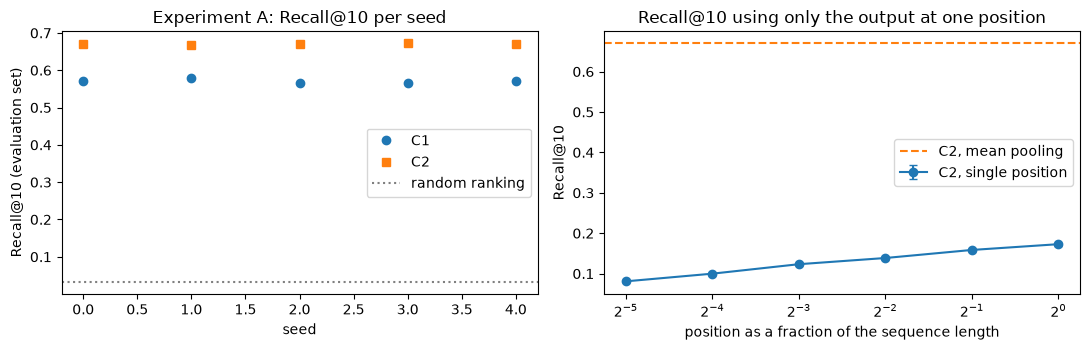

In [11]:
_seeds = list(range(SEEDS_A))
R_C1, R_C2_A = recall_of("C1", SEEDS_A), recall_of("C2", SEEDS_A)
A_PER_SEED = R_C1 - R_C2_A
_boot = bootstrap_recall([("C1", s) for s in _seeds] + [("C2", s) for s in _seeds])
_boot_contrast = _boot[:, :SEEDS_A].mean(axis=1) - _boot[:, SEEDS_A:].mean(axis=1)
DELTA_A = float(A_PER_SEED.mean())
SIGMA_A = combined_sigma(A_PER_SEED, _boot_contrast)

_p1 = check_learning(("C1", "C2"), _seeds)
precondition_status["P1(A)"] = _p1["ok"]
precondition_status["P2(A)"] = bool(R_C2_A.mean() <= P2_RECALL_CEILING)
A_PRECONDITIONS = ["P0(A)", "P1(A)", "P2(A)"]
A_COMPUTED = judge(DELTA_A, SIGMA_A["sigma"])
A_VERDICT = A_COMPUTED if all(precondition_status[k] for k in A_PRECONDITIONS) else "前提不成立"

print(f"{RUN_TAG}実験 A(シード {_seeds}、T = {NUM_STEPS})")
print(f"  Recall@10 R(C1): {rounded(R_C1)}、R(C2): {rounded(R_C2_A)}")
print(f"  d_s = R(C1) - R(C2): {rounded(A_PER_SEED)}")
print(
    f"  Delta_A = {DELTA_A:+.4f}、sigma_A = {SIGMA_A['sigma']:.4f}(シード間 {SIGMA_A['seed_term']:.4f}・ブートストラップ "
    f"{SIGMA_A['bootstrap_term']:.4f}、反復 {BOOTSTRAP_RESAMPLES:,})、閾値 2 sigma_A = {SIGMA_MULTIPLIER * SIGMA_A['sigma']:.4f}"
)
print(
    f"  前提条件: P0 {precondition_status['P0(A)']}、P1 {precondition_status['P1(A)']}{describe_learning(_p1)}、"
    f"P2 {precondition_status['P2(A)']}(R(C2) の平均 {R_C2_A.mean():.4f} <= {P2_RECALL_CEILING})"
)
print(f"  判定関数の結果 {A_COMPUTED} -> {RUN_TAG}最終判定: {A_VERDICT}")

# 診断量(判定なし)
print("  診断量: 作用点に近い量。C2 のモデルで、位置 t の出力だけを埋め込みにしたときの Recall@10(学習を伴わない評価。query の位置 / passage の位置は系列の長さに対する割合から決める)")
_position_means = {}
for _fraction, _tq, _tp in zip(POSITION_FRACTIONS, POSITIONS_QUERY, POSITIONS_PASSAGE, strict=True):
    _values = np.array([RUNS[("C2", s)]["position_hits"][_fraction].mean() for s in range(NUM_SEEDS["C2"])])
    _position_means[_fraction] = (float(_values.mean()), float(_values.std(ddof=1)))
    print(f"    割合 {_fraction:.4f}(query の位置 {_tq}、passage の位置 {_tp}): {_values.mean():.4f}(シード間の標準偏差 {_values.std(ddof=1):.4f})")
print(f"    参照: C2 の平均プール {recall_of('C2', NUM_SEEDS['C2']).mean():.4f}、C1 の終端位置 {recall_of('C1', NUM_SEEDS['C1']).mean():.4f}")
for _c in ("C1", "C2"):
    _mrr = np.array([(1 / RUNS[(_c, s)]["rank"][EMBEDDING_DIMENSION]).mean() for s in range(NUM_SEEDS[_c])])
    _ndcg = np.array([RUNS[(_c, s)]["ndcg_at_10"].mean() for s in range(NUM_SEEDS[_c])])
    _loss = np.array([RUNS[(_c, s)]["final_train_loss"] for s in range(NUM_SEEDS[_c])])
    print(
        f"  診断量: {_c} の MRR {_mrr.mean():.4f}・nDCG@10 {_ndcg.mean():.4f}・最後の区間の訓練損失 {_loss.mean():.3f}"
        f"・学習率 {LEARNING_RATE[_c]:.3g}(出どころ {LEARNING_RATE_SOURCE[_c]})・clipping の発動 {np.mean([RUNS[(_c, s)]['clip_rate'] for s in range(NUM_SEEDS[_c])]):.2f}"
    )

_fig, _axes = plt.subplots(1, 2, figsize=(11, 3.6))
for _c, _marker in (("C1", "o"), ("C2", "s")):
    _axes[0].plot(range(NUM_SEEDS[_c]), recall_of(_c, NUM_SEEDS[_c]), _marker, label=_c)
_axes[0].axhline(RANDOM_RECALL["evaluation"], color="gray", linestyle=":", label="random ranking")
_axes[0].set_xlabel("seed")
_axes[0].set_ylabel("Recall@10 (evaluation set)")
_axes[0].set_title(f"{PLOT_TAG}Experiment A: Recall@10 per seed")
_axes[0].legend()
_x = list(_position_means)
_axes[1].errorbar(_x, [_position_means[f][0] for f in _x], yerr=[_position_means[f][1] for f in _x], marker="o", capsize=3, label="C2, single position")
_axes[1].axhline(recall_of("C2", NUM_SEEDS["C2"]).mean(), color="C1", linestyle="--", label="C2, mean pooling")
_axes[1].set_xscale("log", base=2)
_axes[1].set_xlabel("position as a fraction of the sequence length")
_axes[1].set_ylabel("Recall@10")
_axes[1].set_title(f"{PLOT_TAG}Recall@10 using only the output at one position")
_axes[1].legend()
plt.tight_layout()
plt.show()

### 6.8 実験 B: 平均プールでの注意マスク(双方向 と 因果)

実験 B(シード [0, 1, 2, 3, 4]、T = 1024)
  Recall@10 R(C3): [0.6773, 0.6769, 0.6763, 0.6877, 0.6711]、R(C2): [0.6692, 0.6665, 0.6714, 0.6723, 0.6708]
  d_s = R(C3) - R(C2): [0.008, 0.0105, 0.0049, 0.0154, 0.0003]
  Delta_B = +0.0078、sigma_B = 0.0049(シード間 0.0025・ブートストラップ 0.0042、反復 10,000)、閾値 2 sigma_B = 0.0098
  前提条件: P0 True、P1 True(損失の不成立 なし、最後の区間の訓練損失 / 同じ組での学習前のモデルの損失の最大 0.632 <= 0.9。C2 の検証用の Recall@10 の学習前からの増分の最小 +0.1374 >= 0.04: True)、P2 True(R(C2) の平均 0.6700 <= 0.95)
  判定関数の結果 判定不能 -> 最終判定: 判定不能
  診断量: 検証用の集合の Recall@10 の推移(シード平均、途中の評価のステップ (16, 32, 64, 128, 256, 512, 1024))
    C2: [0.6981, 0.7199, 0.7425, 0.757, 0.7851, 0.8108, 0.8404]
    C3: [0.7172, 0.7327, 0.7558, 0.7678, 0.787, 0.8132, 0.83]
  診断量: C2 の最後の区間の訓練損失 2.062・学習率 0.00048(出どころ C2)・MRR 0.4610
  診断量: C3 の最後の区間の訓練損失 2.044・学習率 0.00024(出どころ C3)・MRR 0.4699


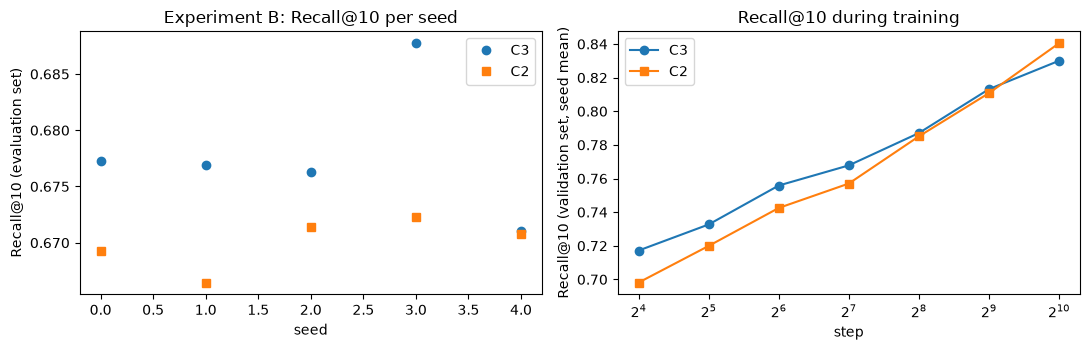

In [12]:
_seeds = list(range(SEEDS_B))
R_C2_B, R_C3 = recall_of("C2", SEEDS_B), recall_of("C3", SEEDS_B)
B_PER_SEED = R_C3 - R_C2_B
_boot = bootstrap_recall([("C3", s) for s in _seeds] + [("C2", s) for s in _seeds])
_boot_contrast = _boot[:, :SEEDS_B].mean(axis=1) - _boot[:, SEEDS_B:].mean(axis=1)
DELTA_B = float(B_PER_SEED.mean())
SIGMA_B = combined_sigma(B_PER_SEED, _boot_contrast)

_p1 = check_learning(("C2", "C3"), _seeds)
precondition_status["P1(B)"] = _p1["ok"]
precondition_status["P2(B)"] = bool(R_C2_B.mean() <= P2_RECALL_CEILING)
B_PRECONDITIONS = ["P0(B)", "P1(B)", "P2(B)"]
B_COMPUTED = judge(DELTA_B, SIGMA_B["sigma"])
B_VERDICT = B_COMPUTED if all(precondition_status[k] for k in B_PRECONDITIONS) else "前提不成立"

print(f"{RUN_TAG}実験 B(シード {_seeds}、T = {NUM_STEPS})")
print(f"  Recall@10 R(C3): {rounded(R_C3)}、R(C2): {rounded(R_C2_B)}")
print(f"  d_s = R(C3) - R(C2): {rounded(B_PER_SEED)}")
print(
    f"  Delta_B = {DELTA_B:+.4f}、sigma_B = {SIGMA_B['sigma']:.4f}(シード間 {SIGMA_B['seed_term']:.4f}・ブートストラップ "
    f"{SIGMA_B['bootstrap_term']:.4f}、反復 {BOOTSTRAP_RESAMPLES:,})、閾値 2 sigma_B = {SIGMA_MULTIPLIER * SIGMA_B['sigma']:.4f}"
)
print(
    f"  前提条件: P0 {precondition_status['P0(B)']}、P1 {precondition_status['P1(B)']}{describe_learning(_p1)}、"
    f"P2 {precondition_status['P2(B)']}(R(C2) の平均 {R_C2_B.mean():.4f} <= {P2_RECALL_CEILING})"
)
print(f"  判定関数の結果 {B_COMPUTED} -> {RUN_TAG}最終判定: {B_VERDICT}")

# 診断量(判定なし): 学習の初期に密な位置での検証用の集合の Recall@10(シード平均)
print(f"  診断量: 検証用の集合の Recall@10 の推移(シード平均、途中の評価のステップ {EVAL_STEPS})")
for _c in ("C2", "C3"):
    print(f"    {_c}: {rounded(np.mean([RUNS[(_c, s)]['eval_validation_recall'] for s in range(NUM_SEEDS[_c])], axis=0))}")
for _c in ("C2", "C3"):
    print(
        f"  診断量: {_c} の最後の区間の訓練損失 {np.mean([RUNS[(_c, s)]['final_train_loss'] for s in range(NUM_SEEDS[_c])]):.3f}・"
        f"学習率 {LEARNING_RATE[_c]:.3g}(出どころ {LEARNING_RATE_SOURCE[_c]})・MRR "
        f"{np.mean([(1 / RUNS[(_c, s)]['rank'][EMBEDDING_DIMENSION]).mean() for s in range(NUM_SEEDS[_c])]):.4f}"
    )

_fig, _axes = plt.subplots(1, 2, figsize=(11, 3.6))
for _c, _marker in (("C3", "o"), ("C2", "s")):
    _axes[0].plot(range(NUM_SEEDS[_c]), recall_of(_c, NUM_SEEDS[_c]), _marker, label=_c)
_axes[0].set_xlabel("seed")
_axes[0].set_ylabel("Recall@10 (evaluation set)")
_axes[0].set_title(f"{PLOT_TAG}Experiment B: Recall@10 per seed")
_axes[0].legend()
for _c, _marker in (("C3", "o"), ("C2", "s")):
    _curves = np.array([RUNS[(_c, s)]["eval_validation_recall"] for s in range(NUM_SEEDS[_c])])
    _axes[1].plot(EVAL_STEPS, _curves.mean(axis=0), marker=_marker, label=_c)
_axes[1].set_xscale("log", base=2)
_axes[1].set_xlabel("step")
_axes[1].set_ylabel("Recall@10 (validation set, seed mean)")
_axes[1].set_title(f"{PLOT_TAG}Recall@10 during training")
_axes[1].legend()
plt.tight_layout()
plt.show()

### 6.9 実験 C: 事前学習の効果(008 の重み と ランダム初期化)

実験 C(シード [0, 1, 2, 3, 4]、T = 1024)
  Recall@10 R(C2): [0.6692, 0.6665, 0.6714, 0.6723, 0.6708]、R(C4): [0.4556, 0.463, 0.4698, 0.4516, 0.4738]
  d_s = R(C2) - R(C4): [0.2136, 0.2035, 0.2016, 0.2207, 0.197]
  Delta_C = +0.2073、sigma_C = 0.0092(シード間 0.0043・ブートストラップ 0.0081、反復 10,000)、閾値 2 sigma_C = 0.0183
  前提条件: P0 True、P1 True(損失の不成立 なし、最後の区間の訓練損失 / 同じ組での学習前のモデルの損失の最大 0.632 <= 0.9。C2 の検証用の Recall@10 の学習前からの増分の最小 +0.1374 >= 0.04: True)、P2 True(R(C4) の平均 0.4628 <= 0.95)
  判定関数の結果 支持 -> 最終判定: 支持
  診断量: 検証用の集合の Recall@10 の推移(シード平均、途中の評価のステップ (16, 32, 64, 128, 256, 512, 1024))
    C2: [0.6981, 0.7199, 0.7425, 0.757, 0.7851, 0.8108, 0.8404]
    C4: [0.2012, 0.2092, 0.2279, 0.3034, 0.42, 0.5843, 0.6752]
  診断量: 汎化の差(学習用の部分の索引の Recall@10 - 評価用の Recall@10。別の記事・別の索引の大きさなので、条件間での差の違いを読む)
    C2: 学習用の部分 0.7897、差の平均 +0.1197、各シード [0.1047, 0.1262, 0.1189, 0.1196, 0.1289]
    C4: 学習用の部分 0.6134、差の平均 +0.1506、各シード [0.1555, 0.1364, 0.1569, 0.1563, 0.1482]
    同じシードの C2 との差(C4 の差 - C2 の差)の平均 +0.0310、各シード [0.0

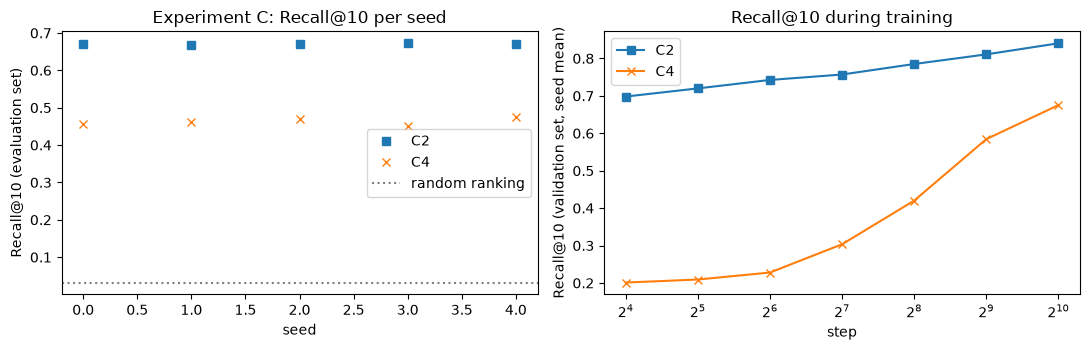

In [13]:
_seeds = list(range(SEEDS_C))
R_C2_C, R_C4 = recall_of("C2", SEEDS_C), recall_of("C4", SEEDS_C)
C_PER_SEED = R_C2_C - R_C4
_keys = [("C2", s) for s in _seeds] + [("C4", s) for s in _seeds]
_boot = bootstrap_recall(_keys)
_boot_contrast = _boot[:, :SEEDS_C].mean(axis=1) - _boot[:, SEEDS_C:].mean(axis=1)
DELTA_C = float(C_PER_SEED.mean())
SIGMA_C = combined_sigma(C_PER_SEED, _boot_contrast)

_p1 = check_learning(("C2", "C4"), _seeds)  # C4 は損失が有限であることのみ
precondition_status["P1(C)"] = _p1["ok"]
precondition_status["P2(C)"] = bool(R_C4.mean() <= P2_RECALL_CEILING)
C_PRECONDITIONS = ["P0(C)", "P1(C)", "P2(C)"]
C_COMPUTED = judge(DELTA_C, SIGMA_C["sigma"])
C_VERDICT = C_COMPUTED if all(precondition_status[k] for k in C_PRECONDITIONS) else "前提不成立"

print(f"{RUN_TAG}実験 C(シード {_seeds}、T = {NUM_STEPS})")
print(f"  Recall@10 R(C2): {rounded(R_C2_C)}、R(C4): {rounded(R_C4)}")
print(f"  d_s = R(C2) - R(C4): {rounded(C_PER_SEED)}")
print(
    f"  Delta_C = {DELTA_C:+.4f}、sigma_C = {SIGMA_C['sigma']:.4f}(シード間 {SIGMA_C['seed_term']:.4f}・ブートストラップ "
    f"{SIGMA_C['bootstrap_term']:.4f}、反復 {BOOTSTRAP_RESAMPLES:,})、閾値 2 sigma_C = {SIGMA_MULTIPLIER * SIGMA_C['sigma']:.4f}"
)
print(
    f"  前提条件: P0 {precondition_status['P0(C)']}、P1 {precondition_status['P1(C)']}{describe_learning(_p1)}、"
    f"P2 {precondition_status['P2(C)']}(R(C4) の平均 {R_C4.mean():.4f} <= {P2_RECALL_CEILING})"
)
print(f"  判定関数の結果 {C_COMPUTED} -> {RUN_TAG}最終判定: {C_VERDICT}")

# 診断量(判定なし)
print(f"  診断量: 検証用の集合の Recall@10 の推移(シード平均、途中の評価のステップ {EVAL_STEPS})")
for _c in ("C2", "C4"):
    print(f"    {_c}: {rounded(np.mean([RUNS[(_c, s)]['eval_validation_recall'] for s in range(NUM_SEEDS[_c])], axis=0))}")
print("  診断量: 汎化の差(学習用の部分の索引の Recall@10 - 評価用の Recall@10。別の記事・別の索引の大きさなので、条件間での差の違いを読む)")
_gap = {}
for _c in ("C2", "C4"):
    _train = np.array([RUNS[(_c, s)]["train_probe_recall"] for s in _seeds])
    _gap[_c] = _train - recall_of(_c, SEEDS_C)
    print(f"    {_c}: 学習用の部分 {_train.mean():.4f}、差の平均 {_gap[_c].mean():+.4f}、各シード {rounded(_gap[_c])}")
print(f"    同じシードの C2 との差(C4 の差 - C2 の差)の平均 {(_gap['C4'] - _gap['C2']).mean():+.4f}、各シード {rounded(_gap['C4'] - _gap['C2'])}")
print(
    f"  診断量: 最後の区間の訓練損失 C2 {np.mean([RUNS[('C2', s)]['final_train_loss'] for s in _seeds]):.3f}・C4 {np.mean([RUNS[('C4', s)]['final_train_loss'] for s in _seeds]):.3f}、"
    f"学習率 C2 {LEARNING_RATE['C2']:.3g}・C4 {LEARNING_RATE['C4']:.3g}"
)

_fig, _axes = plt.subplots(1, 2, figsize=(11, 3.6))
for _c, _marker in (("C2", "s"), ("C4", "x")):
    _axes[0].plot(range(NUM_SEEDS[_c]), recall_of(_c, NUM_SEEDS[_c]), _marker, label=_c)
_axes[0].axhline(RANDOM_RECALL["evaluation"], color="gray", linestyle=":", label="random ranking")
_axes[0].set_xlabel("seed")
_axes[0].set_ylabel("Recall@10 (evaluation set)")
_axes[0].set_title(f"{PLOT_TAG}Experiment C: Recall@10 per seed")
_axes[0].legend()
for _c, _marker in (("C2", "s"), ("C4", "x")):
    _curves = np.array([RUNS[(_c, s)]["eval_validation_recall"] for s in range(NUM_SEEDS[_c])])
    _axes[1].plot(EVAL_STEPS, _curves.mean(axis=0), marker=_marker, label=_c)
_axes[1].set_xscale("log", base=2)
_axes[1].set_xlabel("step")
_axes[1].set_ylabel("Recall@10 (validation set, seed mean)")
_axes[1].set_title(f"{PLOT_TAG}Recall@10 during training")
_axes[1].legend()
plt.tight_layout()
plt.show()

### 6.10 実験 D: Matryoshka Representation Learning(先頭 16 次元)

実験 D(シード [0, 1, 2, 3, 4]、T = 1024)
  先頭 16 次元の Recall@10 R_16(C5): [0.5672, 0.5712, 0.5749, 0.5647, 0.5678]、R_16(C2): [0.3782, 0.39, 0.3847, 0.3678, 0.3711]
  d_s = R_16(C5) - R_16(C2): [0.189, 0.1813, 0.1902, 0.197, 0.1967]
  Delta_D = +0.1908、sigma_D = 0.0074(シード間 0.0029・ブートストラップ 0.0068、反復 10,000)、閾値 2 sigma_D = 0.0147
  前提条件: P0 True、P1 True(損失の不成立 なし、最後の区間の訓練損失 / 同じ組での学習前のモデルの損失の最大 0.632 <= 0.9。C2 の検証用の Recall@10 の学習前からの増分の最小 +0.1374 >= 0.04: True)、P2 True(R_16(C2) の平均 0.3784 <= 0.95)
  判定関数の結果 支持 -> 最終判定: 支持
  診断量: 入れ子の次元 m ごとの Recall@10(シード平均 ± シード間の標準偏差)と、同じシードの差 C5 - C2(標準偏差は判定と同じ構成)
    m =  16: C5 0.5692 ± 0.0040、C2 0.3784 ± 0.0092、差 +0.1908(標準偏差 0.0074、2 倍 0.0147)
    m =  32: C5 0.6055 ± 0.0035、C2 0.5088 ± 0.0052、差 +0.0967(標準偏差 0.0065、2 倍 0.0130)
    m =  64: C5 0.6256 ± 0.0048、C2 0.5846 ± 0.0036、差 +0.0410(標準偏差 0.0054、2 倍 0.0108)
    m = 128: C5 0.6376 ± 0.0045、C2 0.6359 ± 0.0058、差 +0.0017(標準偏差 0.0046、2 倍 0.0092)
    m = 256: C5 0.6507 ± 0.0034、C2 0.6700 ± 0.0023、差 -0.0193(

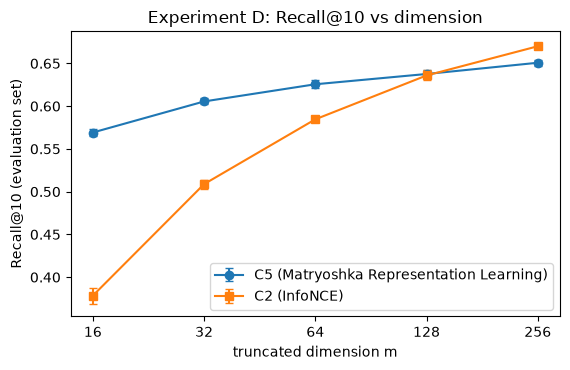

In [14]:
_seeds = list(range(SEEDS_D))
SMALLEST = MATRYOSHKA_DIMENSIONS[0]  # 16
R16_C2 = recall_of("C2", SEEDS_D, SMALLEST)
R16_C5 = recall_of("C5", SEEDS_D, SMALLEST)
D_PER_SEED = R16_C5 - R16_C2
_keys5 = [("C5", s) for s in _seeds]
_keys2 = [("C2", s) for s in _seeds]
_boot = paired_cluster_bootstrap_ratio_of_sums(
    np.concatenate([hits_matrix(_keys5, SMALLEST), hits_matrix(_keys2, SMALLEST)]), np.ones(EVALUATION_SET.num_queries),
    EVALUATION_SET.query_articles, BOOTSTRAP_RESAMPLES, BOOTSTRAP_SEED,
)
_boot_contrast = _boot[:, :SEEDS_D].mean(axis=1) - _boot[:, SEEDS_D:].mean(axis=1)
DELTA_D = float(D_PER_SEED.mean())
SIGMA_D = combined_sigma(D_PER_SEED, _boot_contrast)

_p1 = check_learning(("C2", "C5"), _seeds)
precondition_status["P1(D)"] = _p1["ok"]
precondition_status["P2(D)"] = bool(R16_C2.mean() <= P2_RECALL_CEILING)
D_PRECONDITIONS = ["P0(D)", "P1(D)", "P2(D)"]
D_COMPUTED = judge(DELTA_D, SIGMA_D["sigma"])
D_VERDICT = D_COMPUTED if all(precondition_status[k] for k in D_PRECONDITIONS) else "前提不成立"

print(f"{RUN_TAG}実験 D(シード {_seeds}、T = {NUM_STEPS})")
print(f"  先頭 {SMALLEST} 次元の Recall@10 R_{SMALLEST}(C5): {rounded(R16_C5)}、R_{SMALLEST}(C2): {rounded(R16_C2)}")
print(f"  d_s = R_{SMALLEST}(C5) - R_{SMALLEST}(C2): {rounded(D_PER_SEED)}")
print(
    f"  Delta_D = {DELTA_D:+.4f}、sigma_D = {SIGMA_D['sigma']:.4f}(シード間 {SIGMA_D['seed_term']:.4f}・ブートストラップ "
    f"{SIGMA_D['bootstrap_term']:.4f}、反復 {BOOTSTRAP_RESAMPLES:,})、閾値 2 sigma_D = {SIGMA_MULTIPLIER * SIGMA_D['sigma']:.4f}"
)
print(
    f"  前提条件: P0 {precondition_status['P0(D)']}、P1 {precondition_status['P1(D)']}{describe_learning(_p1)}、"
    f"P2 {precondition_status['P2(D)']}(R_{SMALLEST}(C2) の平均 {R16_C2.mean():.4f} <= {P2_RECALL_CEILING})"
)
print(f"  判定関数の結果 {D_COMPUTED} -> {RUN_TAG}最終判定: {D_VERDICT}")

# 診断量(判定なし): 全ての m で、両条件の Recall@10。「全次元では劣化しない」は別の検証事項で、判定に含めない
print("  診断量: 入れ子の次元 m ごとの Recall@10(シード平均 ± シード間の標準偏差)と、同じシードの差 C5 - C2(標準偏差は判定と同じ構成)")
_dimension_table = {}
for _m in MATRYOSHKA_DIMENSIONS:
    _a, _b = recall_of("C5", SEEDS_D, _m), recall_of("C2", SEEDS_D, _m)
    _boot_m = paired_cluster_bootstrap_ratio_of_sums(
        np.concatenate([hits_matrix(_keys5, _m), hits_matrix(_keys2, _m)]), np.ones(EVALUATION_SET.num_queries),
        EVALUATION_SET.query_articles, BOOTSTRAP_RESAMPLES, BOOTSTRAP_SEED,
    )
    _sigma_m = combined_sigma(_a - _b, _boot_m[:, :SEEDS_D].mean(axis=1) - _boot_m[:, SEEDS_D:].mean(axis=1))
    _dimension_table[_m] = (float(_a.mean()), float(_a.std(ddof=1)), float(_b.mean()), float(_b.std(ddof=1)))
    print(
        f"    m = {_m:>3}: C5 {_a.mean():.4f} ± {_a.std(ddof=1):.4f}、C2 {_b.mean():.4f} ± {_b.std(ddof=1):.4f}、差 {(_a - _b).mean():+.4f}"
        f"(標準偏差 {_sigma_m['sigma']:.4f}、2 倍 {SIGMA_MULTIPLIER * _sigma_m['sigma']:.4f})"
    )
print(
    f"  診断量: C5 の最後の区間の次元ごとの訓練損失 {rounded(np.mean([RUNS[('C5', s)]['final_dimension_losses'] for s in _seeds], axis=0), 3)}"
    f"(m = {MATRYOSHKA_DIMENSIONS})、C5 の最後の区間の訓練損失(平均)の平均 {np.mean([RUNS[('C5', s)]['final_train_loss'] for s in _seeds]):.3f}、"
    f"clipping の発動 C5 {np.mean([RUNS[('C5', s)]['clip_rate'] for s in _seeds]):.2f}・C2 {np.mean([RUNS[('C2', s)]['clip_rate'] for s in _seeds]):.2f}"
)
print(f"  診断量: 索引のメモリ(FP32、評価用の passage {EVALUATION_SET.num_passages} 個): " + "、".join(f"m = {m}: {4 * EVALUATION_SET.num_passages * m / 1024:.0f} KiB" for m in MATRYOSHKA_DIMENSIONS))

_fig, _axis = plt.subplots(figsize=(5.8, 3.8))
for _label, _column, _marker in (("C5 (Matryoshka Representation Learning)", 0, "o"), ("C2 (InfoNCE)", 2, "s")):
    _axis.errorbar(
        [math.log2(m) for m in MATRYOSHKA_DIMENSIONS], [_dimension_table[m][_column] for m in MATRYOSHKA_DIMENSIONS],
        yerr=[_dimension_table[m][_column + 1] for m in MATRYOSHKA_DIMENSIONS], marker=_marker, capsize=3, label=_label,
    )
_axis.set_xticks([math.log2(m) for m in MATRYOSHKA_DIMENSIONS])
_axis.set_xticklabels([str(m) for m in MATRYOSHKA_DIMENSIONS])
_axis.set_xlabel("truncated dimension m")
_axis.set_ylabel("Recall@10 (evaluation set)")
_axis.set_title(f"{PLOT_TAG}Experiment D: Recall@10 vs dimension")
_axis.legend()
plt.tight_layout()
plt.show()

### 6.11 観察 E・F(判定基準を設けない)

**観察 E: BM25 との比較。** 評価用の同じ索引・同じ query で BM25 の Recall@10・MRR・nDCG@10 を測り、各条件(全次元)の値と並べる。優劣は判定しない。BM25 は学習を伴わず、シードを持たない。

**観察 F: 異方性と alignment・uniformity。** 対照学習の前(008 の重みのまま、平均プール・因果マスク)と後(C2 のシード 0)で、評価用の passage の埋め込みについて、
ランダムな 2 つの組のコサイン類似度の平均(異方性)、alignment(正例の組 = 各 query と、その記事の次の窓の passage)、uniformity、Recall@10 を測る。
定性的な観察であり、判定基準を設けない。

In [15]:
# --- 観察 E: BM25 ---
_t0_bm25 = time.time()
BM25_INDEX = BM25Index(EVALUATION_SET.passages, tokenizer.vocab_size)
BM25_RESULT = rank_candidates(
    torch.from_numpy(BM25_INDEX.score_batch(EVALUATION_SET.queries)), EVALUATION_SET.query_articles, EVALUATION_SET.passage_articles, EVALUATION_SET.query_sources
)
_bm25_boot = paired_cluster_bootstrap_ratio_of_sums(
    BM25_RESULT.hits(10).astype(np.float64), np.ones(EVALUATION_SET.num_queries), EVALUATION_SET.query_articles, BOOTSTRAP_RESAMPLES, BOOTSTRAP_SEED
)
print(
    f"{RUN_TAG}観察 E(評価用の索引 {EVALUATION_SET.num_passages} passage・query {EVALUATION_SET.num_queries} 個、ランダムな順位の Recall@10 の期待値 {RANDOM_RECALL['evaluation']:.4f}、"
    f"BM25 k1 = {BM25_INDEX.k1}・b = {BM25_INDEX.b}、{time.time() - _t0_bm25:.1f} 秒)"
)
print(
    f"  BM25: Recall@10 {BM25_RESULT.recall_at(10):.4f}(記事を単位とするブートストラップの標準偏差 {_bm25_boot.std(ddof=1):.4f})・MRR {BM25_RESULT.mean_reciprocal_rank():.4f}・"
    f"nDCG@10 {BM25_RESULT.mean_ndcg_at_10():.4f}"
)
OBSERVATION_E = {"BM25": (BM25_RESULT.recall_at(10), BM25_RESULT.mean_reciprocal_rank(), BM25_RESULT.mean_ndcg_at_10())}
for _c in RUN_ORDER:
    _recalls = recall_of(_c, NUM_SEEDS[_c])
    _mrr = np.array([(1 / RUNS[(_c, s)]["rank"][EMBEDDING_DIMENSION]).mean() for s in range(NUM_SEEDS[_c])])
    _ndcg = np.array([RUNS[(_c, s)]["ndcg_at_10"].mean() for s in range(NUM_SEEDS[_c])])
    OBSERVATION_E[_c] = (float(_recalls.mean()), float(_mrr.mean()), float(_ndcg.mean()))
    print(
        f"  {_c}({NUM_SEEDS[_c]} シード): Recall@10 {_recalls.mean():.4f}(シード間の標準偏差 {_recalls.std(ddof=1):.4f})・MRR {_mrr.mean():.4f}・nDCG@10 {_ndcg.mean():.4f}"
    )

# --- 観察 F: 対照学習の前後 ---
_reference_model = build_model("C2", 0).to(device)  # 008 の重みのまま(平均プール・因果マスク)
_before = evaluate_set(_reference_model, "evaluation", keep_embeddings=True)
del _reference_model
empty_device_cache()


def positive_passage_index(retrieval_set) -> np.ndarray:
    # 各 query の正例の passage: 同じ記事の次の窓(最後の窓なら、同じ記事の最初の窓)。元の passage 自身は除く
    result = np.empty(retrieval_set.num_queries, dtype=np.int64)
    for i, (article, source) in enumerate(zip(retrieval_set.query_articles, retrieval_set.query_sources, strict=True)):
        members = np.nonzero(retrieval_set.passage_articles == article)[0]
        members = members[members != source]
        later = members[members > source]
        result[i] = later[0] if len(later) else members[0]
    return result


_positive = positive_passage_index(EVALUATION_SET)
assert (EVALUATION_SET.passage_articles[_positive] == EVALUATION_SET.query_articles).all() and not (_positive == EVALUATION_SET.query_sources).any()
GEOMETRY = {}
for _label, _embeddings in (
    ("008 の重みのまま", {"passages": _before["passage_embeddings"], "queries": _before["query_embeddings"], "recall": _before["by_dimension"][EMBEDDING_DIMENSION]}),
    ("対照学習の後(C2、シード 0)", {"passages": OBSERVATION_EMBEDDINGS["passages"], "queries": OBSERVATION_EMBEDDINGS["queries"], "recall": None}),
):
    _p, _q = _embeddings["passages"], _embeddings["queries"]
    GEOMETRY[_label] = {
        "mean_cosine": mean_pairwise_cosine(_p),
        "alignment": alignment(_q, _p[_positive]),
        "uniformity": uniformity(_p),
        "recall": _embeddings["recall"].recall_at(10) if _embeddings["recall"] is not None else float(RUNS[OBSERVATION_RUN]["hits"][EMBEDDING_DIMENSION].mean()),
        "mrr": _embeddings["recall"].mean_reciprocal_rank() if _embeddings["recall"] is not None else float((1 / RUNS[OBSERVATION_RUN]["rank"][EMBEDDING_DIMENSION]).mean()),
    }
print(f"{RUN_TAG}観察 F(評価用の passage {EVALUATION_SET.num_passages} 個の埋め込み。alignment は {EVALUATION_SET.num_queries} 組の正例)")
for _label, _g in GEOMETRY.items():
    print(
        f"  {_label}: ランダムな組のコサイン類似度の平均 {_g['mean_cosine']:.4f}・alignment {_g['alignment']:.4f}・uniformity {_g['uniformity']:.4f}・"
        f"Recall@10 {_g['recall']:.4f}・MRR {_g['mrr']:.4f}"
    )

観察 E(評価用の索引 3244 passage・query 3244 個、ランダムな順位の Recall@10 の期待値 0.0321、BM25 k1 = 1.2・b = 0.75、1.7 秒)
  BM25: Recall@10 0.7398(記事を単位とするブートストラップの標準偏差 0.0114)・MRR 0.5751・nDCG@10 0.3281
  C2(5 シード): Recall@10 0.6700(シード間の標準偏差 0.0023)・MRR 0.4610・nDCG@10 0.2694
  C1(5 シード): Recall@10 0.5702(シード間の標準偏差 0.0056)・MRR 0.3589・nDCG@10 0.2024
  C3(5 シード): Recall@10 0.6779(シード間の標準偏差 0.0061)・MRR 0.4699・nDCG@10 0.2765
  C5(5 シード): Recall@10 0.6507(シード間の標準偏差 0.0034)・MRR 0.4397・nDCG@10 0.2556
  C4(5 シード): Recall@10 0.4628(シード間の標準偏差 0.0093)・MRR 0.2885・nDCG@10 0.1545
観察 F(評価用の passage 3244 個の埋め込み。alignment は 3244 組の正例)
  008 の重みのまま: ランダムな組のコサイン類似度の平均 0.4659・alignment 0.7604・uniformity -1.8987・Recall@10 0.4834・MRR 0.3201
  対照学習の後(C2、シード 0): ランダムな組のコサイン類似度の平均 0.4590・alignment 0.6998・uniformity -2.0079・Recall@10 0.6692・MRR 0.4634


### 6.12 不変条件のアサーションと`SMOKE_TEST`の配線

- 実効水準の照合: 実際に学習した条件・シード・ステップ数・途中の評価のステップが、5.2 節で印字した水準と 6.4 節で選ばれた計画に一致する。
- 同じシードの条件どうしで、学習の組(ハッシュ)が一致する。異なるシードでは異なる。
- 全条件で、学習ステップ数・バッチサイズ・query と passage の長さ・評価用の索引と query が同じである。
- 学習率が、較正した値または規則で決めた値に一致する。
- 記録した順位から再計算した Recall@10 が、記録した hits の平均と一致する。
- 評価用の索引と query の記事が、すべて 008 の事前学習とトークナイザの学習の範囲(参照コーパス)の外にある。

In [16]:
# --- 実効水準の照合(SMOKE_TEST の配線) ---
assert CURRENT_LEVEL_NAME == ("smoke" if SMOKE_TEST else "prod")
assert STEP_CANDIDATES == LEVELS[CURRENT_LEVEL_NAME]["STEP_CANDIDATES"] and NUM_STEPS in STEP_CANDIDATES
assert BOOTSTRAP_RESAMPLES == LEVELS[CURRENT_LEVEL_NAME]["BOOTSTRAP_RESAMPLES"]
assert NUM_SEEDS == STAGES[CURRENT_LEVEL_NAME][STAGE]["seeds"] and SELECTED_PLAN == PLANS[SELECTED_PLAN["plan"]]
assert set(RUNS) == {(c, s) for c in CONDITIONS for s in range(NUM_SEEDS[c])}, "学習した条件・シードが選ばれた計画と一致しない"
assert all(r["num_steps"] == NUM_STEPS and len(r["train_loss"]) == NUM_STEPS for r in RUNS.values())
assert all(r["eval_step"] == (list(EVAL_STEPS) if CONDITIONS[r["condition"]]["track"] else []) for r in RUNS.values())
assert all(r["learning_rate"] == LEARNING_RATE[r["condition"]] for r in RUNS.values())
for _c in CONDITIONS:  # 較正した条件はその値、規則で決める条件は「基にする条件の値 x 格子の中心の比」(丸めの誤差の範囲で一致)
    _source = LEARNING_RATE_SOURCE[_c]
    if _source == _c:
        assert LEARNING_RATE[_c] == CALIBRATION[_c]["chosen"]
    else:
        assert math.isclose(LEARNING_RATE[_c], CALIBRATION[_source]["chosen"] * LEARNING_RATE_CENTER[_c] / LEARNING_RATE_CENTER[_source], rel_tol=8 * EPSILON_FP64)
        assert math.isclose(GRID_MULTIPLIER[_c], CALIBRATION[_source]["chosen"] / LEARNING_RATE_CENTER[_source], rel_tol=8 * EPSILON_FP64), "格子の中での位置が基にする条件と異なる"
assert all(len(r["eval_validation_recall"]) == len(r["eval_step"]) for r in RUNS.values())
# --- P1 の基準: 学習前のモデルの損失は全ての学習で正で有限、同じ手順で再現できる。学習前の 008 の検証用の値は、ランダムな順位の期待値より高い ---
assert all(math.isfinite(r["initial_model_loss_on_final_window"]) and r["initial_model_loss_on_final_window"] > 0 for r in RUNS.values())
_key = OBSERVATION_RUN
_again = float(
    compute_pair_losses(
        build_model(*_key).to(device), TRAIN_STREAM, TRAIN_STARTS, get_schedule(_key[1], NUM_STEPS), range(NUM_STEPS - final_loss_window(NUM_STEPS), NUM_STEPS),
        QUERY_LENGTH, PASSAGE_LENGTH, TEMPERATURE, matryoshka_dimensions=MATRYOSHKA_DIMENSIONS if CONDITIONS[_key[0]]["loss"] == "matryoshka" else None,
        use_fp16_autocast=USE_FP16_AUTOCAST,
    ).mean()
)
assert math.isclose(_again, RUNS[_key]["initial_model_loss_on_final_window"], rel_tol=16 * (EPSILON_FP16 if USE_FP16_AUTOCAST else EPSILON_FP32)), (_again, RUNS[_key]["initial_model_loss_on_final_window"])
assert UNTRAINED_VALIDATION_RECALL > RANDOM_RECALL["validation"]
print(f"P1 の基準: 学習前のモデルの損失は全 {len(RUNS)} 回の学習で正で有限、{_key} で同じ手順の再計算と一致。学習前の 008 の検証用の Recall@10 {UNTRAINED_VALIDATION_RECALL:.4f} > ランダム {RANDOM_RECALL['validation']:.4f}: OK")
# --- 対応のある比較: 同じシードの条件どうしで学習の組が一致する / 異なるシードでは異なる ---
for _s in range(min(NUM_SEEDS.values())):
    assert len({RUNS[(c, _s)]["schedule_hash"] for c in CONDITIONS}) == 1, f"シード {_s} で学習の組が条件間で一致しない"
assert len({RUNS[("C2", s)]["schedule_hash"] for s in range(NUM_SEEDS["C2"])}) == NUM_SEEDS["C2"], "異なるシードで学習の組が同じ"
# --- キャッシュの導入前後の一致: 使い回している学習の組(SCHEDULES)が、毎回作り直した場合と完全に一致する ---
for (_seed_index, _steps), _cached in SCHEDULES.items():
    _fresh = sample_pair_schedule(TRAIN_TOKEN_COUNTS, SAMPLING_WEIGHTS, QUERY_LENGTH, PASSAGE_LENGTH, _steps, BATCH_SIZE, seed=PAIR_SEED_BASE + _seed_index)
    assert set(_cached) == set(_fresh) and all(np.array_equal(_cached[k], _fresh[k]) for k in _fresh), (_seed_index, _steps)
    _digest = hashlib.sha256()
    for _key in ("article", "query_start", "passage_start"):
        _digest.update(np.ascontiguousarray(_fresh[_key], dtype=np.int64).tobytes())
    for _record in RUNS.values():
        if _record["seed"] == _seed_index and _record["num_steps"] == _steps:
            assert _record["schedule_hash"] == _digest.hexdigest(), "学習に使われた組が、作り直した組と一致しない"
print(f"学習の組のキャッシュ({len(SCHEDULES)} 通り)が、作り直した場合と完全に一致(配列の完全一致と、学習の記録のハッシュの一致): OK")
# --- 全条件で評価の分母が同じ ---
assert all(
    r["hits"][m].shape == (EVALUATION_SET.num_queries,) and r["rank"][m].shape == (EVALUATION_SET.num_queries,) for r in RUNS.values() for m in MATRYOSHKA_DIMENSIONS
)
assert all(set(r["hits"]) == set(MATRYOSHKA_DIMENSIONS) for r in RUNS.values())
_rebuilt = make_sets()
assert [s.digest() for s in RETRIEVAL_SETS.values()] == [s.digest() for s in _rebuilt], "評価用の索引と query が実行の途中で変わった"
del _rebuilt
# --- 記録した順位から再計算した値の整合 ---
for _record in RUNS.values():
    for _m in MATRYOSHKA_DIMENSIONS:
        assert np.array_equal(_record["rank"][_m] <= 10, _record["hits"][_m])
        assert _record["rank"][_m].min() >= 1 and _record["rank"][_m].max() <= EVALUATION_SET.num_passages - 1
# --- 条件の定義が実際の学習で使われた ---
assert all(("final_dimension_losses" in r) == (CONDITIONS[r["condition"]]["loss"] == "matryoshka") for r in RUNS.values())
assert all(("position_hits" in r) == (r["condition"] == "C2") for r in RUNS.values())
assert UPLOAD_RUN in SAVED_STATES and set(SAVED_STATES) == {UPLOAD_RUN}
assert OBSERVATION_RUN in RUNS
# --- 008 とトークナイザの学習の範囲の外: 評価用の索引と query の記事は、すべて参照コーパスの外に始まる ---
_evaluated_articles = set(EVALUATION_SET.query_articles.tolist()) | set(EVALUATION_SET.passage_articles.tolist())
assert min(_evaluated_articles) >= NUM_REFERENCE_ARTICLES
assert all(article_spans[a]["start"] >= REFERENCE_CORPUS_CHARACTERS > REFERENCE_PRETRAINING_END for a in _evaluated_articles)
assert all(r["finite"] for r in RUNS.values()), "有限でない損失の学習がある"
print(
    f"{RUN_TAG}実効水準: T = {NUM_STEPS}、計画 {SELECTED_PLAN['plan']}(段階 {STAGE}、較正の方式 {CALIBRATION_MODE!r})、シード数 {json.dumps(NUM_SEEDS)}、学習 {len(RUNS)} 回、"
    f"バッチ {BATCH_SIZE}、query {QUERY_LENGTH}・passage {PASSAGE_LENGTH}、評価用の query {EVALUATION_SET.num_queries} 個、ブートストラップ {BOOTSTRAP_RESAMPLES:,} 回: 照合 OK"
)
print(f"同じシードの条件どうしで学習の組が一致(シード {min(NUM_SEEDS.values())} 個で確認)、異なるシードでは異なる: OK")

P1 の基準: 学習前のモデルの損失は全 25 回の学習で正で有限、('C2', 0) で同じ手順の再計算と一致。学習前の 008 の検証用の Recall@10 0.6919 > ランダム 0.0962: OK
学習の組のキャッシュ(6 通り)が、作り直した場合と完全に一致(配列の完全一致と、学習の記録のハッシュの一致): OK
実効水準: T = 1024、計画 0(段階 0、較正の方式 'all')、シード数 {"C1": 5, "C2": 5, "C3": 5, "C4": 5, "C5": 5}、学習 25 回、バッチ 64、query 32・passage 128、評価用の query 3244 個、ブートストラップ 10,000 回: 照合 OK
同じシードの条件どうしで学習の組が一致(シード 5 個で確認)、異なるシードでは異なる: OK


### 6.13 判定結果の一覧

In [17]:
print(f"{RUN_TAG}判定結果(計画 {SELECTED_PLAN['plan']}、T = {NUM_STEPS}、較正の方式 {CALIBRATION_MODE!r}、段階 {STAGE})")
VERDICTS = {
    "A": (DELTA_A, SIGMA_A["sigma"], A_COMPUTED, A_VERDICT, A_PRECONDITIONS),
    "B": (DELTA_B, SIGMA_B["sigma"], B_COMPUTED, B_VERDICT, B_PRECONDITIONS),
    "C": (DELTA_C, SIGMA_C["sigma"], C_COMPUTED, C_VERDICT, C_PRECONDITIONS),
    "D": (DELTA_D, SIGMA_D["sigma"], D_COMPUTED, D_VERDICT, D_PRECONDITIONS),
}
for _experiment, (_delta, _sigma, _computed, _verdict, _preconditions) in VERDICTS.items():
    print(
        f"  実験 {_experiment}: 対比量 {_delta:+.4f}、標準偏差 {_sigma:.4f}、閾値 {SIGMA_MULTIPLIER * _sigma:.4f}、判定関数の結果 {_computed}、"
        f"前提条件 {json.dumps({k: precondition_status[k] for k in _preconditions})} -> {RUN_TAG}最終判定: {_verdict}"
    )
TOTAL_SECONDS = time.time() - NOTEBOOK_START_TIME
print(f"全体の経過時間 {TOTAL_SECONDS / 60:.1f} 分(予算 {SESSION_BUDGET_SECONDS / 60:.0f} 分、計画の見積もり {PLAN_ESTIMATES[SELECTED_PLAN['plan']]['total'] / 60:.1f} 分 + 選択時の経過 {ELAPSED_AT_SELECTION / 60:.1f} 分)")

判定結果(計画 0、T = 1024、較正の方式 'all'、段階 0)
  実験 A: 対比量 -0.0999、標準偏差 0.0075、閾値 0.0150、判定関数の結果 反証、前提条件 {"P0(A)": true, "P1(A)": true, "P2(A)": true} -> 最終判定: 反証
  実験 B: 対比量 +0.0078、標準偏差 0.0049、閾値 0.0098、判定関数の結果 判定不能、前提条件 {"P0(B)": true, "P1(B)": true, "P2(B)": true} -> 最終判定: 判定不能
  実験 C: 対比量 +0.2073、標準偏差 0.0092、閾値 0.0183、判定関数の結果 支持、前提条件 {"P0(C)": true, "P1(C)": true, "P2(C)": true} -> 最終判定: 支持
  実験 D: 対比量 +0.1908、標準偏差 0.0074、閾値 0.0147、判定関数の結果 支持、前提条件 {"P0(D)": true, "P1(D)": true, "P2(D)": true} -> 最終判定: 支持
全体の経過時間 64.3 分(予算 120 分、計画の見積もり 65.0 分 + 選択時の経過 8.4 分)


### 6.14 Hugging Face Hub へのアップロード(C5 のシード 0)

後続のトピック(025)の入力にするため、**条件 C5(Matryoshka Representation Learning)のシード 0** の学習後の重みを`kojikojiprg/ai-theories-text-embedding-en`(新規、public)にアップロードする。
アップロードするモデルは結果を見て選ばない(条件とシードを事前に固定している)。

- **アップロードのセルは`UPLOAD_ARTIFACTS`で守る。既定は`False`。** `SMOKE_TEST`とは独立のフラグで、本番(`SMOKE_TEST = False`)でも、アップロードは`UPLOAD_ARTIFACTS`を別途`True`にしたときだけ行う。
- Colab Secrets の`HF_TOKEN`が取得できない場合は、例外で停止せず、アップロードをスキップしてその旨を印字する。取得した値は印字・記録・加工しない。
- アップロード後、`list_repo_files()`でリポジトリに意図したファイルが実際に存在することを確かめる。`upload_file`が例外を送出しなかったことだけを根拠にしない。
- **このセルの前半(ファイルの書き出し・読み込み直し・評価・モデルカードの組み立て)は、`UPLOAD_ARTIFACTS`によらず毎回実行する**(アップロードしなくてもモデルカードの下書きを確認できるように)。
  モデルカードの指標は、書き出した重みを新しいモデルに読み込み直して評価した値とする(学習中の途中の評価値は使わない)。
- トークナイザは同梱しない。モデルカードで`kojikojiprg/ai-theories-tokenizer-en`を参照する。

In [18]:
_t0_upload = time.time()
MODEL_CARD_TEMPLATE = """---
language: en
license: mit
tags:
- ai-theories
- text-embedding
- retrieval
- matryoshka-representation-learning
- scratch-implementation
---

# ai-theories テキスト埋め込みモデル(英語、Matryoshka Representation Learning)

`ai-theories`(https://github.com/kojikojiprg/ai-theories)プロジェクトの成果物。
008 の小型 GPT(`kojikojiprg/ai-theories-small-gpt-en`)を encoder として、英語 Wikipedia の同じ記事から切り出した重ならない 2 つの区間を正例の組にする
教師なしの対照学習(in-batch negatives の InfoNCE)と Matryoshka Representation Learning(入れ子の次元 {matryoshka_dimensions})で、全パラメータを更新したもの。
スクラッチ実装であり、研究・教育目的のモデルである。品質保証は行っていない。商用・実運用での利用は想定しない。

## 由来

- [024. テキスト埋め込みと retriever](https://github.com/kojikojiprg/ai-theories/blob/main/theories/07_retrieval/024_text_embedding_and_retriever.ipynb)の
  条件 C5(Matryoshka Representation Learning)のシード 0 の学習後の重み。結果を見て選んだものではなく、事前に固定した条件とシードである。
- 学習: {num_steps} ステップ、バッチ {batch_size} 組、query {query_length} トークン・passage {passage_length} トークン、温度 {temperature}、学習率 {learning_rate:.3g}、
  AdamW(重み減衰 {weight_decay})、warmup + cosine、gradient clipping {clip}。学習データは `kojikojiprg/ai-theories-corpus-en` の、先頭の 356 記事を除く記事のうち学習用に分けた {num_train_articles} 記事のみ(検証用・評価用の記事は含まない)。

## 使うために必要な他のアーティファクト

- **トークナイザは同梱していない。** `kojikojiprg/ai-theories-tokenizer-en` を使用してください(語彙サイズ 8192、特殊トークンなし)。
- 本体の構成は `config.json`(008 の `config.json` と同じ構成に、埋め込みの設定を加えたもの)を参照。

## 埋め込みの作り方(プーリング・注意マスク・切り詰め)

- 注意マスク: **因果マスク**(008 と同じ)。
- プーリング: **平均プール**(最終正規化層の後の隠れ状態を、全位置で平均する)。射影層はない。
- 埋め込み: プーリングしたベクトルを L2 正規化する(次元 256)。類似度は内積(= コサイン類似度)。
- 切り詰め: 先頭 m 次元を取り出して **L2 正規化し直す**(m は {matryoshka_dimensions} のいずれか)。
- query は {query_length} トークン、passage は {passage_length} トークンの固定長で学習した(パディングは使わない)。

```python
import json
import torch
from huggingface_hub import hf_hub_download
from src.models.gpt import GPTLanguageModel
from src.models.text_embedding import TextEmbeddingModel, truncate_and_normalize

config = json.load(open(hf_hub_download("{repo_id}", "config.json")))
# GPTLanguageModel の構築は 008(kojikojiprg/ai-theories-small-gpt-en)の config.json と同じ(024 のノートブックの build_gpt() を参照)
backbone = build_gpt(config)
backbone.load_state_dict(torch.load(hf_hub_download("{repo_id}", "model_state.pt"), map_location="cpu"))
model = TextEmbeddingModel(backbone, pooling="mean", attention="causal").eval()
with torch.no_grad():
    embedding = model(token_ids)                  # 次元 256
    embedding_16 = model(token_ids, dimension=16)  # 先頭 16 次元を切り詰めて再正規化
```

## 評価(アップロードした重みそのものを読み込み直して測った値)

評価用の索引と query(`src/data/retrieval.py` の `build_retrieval_set()`)で、全件の内積による厳密な探索。query を含む passage は候補から除く。

| 次元 m | Recall@10 | MRR | nDCG@10 |
|---|---|---|---|
{evaluation_rows}

- ランダムな順位の Recall@10 の期待値: {random_recall:.4f}、BM25 の Recall@10: {bm25_recall:.4f}、評価用の query {num_queries} 個、索引 {num_passages} passage。
- 上の値は {smoke_note}

## 評価用の passage の集合の再構成(025 など後続のトピック向け)

評価用の索引と query は、次の手順で決定的に再構成できる(`src/data/retrieval.py`)。

1. コーパス `kojikojiprg/ai-theories-corpus-en`(9,826 記事)と、記事の境界 `metadata.json` の `article_offsets` を取得する。
   先頭の {num_reference_articles} 記事は 008 の事前学習とトークナイザの学習に使われたコーパス(`kojikojiprg/ai-theories-corpus-en-pretraining`)と同一で、学習・評価のどれにも使わない。
   使うのは、参照コーパスの全体({reference_characters} 文字)の外に始まる記事(`find_articles_starting_at_or_after()`)で、{num_candidates} 記事ある。
2. トークナイザ `kojikojiprg/ai-theories-tokenizer-en` で、使う記事を記事ごとに別々に符号化する(`encode_articles()`)。
3. `split_articles(記事ごとのトークン数, {min_tokens}, 使う記事, {num_validation}, {num_evaluation}, {split_seed})` で記事を分割し、評価用の記事を得る。
4. `build_retrieval_set(記事ごとのトークン, 評価用の記事, {passage_length}, {query_length}, {max_passages}, {max_queries}, {evaluation_seed})` で索引と query を得る。
   ダイジェスト(`RetrievalSet.digest()`)は `{evaluation_digest}`、分割のダイジェスト(`ArticleSplit.digest()`)は `{split_digest}`。

## 注意

- 学習データは英語 Wikipedia の長大な記事(Special:LongPages の長い順に選んだ記事。約 {list_like_share} がリスト系の記事)の {total_tokens} トークンに限られ、汎用の埋め込みモデルとして使えるものではない。
- 評価用の集合は、ノートブックの実行時点のコーパス(`article_offsets` を含む `metadata.json`)に依存する。
"""


def build_card_and_files(directory: Path) -> dict:
    # 学習後の重みをファイルに書き出し、新しいモデルに読み込み直して評価した値でモデルカードを組み立てる
    state = SAVED_STATES[UPLOAD_RUN]
    torch.save(state, directory / "model_state.pt")
    config = dict(REFERENCE_CONFIG) | {
        "embedding_dimension": EMBEDDING_DIMENSION,
        "pooling": "mean",
        "attention": "causal",
        "matryoshka_dimensions": list(MATRYOSHKA_DIMENSIONS),
        "temperature": TEMPERATURE,
        "query_length": QUERY_LENGTH,
        "passage_length": PASSAGE_LENGTH,
        "tokenizer_repo": TOKENIZER_REPO_ID,
        "base_model_repo": REFERENCE_MODEL_REPO_ID,
        "source_notebook": "theories/07_retrieval/024_text_embedding_and_retriever.ipynb",
    }
    (directory / "config.json").write_text(json.dumps(config, indent=2, ensure_ascii=False), encoding="utf-8")
    reloaded = TextEmbeddingModel(build_gpt(REFERENCE_CONFIG), pooling="mean", attention="causal")
    reloaded.backbone.load_state_dict(torch.load(directory / "model_state.pt", map_location="cpu"))
    assert all(torch.equal(a, b) for a, b in zip(reloaded.backbone.state_dict().values(), state.values(), strict=True)), "書き出した重みが一致しない"
    reloaded = reloaded.to(device)
    evaluated = evaluate_set(reloaded, "evaluation", MATRYOSHKA_DIMENSIONS)["by_dimension"]
    del reloaded
    empty_device_cache()
    # 学習直後の値(記録した順位)と、読み込み直した重みでの値が一致する(同じ関数・同じデバイス、符号化のバッチの大きさは結果に影響しない)
    for m, result in evaluated.items():
        assert abs(result.recall_at(10) - float(RUNS[UPLOAD_RUN]["hits"][m].mean())) <= 2 / EVALUATION_SET.num_queries, (m, result.recall_at(10))
    rows = "\n".join(
        f"| {m} | {r.recall_at(10):.4f} | {r.mean_reciprocal_rank():.4f} | {r.mean_ndcg_at_10():.4f} |" for m, r in evaluated.items()
    )
    card = MODEL_CARD_TEMPLATE.format(
        matryoshka_dimensions=", ".join(str(m) for m in MATRYOSHKA_DIMENSIONS),
        num_steps=NUM_STEPS, batch_size=BATCH_SIZE, query_length=QUERY_LENGTH, passage_length=PASSAGE_LENGTH,
        temperature=TEMPERATURE, learning_rate=LEARNING_RATE["C5"], weight_decay=WEIGHT_DECAY, clip=GRADIENT_CLIP_THRESHOLD,
        repo_id=UPLOAD_REPO_ID, evaluation_rows=rows, random_recall=RANDOM_RECALL["evaluation"], bm25_recall=BM25_RESULT.recall_at(10),
        num_queries=EVALUATION_SET.num_queries, num_passages=EVALUATION_SET.num_passages,
        smoke_note="スモークテストの値であり、意味を持たない。" if SMOKE_TEST else "本番の実行の値である。",
        min_tokens=MIN_TOKENS_FOR_RETRIEVAL, num_validation=NUM_VALIDATION_ARTICLES, num_evaluation=NUM_EVALUATION_ARTICLES, split_seed=SPLIT_SEED,
        max_passages=MAX_PASSAGES_PER_ARTICLE, max_queries=MAX_QUERIES_PER_ARTICLE, evaluation_seed=EVALUATION_SET_SEED,
        evaluation_digest=EVALUATION_SET.digest(), split_digest=SPLIT.digest(), total_tokens=f"約 {CANDIDATE_TOKENS / 1e6:.0f} 百万", num_train_articles=f"{len(SPLIT.train):,}", num_reference_articles=NUM_REFERENCE_ARTICLES,
        reference_characters=f"{REFERENCE_CORPUS_CHARACTERS:,}", num_candidates=f"{len(CANDIDATE_ARTICLES):,}",
        list_like_share=f"{len(LIST_LIKE_ARTICLES) / len(CANDIDATE_ARTICLES):.0%}",
    )
    (directory / "README.md").write_text(card, encoding="utf-8")
    return {"evaluated": evaluated, "card": card, "files": sorted(p.name for p in directory.iterdir())}


with tempfile.TemporaryDirectory() as _temporary_directory:
    _built = build_card_and_files(Path(_temporary_directory))
    UPLOAD_FILES = _built["files"]
    assert UPLOAD_FILES == ["README.md", "config.json", "model_state.pt"], "トークナイザなど、同梱しないファイルが含まれている"
    print(f"{RUN_TAG}モデルカードの下書きと書き出したファイル {UPLOAD_FILES} を作成し、重みを読み込み直して評価した(Recall@10 {', '.join(f'm={m}: {r.recall_at(10):.4f}' for m, r in _built['evaluated'].items())})")
    print("--- モデルカードの先頭 ---")
    print("\n".join(_built["card"].splitlines()[:24]))

    if not UPLOAD_ARTIFACTS:
        print("UPLOAD_ARTIFACTS = False のため、アップロードは行わない(モデルカードの下書きの確認のみ)")
    else:
        try:
            from google.colab import userdata  # noqa: E402

            _token = userdata.get("HF_TOKEN")
        except Exception:  # noqa: BLE001  # Colab 以外・Secrets 未設定・取得失敗のいずれでも、停止せずスキップする
            _token = None
        if not _token:
            print("Colab Secrets から HF_TOKEN を取得できないため、アップロードをスキップする")
        else:
            from huggingface_hub import HfApi

            _api = HfApi(token=_token)
            _api.create_repo(UPLOAD_REPO_ID, repo_type="model", exist_ok=True, private=False)
            for _name in UPLOAD_FILES:
                _api.upload_file(path_or_fileobj=str(Path(_temporary_directory) / _name), path_in_repo=_name, repo_id=UPLOAD_REPO_ID, repo_type="model")
            _remote = sorted(_api.list_repo_files(UPLOAD_REPO_ID, repo_type="model"))
            _missing = [n for n in UPLOAD_FILES if n not in _remote]
            assert not _missing, f"アップロードしたはずのファイルがリポジトリにない: {_missing}"
            print(f"アップロード完了: {UPLOAD_REPO_ID} のファイル {_remote}(意図したファイルがすべて存在することを list_repo_files() で確認)")
print(f"アップロードの準備 {time.time() - _t0_upload:.1f} 秒")

モデルカードの下書きと書き出したファイル ['README.md', 'config.json', 'model_state.pt'] を作成し、重みを読み込み直して評価した(Recall@10 m=16: 0.5672, m=32: 0.6008, m=64: 0.6208, m=128: 0.6319, m=256: 0.6477)
--- モデルカードの先頭 ---
---
language: en
license: mit
tags:
- ai-theories
- text-embedding
- retrieval
- matryoshka-representation-learning
- scratch-implementation
---

# ai-theories テキスト埋め込みモデル(英語、Matryoshka Representation Learning)

`ai-theories`(https://github.com/kojikojiprg/ai-theories)プロジェクトの成果物。
008 の小型 GPT(`kojikojiprg/ai-theories-small-gpt-en`)を encoder として、英語 Wikipedia の同じ記事から切り出した重ならない 2 つの区間を正例の組にする
教師なしの対照学習(in-batch negatives の InfoNCE)と Matryoshka Representation Learning(入れ子の次元 16, 32, 64, 128, 256)で、全パラメータを更新したもの。
スクラッチ実装であり、研究・教育目的のモデルである。品質保証は行っていない。商用・実運用での利用は想定しない。

## 由来

- [024. テキスト埋め込みと retriever](https://github.com/kojikojiprg/ai-theories/blob/main/theories/07_retrieval/024_text_embedding_and_retriever.ipynb)の
  条件 C5(Matryoshka Representation Learning)のシード 0 の学習後の重み。結果を見て選んだものではなく、事前に固定した条件とシードである。

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mptm96zlu3/model_state.pt:   3%|2         |  780kB / 29.4MB            

アップロード完了: kojikojiprg/ai-theories-text-embedding-en のファイル ['.gitattributes', 'README.md', 'config.json', 'model_state.pt'](意図したファイルがすべて存在することを list_repo_files() で確認)
アップロードの準備 7.1 秒


## 7. 結果・考察 / Results and Discussion

判定(7.3〜7.6 節)は 6.1 節で事前に宣言した基準のみから導く。結果を見た後に立てた解釈は 7.10 節に分けて記し、検証済みの結論としては扱わない。本文の数値は、各節に示したセルの出力の値である。
出力にない値を計算して書く場合は、元にした出力の値と計算を併記する。

### 7.1 実行の概要

**実行環境**(5.1 節の出力): Google Colab、GPU は Tesla T4(compute capability 7.5、総メモリ 14.56 GiB)、Python 3.13.15、torch 2.13.0+cu130(ビルド時の CUDA 13.0、cuDNN 92000)。
コミットは b68fceb(追跡しているファイルに未コミットの変更なし)、実行日時は 2026-10-06T08:26:07(UTC)。`SMOKE_TEST = False`、学習の精度は FP16 の autocast と動的損失スケーリング(埋め込みの正規化・損失・評価は FP32)、決定的な演算の強制は行っていない。

**データ**(5.3 節の出力): コーパス 542,892,375 文字・9,826 記事のうち、先頭の 356 記事(008 の事前学習とトークナイザの学習に使ったコーパスと同一)を除く 9,470 記事(147,610,040 トークン、記事の長さの中央値 14,267 トークン)を使った。
リスト系の記事は 2,864 件(30.2%)。学習用 9,070 記事(組を作れる記事 8,639 件・141,126,568 トークン)、検証用 100 記事、評価用 300 記事に分け、評価用の索引は 3,244 passage・query 3,244 個(ランダムな順位の Recall@10 の期待値 0.0321)、
検証用は 1,019 passage(同 0.0962)、学習用の部分は 1,283 passage(同 0.0796)。使う記事の開始位置の最小(24,214,547)は 008 の事前学習の範囲の外にある。

**終端トークン**: 008 のトークナイザは、語彙サイズ 8192 = 256 個のバイト + 7936 個のマージで、終端トークンを含む特殊トークンがない(5.3 節の出力)。したがって C1 の終端位置のプーリングは、
入力の最後のトークンの位置の出力(query では 32 番目、passage では 128 番目のトークン)を使う。この位置の出力は、008 の事前学習では次のトークンを予測するためのものであり、入力の末尾を示す専用のトークンの出力ではない。

**準備と計測の時間**:
- データの準備は 412.8 秒で、大半は記事の符号化と検証(389.4 秒)。符号化の 3 点(8・16・32 百万文字)の計測はべき指数 $b = 1.020$ で、使う記事の全体への外挿はべき乗則 375.9 秒・比例 355.8 秒、実測は 350.5 秒だった。
  ピークのメモリは 5.48 GiB で、Colab 無料枠 12.7 GiB の 75%(9.5 GiB)以下だった。スケーリングの計測は 38.1 秒。
- 定常状態の 1 ステップの時間(T4、バッチ 64): C1 72.0 ms、C2 75.8 ms、C3 69.6 ms、C4 73.1 ms、C5 76.9 ms。べき指数 $b$ は 0.989・1.029・0.995・1.004・0.957(0.957〜1.029)。
  $T = 1024$ でのべき乗則の外挿と比例の値の差は、C1 から C5 の順に $-2.7$・$+8.1$・$-1.3$・$+1.0$・$-11.0$ 秒。見積もりは比例の値を使った。
- バッチサイズへの依存: C2 の 1 ステップは、バッチ 32 で 45.5 ms、バッチ 64 で 75.8 ms(比 1.67)。時間がバッチサイズに比例すれば比は 2、固定費だけなら 1 である。2 点を直線で結ぶと、
  1 組あたり 0.947 ms、固定費 15.2 ms(75.8 ms の約 20%)になる(計算: 傾き $(75.8 - 45.5) / 32$、切片 $75.8 - 64 \times 0.947$)。固定費は支配的ではない。
- 学習前のモデルの損失の測定は 1 ステップあたり 25.3 ms($T = 1024$ で 1.3 秒)。評価は、検証用の集合 0.59 秒、本番の最終ステップの評価 5.22 秒。学習の組の生成は 1 ステップあたり 0.18 ms。

**選ばれた実行計画**(6.4 節の出力): **計画 0**($T = 1024$、較正の方式`"all"`、段階 0、全条件 5 シード)。選択時の経過 8.4 分に対し、計画 0 の残りの見積もりは 65.0 分、終了の見込みは 73.3 分で、予算 120 分に収まった。
$T = 1024$ の 4 つの計画(計画 0〜3、残りの見積もりは 65.0・49.2・46.3・43.4 分)がすべて収まったので、最上位の計画が選ばれ、削る段階は適用されなかった。
学習のエポック数(組を作れる学習用の記事 141,126,568 トークンに対して)は 0.074(計算: $1024 \times 10{,}240 / 141{,}126{,}568 = 0.0743$)。

**学習率の較正**(6.5 節の出力。較正専用のシード 90、指標は検証用の Recall@10、最終ステップの重み):

| 条件 | 学習率の格子(中心の 1/4・1・4 倍) | 検証用の Recall@10 | 最後の区間の訓練損失 | 拡張 | 選んだ学習率 |
|---|---|---|---|---|---|
| C1 | $6 \times 10^{-5}$・$2.4 \times 10^{-4}$・$9.6 \times 10^{-4}$ | 0.7458・0.7713・0.7596 | 2.704・2.359・2.242 | なし | $2.4 \times 10^{-4}$(内点) |
| C2 | $1.2 \times 10^{-4}$・$4.8 \times 10^{-4}$・$1.92 \times 10^{-3}$ | 0.8135・0.8449・0.7831 | 2.332・2.055・2.253 | なし | $4.8 \times 10^{-4}$(内点) |
| C3 | $6 \times 10^{-5}$・$2.4 \times 10^{-4}$・$9.6 \times 10^{-4}$ | 0.8008・0.8430・0.8175 | 2.379・2.059・1.972 | なし | $2.4 \times 10^{-4}$(内点) |
| C4 | $1.5 \times 10^{-4}$・$6 \times 10^{-4}$・$2.4 \times 10^{-3}$ | 0.5466・0.6546・0.5486 | 3.173・2.682・2.903 | なし | $6 \times 10^{-4}$(内点) |
| C5 | $1.2 \times 10^{-4}$・$4.8 \times 10^{-4}$・$1.92 \times 10^{-3}$ | 0.7929・0.8234・0.7772 | 2.467・2.166・2.315 | なし | $4.8 \times 10^{-4}$(内点) |

5 条件すべてで、検証用の Recall@10 が最大の点は格子の中央(内点)で、拡張はなかった。選ばれた学習率は、6.2 節のパイロットの中心(6.2.6 節)と同じだった。較正に 20.0 分かかった。
**較正の方式は`"all"`で、全条件が自分自身を較正した。** したがって、規則で決めた学習率はなく、P0 の対象外の条件もない。6.1 節の「規則で決めた学習率による偏り」(実験 A・B・D の対比量が負の向きに偏りうること)と、
反証の読み方の制限(結論を「規則で決めた学習率のもとでの比較」に限ること)は、本番には該当しない。ただし、各条件の学習率は公比 4 の 3 点の格子から選んだ値で、格子の点の間の最適は探索していない。

**本番の学習**(6.6 節の出力。評価用の Recall@10 は 5 シードの平均と、シード間の標準偏差):

| 条件 | 学習率 | 評価用の Recall@10 | 最後の区間の訓練損失 / 同じ組での学習前のモデルの損失 | 1 回の学習と評価の時間 |
|---|---|---|---|---|
| C1 | $2.4 \times 10^{-4}$ | 0.5702(0.0056) | 0.363〜0.375 | 82 秒 |
| C2 | $4.8 \times 10^{-4}$ | 0.6700(0.0023) | 0.613〜0.632 | 89 秒 |
| C3 | $2.4 \times 10^{-4}$ | 0.6779(0.0061) | 0.594〜0.606 | 83 秒 |
| C4 | $6 \times 10^{-4}$ | 0.4628(0.0093) | 0.371〜0.379 | 87 秒 |
| C5 | $4.8 \times 10^{-4}$ | 0.6507(0.0034) | 0.535〜0.550 | 87 秒 |

全 25 回の学習で、clipping は毎ステップ発動し(発動の割合 1.00)、更新のスキップはなかった。全回の損失が有限だった。同じシードの条件どうしで学習の組が一致すること、学習の組のキャッシュが作り直した組と一致することなど、
6.12 節のアサーションはすべて通った。

### 7.2 前提条件

P0(較正)・P1(学習の成立)・P2(改善の余地)は、**すべての実験で成立した**(6.7〜6.10 節の出力)。したがって、4 つの実験とも「前提不成立」ではなく、判定関数の結果がそのまま最終判定になる。

| 実験 | P0 | P1 | P2 |
|---|---|---|---|
| A | 成立(C1・C2 とも内点) | 成立(損失の不成立なし、比の最大 0.632 $\le$ 0.9、C2 の検証用の増分の最小 $+0.1374$ $\ge$ 0.04) | 成立($R(\mathrm{C2})$ の平均 0.6700 $\le$ 0.95) |
| B | 成立(C2・C3 とも内点) | 成立(同上) | 成立($R(\mathrm{C2})$ の平均 0.6700) |
| C | 成立(C2・C4 とも内点) | 成立(同上。C4 は損失が有限であることのみ) | 成立($R(\mathrm{C4})$ の平均 0.4628) |
| D | 成立(C2・C5 とも内点) | 成立(同上) | 成立($R_{16}(\mathrm{C2})$ の平均 0.3784) |

**P1 の 2 つの成分** と、6.2.9 節のパイロット($T = 1024$ の行)の対応:

- (a)最後の 5% の訓練損失 / 同じ組での学習前のモデルの損失(閾値 0.9): 本番は C1 0.363〜0.375、C2 0.613〜0.632、C3 0.594〜0.606、C5 0.535〜0.550(C4 は 0.371〜0.379。要求はない)。パイロットの中心の学習率での値は C1 0.371、C2 0.625、C3 0.609、C5 0.538 で、
  本番の範囲とほぼ同じ。最大は C2 のシード 0 の 0.632 で、閾値まで 0.268 の余裕がある(計算: $0.9 - 0.632$)。
- (b)C2 の検証用の Recall@10 の学習前の 008(0.6919)からの増分(閾値 0.04): 本番はシードごとに $+0.1462$・$+0.1373$・$+0.1472$・$+0.1521$・$+0.1599$(6.6 節の検証用の値 0.8381・0.8292・0.8391・0.8440・0.8518 から 0.6919 を引いた値。
  出力の最小 $+0.1374$ は丸める前の値による)。パイロットは $+0.1530$。

**パイロットの見込みと本番の対応**(詳細は 6.2.10 節の表):
- C2 の Recall@10: パイロットの $R(\mathrm{C2})$ は 0.6720(シード間の標準偏差 0.0044)、本番は 0.6700(0.0023)。$R_{16}(\mathrm{C2})$ は、パイロットが 0.3859(0.0069)、本番が 0.3784(0.0092)。平均の差は $-0.0020$ と $-0.0075$(計算: $0.6700 - 0.6720$、$0.3784 - 0.3859$)。$R(\mathrm{C2})$ の差の大きさ 0.0020 は、パイロットのシード間の標準偏差 0.0044 の範囲に収まり、$R_{16}(\mathrm{C2})$ の差の大きさ 0.0075 は、パイロットの標準偏差 0.0069 を僅かに超える。
- $\sigma$ と検出できる最小の効果量: 6.2.7 節の見込みは、効果がない場合の閾値が実験 A・B・C で約 0.008、実験 D で約 0.012、最悪の場合が約 0.033 と約 0.037 だった。本番の閾値は、A が 0.0150、B が 0.0098、C が 0.0183、D が 0.0147 で、
  **4 つとも、効果がない場合の見込みと最悪の場合の見込みの間に入った**($\sigma$ に直すと、効果がない場合の見込みは 0.0042(A〜C)・0.0061(D)、最悪の場合は 0.0165(A〜C)・0.0185(D)で
  (計算: $0.033 / 2$、$0.037 / 2$)、本番は 0.0075(A)・0.0049(B)・0.0092(C)・0.0074(D))。本番の $\sigma$ は効果がない場合の見込みの 1.2〜2.2 倍で、ブートストラップの項(評価用の query の有限性による変動)が見込みより大きかった(6.2.10 節)。

### 7.3 実験 A: 因果マスクでのプーリング(終端位置 と 平均)

**最終判定: 反証**(6.7 節の出力。判定基準 $\Delta_A < -2\sigma_A$ を満たす)。

| 量 | 値 |
|---|---|
| $R(\mathrm{C1})$(シード 0〜4) | 0.5712・0.5789・0.5660・0.5647・0.5700(平均 0.5702) |
| $R(\mathrm{C2})$ | 0.6692・0.6665・0.6714・0.6723・0.6708(平均 0.6700) |
| $d_s = R_s(\mathrm{C1}) - R_s(\mathrm{C2})$ | $-0.0980$・$-0.0875$・$-0.1054$・$-0.1076$・$-0.1008$ |
| $\Delta_A$ | $-0.0999$ |
| $\sigma_A$ | 0.0075(シード間の項 0.0035、ブートストラップの項 0.0066、反復 10,000 回) |
| 閾値 $2\sigma_A$ | 0.0150 |

差 $d_s$ は 5 シードすべてで負で、$\lvert \Delta_A \rvert$ は閾値の 6.7 倍(計算: $0.0999 / 0.0150 = 6.66$)。仮説の向き($\Delta_A > 0$、C1 の方が高い)とは逆に、閾値を超えて C1 が低かった。
較正の方式は`"all"`で、C1・C2 とも自分自身を較正して内点が選ばれた(7.1 節)ので、反証の読み方に制限はない(6.1 節の宣言)。ただし学習率は公比 4 の格子から選んだ値である。
**判定が確かめたのは、C1 の Recall@10 が C2 より高いかという対比量の向きであり、終端位置だけが入力全体を見ているという機構が成り立っているかではない**(6.1 節の宣言)。

**診断量(判定なし)**:

1. 位置ごとの Recall@10(作用点に近い量)。**C2 のモデル**(平均プールで学習したモデル)で、位置 $t$ の出力だけを埋め込みにした評価で、学習を伴わない。query と passage は長さが違うので、位置は系列の長さに対する割合で揃えた
   (6.7 節の出力。括弧内はシード間の標準偏差):

   | 割合 | 1/32 | 1/16 | 1/8 | 1/4 | 1/2 | 1 |
   |---|---|---|---|---|---|---|
   | query の位置 | 0 | 1 | 3 | 7 | 15 | 31 |
   | passage の位置 | 3 | 7 | 15 | 31 | 63 | 127 |
   | Recall@10 | 0.0809(0.0019) | 0.0999(0.0024) | 0.1233(0.0026) | 0.1387(0.0021) | 0.1586(0.0022) | 0.1729(0.0039) |

   後ろの位置ほど、単独の Recall@10 が高い(6 点で単調に増える)。後ろの位置ほど多くのトークンを見ているという機構と整合する。ただし、これは C2 で測った量である。C2 は平均プールで学習したので、どの位置の出力も
   単独では埋め込みとして学習されていない。C1 の終端位置の Recall@10(0.5702)は、最後の位置を埋め込みとして学習した別のモデルの値で、C2 の最後の位置の値(0.1729)とは別の量である。
   最後の位置でも、C2 の平均プール(0.6700)の 0.258 倍にとどまる(計算: $0.1729 / 0.6700$)。位置ごとの診断量は機構と整合するが、対比量の向きは逆だった。
2. MRR と nDCG@10(Recall@10 と同じ向き): C1 は 0.3589 と 0.2024、C2 は 0.4610 と 0.2694(差は $0.1021$ と $0.0670$。計算: $0.4610 - 0.3589$、$0.2694 - 0.2024$)。
3. 学習: 最後の区間の訓練損失は C1 が 2.344、C2 が 2.062。学習率は C1 が $2.4 \times 10^{-4}$、C2 が $4.8 \times 10^{-4}$。clipping は両方で毎ステップ発動(1.00)。同じ組での学習前のモデルの損失は、C1 が 6.255〜6.387、
   C2 が 3.274〜3.357(6.6 節の出力)で、C1 の方が学習前から高かった。

### 7.4 実験 B: 平均プールでの注意マスク(双方向 と 因果)

**最終判定: 判定不能**(6.8 節の出力。$\lvert \Delta_B \rvert \le 2\sigma_B$)。

| 量 | 値 |
|---|---|
| $R(\mathrm{C3})$(シード 0〜4) | 0.6773・0.6769・0.6763・0.6877・0.6711(平均 0.6779) |
| $R(\mathrm{C2})$ | 0.6692・0.6665・0.6714・0.6723・0.6708(平均 0.6700) |
| $d_s = R_s(\mathrm{C3}) - R_s(\mathrm{C2})$ | $+0.0080$・$+0.0105$・$+0.0049$・$+0.0154$・$+0.0003$ |
| $\Delta_B$ | $+0.0078$ |
| $\sigma_B$ | 0.0049(シード間の項 0.0025、ブートストラップの項 0.0042、反復 10,000 回) |
| 閾値 $2\sigma_B$ | 0.0098 |

$\Delta_B$ は閾値の 0.80 倍(計算: $0.0078 / 0.0098 = 0.796$)で、閾値に僅かに届かなかった。$d_s$ は 5 シードとも正だが、判定基準はシード平均と $2\sigma_B$ の比較なので、支持とも反証とも記さない。
$T = 1024$ は候補の最大で、小さい $T$ の計画ではない。較正の方式は`"all"`で、C3 は自分自身を較正した($2.4 \times 10^{-4}$、内点)。

**診断量(判定なし)**:

1. 検証用の集合の Recall@10 の推移(シード平均、6.8 節の出力。途中の評価のステップは $T$ の 1/64・1/32・…・1 の位置):

   | ステップ | 16 | 32 | 64 | 128 | 256 | 512 | 1024 |
   |---|---|---|---|---|---|---|---|
   | C2(因果) | 0.6981 | 0.7199 | 0.7425 | 0.7570 | 0.7851 | 0.8108 | 0.8404 |
   | C3(双方向) | 0.7172 | 0.7327 | 0.7558 | 0.7678 | 0.7870 | 0.8132 | 0.8300 |
   | C3 $-$ C2 | $+0.0191$ | $+0.0128$ | $+0.0133$ | $+0.0108$ | $+0.0019$ | $+0.0024$ | $-0.0104$ |

   (最後の行の計算: 各列の C3 から C2 を引いた値。)学習の序盤(ステップ 16〜128)は C3 が C2 より高く、差は学習とともに縮み、ステップ 256・512 でほぼ等しくなり、最後のステップ 1024 では C2 が C3 より高い。
   **6.1 節の「解釈の注意」は、学習の初期は C3 が C2 より低く、適応が間に合わないと $\Delta_B$ が負に偏りうるとしていた。実際の経過はこれとは違い、序盤は C3 の方が高かった。**
2. 評価用の集合と検証用の集合で、最終ステップの大小が一致していない。評価用の集合では C3(0.6779)が C2(0.6700)より高く($\Delta_B = +0.0078$)、検証用の集合では C2(0.8404)が C3(0.8300)より高い(差 $-0.0104$)。
   検証用の集合は 100 記事・1,019 query、評価用の集合は 300 記事・3,244 query で、判定に使うのは評価用の集合だけである。
3. 学習率は C3 が $2.4 \times 10^{-4}$、C2 が $4.8 \times 10^{-4}$(各自の較正の結果。6.1 節で、学習率は揃えないと宣言した)。較正シードでの検証用の Recall@10 の最良の値は、C3 が 0.8430、C2 が 0.8449(7.1 節)。
4. MRR は C3 が 0.4699、C2 が 0.4610。nDCG@10 は C3 が 0.2765、C2 が 0.2694。最後の区間の訓練損失は C3 が 2.044、C2 が 2.062(6.8 節の出力)。

### 7.5 実験 C: 事前学習の効果(008 の重み と ランダム初期化)

**最終判定: 支持**(6.9 節の出力。$\Delta_C > 2\sigma_C$)。

| 量 | 値 |
|---|---|
| $R(\mathrm{C2})$(シード 0〜4) | 0.6692・0.6665・0.6714・0.6723・0.6708(平均 0.6700) |
| $R(\mathrm{C4})$ | 0.4556・0.4630・0.4698・0.4516・0.4738(平均 0.4628) |
| $d_s = R_s(\mathrm{C2}) - R_s(\mathrm{C4})$ | $+0.2136$・$+0.2035$・$+0.2016$・$+0.2207$・$+0.1970$ |
| $\Delta_C$ | $+0.2073$ |
| $\sigma_C$ | 0.0092(シード間の項 0.0043、ブートストラップの項 0.0081、反復 10,000 回) |
| 閾値 $2\sigma_C$ | 0.0183 |

$\Delta_C$ は閾値の 11.3 倍(計算: $0.2073 / 0.0183 = 11.33$)。C2・C4 とも自分自身を較正したので、規則で決めた学習率による偏りは該当しない。
評価用の記事は 008 の事前学習の範囲の外にある(5.3 節のアサーション)ので、008 が評価用の記事の内容を記憶していることによる有利さは $\Delta_C$ に混ざらない。$\Delta_C$ に入る事前学習の効果は、英語の Wikipedia の言語についての一般的な知識によるもの
である(6.1 節の宣言)。

**診断量(判定なし)**:

1. 検証用の集合の Recall@10 の推移(シード平均、6.9 節の出力):

   | ステップ | 16 | 32 | 64 | 128 | 256 | 512 | 1024 |
   |---|---|---|---|---|---|---|---|
   | C2(008 の重み) | 0.6981 | 0.7199 | 0.7425 | 0.7570 | 0.7851 | 0.8108 | 0.8404 |
   | C4(ランダム初期化) | 0.2012 | 0.2092 | 0.2279 | 0.3034 | 0.4200 | 0.5843 | 0.6752 |
   | C2 $-$ C4 | 0.4969 | 0.5107 | 0.5146 | 0.4536 | 0.3651 | 0.2265 | 0.1652 |

   (最後の行の計算: 各列の C2 から C4 を引いた値。)
   差は学習の序盤で最も大きく(ステップ 64 で 0.5146)、その後は縮むが、最後のステップでも 0.1652 残っている。**C4 は最後まで伸びている**: 2 倍のステップごとの増分(計算: 隣り合う列の差)は、C4 が $+0.1166$(128 から 256)・$+0.1643$(256 から 512)・$+0.0909$(512 から 1024)で、
   同じ区間の C2 は $+0.0281$・$+0.0257$・$+0.0296$(最後の区間の増分は C4 が C2 の 3.1 倍。計算: $0.0909 / 0.0296$)。C4 は飽和していない状態にあり、この比較は **「$T = 1024$ の学習量での比較」** である。
   6.1 節の宣言どおり、$\Delta_C$ は事前学習の効果の大きさの上限として読み、学習を続けたときの差を示すものではない。
2. 汎化の差(学習用の部分の索引の Recall@10 $-$ 評価用の Recall@10。別の記事・別の索引の大きさなので、条件間での差の違いを読む。6.9 節の出力):

   | 条件 | 学習用の部分の Recall@10(平均) | 汎化の差の平均 | 汎化の差(シードごと) |
   |---|---|---|---|
   | C2 | 0.7897 | $+0.1197$ | 0.1047・0.1262・0.1189・0.1196・0.1289 |
   | C4 | 0.6134 | $+0.1506$ | 0.1555・0.1364・0.1569・0.1563・0.1482 |

   同じシードの C2 との差(C4 の汎化の差 $-$ C2 の汎化の差)は平均 $+0.0310$(シードごとに $+0.0507$・$+0.0102$・$+0.0379$・$+0.0368$・$+0.0193$)で、**5 シードすべてで正** だった。C4 の方が、学習用の部分から評価用の記事への落ち方が大きい。
   $\Delta_C$ は、学習用の部分での差と汎化の差の違いに分けられる(恒等式: 評価用の差 $=$ 学習用の部分の差 $+$ 汎化の差の違い)。$0.2073 = 0.1763 + 0.0310$(学習用の部分の差は $0.7897 - 0.6134 = 0.1763$)で、
   $\Delta_C$ のうち約 85%(計算: $0.1763 / 0.2073$)は学習用の部分でも現れている差、約 15% が汎化の差の違いにあたる。総パラメータ数は全条件で同じ(5,246,208。5.4 節)。
3. C4 の学習率は $6 \times 10^{-4}$(C2 は $4.8 \times 10^{-4}$)。最後の区間の訓練損失は C4 が 2.705、C2 が 2.062(6.9 節の出力)。C4 のシード間の標準偏差は評価用の Recall@10 で 0.0093 で、C2 の 0.0023 より大きい(7.7 節)。

### 7.6 実験 D: Matryoshka Representation Learning(先頭 16 次元)

**最終判定: 支持**(6.10 節の出力。$\Delta_D > 2\sigma_D$)。5 シードすべてを使った(C5 のシード数を減らす段階は選ばれなかった)。

| 量 | 値 |
|---|---|
| $R_{16}(\mathrm{C5})$(シード 0〜4) | 0.5672・0.5712・0.5749・0.5647・0.5678(平均 0.5692) |
| $R_{16}(\mathrm{C2})$ | 0.3782・0.3900・0.3847・0.3678・0.3711(平均 0.3784) |
| $d_s = R_{16,s}(\mathrm{C5}) - R_{16,s}(\mathrm{C2})$ | $+0.1890$・$+0.1813$・$+0.1902$・$+0.1970$・$+0.1967$ |
| $\Delta_D$ | $+0.1908$ |
| $\sigma_D$ | 0.0074(シード間の項 0.0029、ブートストラップの項 0.0068、反復 10,000 回) |
| 閾値 $2\sigma_D$ | 0.0147 |

$\Delta_D$ は閾値の 13.0 倍(計算: $0.1908 / 0.0147 = 12.98$)。C2・C5 とも自分自身を較正し($4.8 \times 10^{-4}$、内点)、規則で決めた学習率による偏りは該当しない。

**診断量(判定なし。全ての $m$ の Recall@10 を両条件で並べる)**(6.10 節の出力。平均 ± シード間の標準偏差。差は同じシードの C5 $-$ C2 で、標準偏差は判定と同じ構成):

| $m$ | C5 | C2 | 差 | 差の標準偏差 | 差の閾値($2\sigma$) | 差 / 閾値(計算) |
|---|---|---|---|---|---|---|
| 16 | 0.5692 ± 0.0040 | 0.3784 ± 0.0092 | $+0.1908$ | 0.0074 | 0.0147 | $+13.0$ |
| 32 | 0.6055 ± 0.0035 | 0.5088 ± 0.0052 | $+0.0967$ | 0.0065 | 0.0130 | $+7.4$ |
| 64 | 0.6256 ± 0.0048 | 0.5846 ± 0.0036 | $+0.0410$ | 0.0054 | 0.0108 | $+3.8$ |
| 128 | 0.6376 ± 0.0045 | 0.6359 ± 0.0058 | $+0.0017$ | 0.0046 | 0.0092 | $+0.18$ |
| 256 | 0.6507 ± 0.0034 | 0.6700 ± 0.0023 | $-0.0193$ | 0.0034 | 0.0068 | $-2.8$ |

差は $m$ が大きいほど縮み、$m = 16$・32・64 では閾値を超えて正、$m = 128$ では閾値の内側、**$m = 256$(全次元)では差が負で、その 2 倍の標準偏差(0.0068)を超えている**(0.0193 は 0.0068 の 2.8 倍)。
**「全次元では劣化しない」は別の検証事項で、判定に含めないと宣言した(6.1 節)。** $m = 256$ の差は、同じ構成の標準偏差の 2 倍を超えて負だが、この問いを判定する基準を事前に設けていないので、検証済みの結論としては書かない。
6.1 節で挙げた状態(iii)(C5 が全ての次元で C2 より良いため、先頭 16 次元でも差が出る)は、$m = 256$ の差が負で、$m = 128$ の差が閾値の内側であることから、この診断量には **当てはまらない**。状態(iv)(C2 の $R_{16}$ が上限に近い)も、
$R_{16}(\mathrm{C2})$ の平均が 0.3784 で、当てはまらない(P2、7.2 節)。

その他の診断量: C5 の最後の区間の次元ごとの訓練損失(5 シードの平均)は $m = 16$・32・64・128・256 の順に 2.293・2.197・2.157・2.134・2.138(5 つの項の平均 2.184)。C2 の最後の区間の訓練損失(全次元の InfoNCE のみ。5 シードの平均)は 2.062。
索引のメモリ(FP32、評価用の passage 3,244 個)は $m = 16$ で 203 KiB、32 で 406 KiB、64 で 811 KiB、128 で 1,622 KiB、256 で 3,244 KiB($m$ に比例し、$m = 256$ に対し $m = 16$ は 1/16)。
C2 が C5 の $m = 16$ の値 0.5692 に届くのは $m = 32$(0.5088)ではなく $m = 64$(0.5846)で、そのときの索引のメモリは 4 倍(811 KiB と 203 KiB)になる。

### 7.7 観察 E・F(判定なし)

**観察 E: BM25 との比較**(6.11 節の出力。評価用の索引 3,244 passage・query 3,244 個、ランダムな順位の Recall@10 の期待値 0.0321、BM25 は $k_1 = 1.2$・$b = 0.75$)。
dense retriever の条件の括弧内はシード間の標準偏差(5 シード)、BM25 の括弧内は記事を単位とするブートストラップの標準偏差(別の量)である。

| 方式 | Recall@10 | MRR | nDCG@10 |
|---|---|---|---|
| BM25 | 0.7398(0.0114) | 0.5751 | 0.3281 |
| C3(双方向、平均プール) | 0.6779(0.0061) | 0.4699 | 0.2765 |
| C2(因果、平均プール) | 0.6700(0.0023) | 0.4610 | 0.2694 |
| C5(Matryoshka Representation Learning、全次元) | 0.6507(0.0034) | 0.4397 | 0.2556 |
| C1(因果、終端位置) | 0.5702(0.0056) | 0.3589 | 0.2024 |
| C4(ランダム初期化、因果、平均プール) | 0.4628(0.0093) | 0.2885 | 0.1545 |

BM25 は 3 つの指標のすべてで、全ての条件を上回った。最も高い dense retriever(C3)との差は、Recall@10 で 0.0619、MRR で 0.1052、nDCG@10 で 0.0516(計算: $0.7398 - 0.6779$、$0.5751 - 0.4699$、$0.3281 - 0.2765$)。
優劣の判定は行わない(6.1 節)。この評価は、query と正解の passage が **同じ記事の別の区間** である課題で、記事に固有の語(固有名詞・主題の語)が query と正解の passage に共通して現れやすく、語の一致が手がかりになりやすい構成である。
使う記事の 30.2%、評価用の記事の 27.0% はリスト系の記事(5.3 節の出力)で、リスト系の記事では同じ書式や同じ語が繰り返されるので、語の一致がさらに効きやすいと見込まれるが、この見込みはセル出力では確かめていない
(リスト系とそれ以外を分けた集計は印字していない)。BM25 が dense retriever を上回ったことは、**この課題・この規模・この学習量での値** であり、一般の課題での優劣を示すものではない(3.8 節: 語の一致が強い手がかりになる課題では BM25 が強いとされる)。

**観察 F: 対照学習の前後**(6.11 節の出力。評価用の passage 3,244 個の埋め込み。alignment は 3,244 組の正例)。008 の重みのまま(平均プール・因果マスク)と、対照学習の後(C2 のシード 0)の比較:

| 量 | 008 の重みのまま | 対照学習の後 | 変化(計算) |
|---|---|---|---|
| ランダムな組のコサイン類似度の平均(異方性) | 0.4659 | 0.4590 | $-0.0069$ |
| alignment(小さいほど正例が近い) | 0.7604 | 0.6998 | $-0.0606$ |
| uniformity(小さい(より負の)ほど一様) | $-1.8987$ | $-2.0079$ | $-0.1092$ |
| Recall@10 | 0.4834 | 0.6692 | $+0.1858$ |
| MRR | 0.3201 | 0.4634 | $+0.1433$ |

Recall@10 は 0.1858 上がったのに対し、ランダムな組のコサイン類似度の平均は 0.4659 から 0.4590 へ、$-0.0069$(相対で約 1.5%。計算: $0.0069 / 0.4659$)しか変わらず、ほぼ変わっていない。
alignment は小さくなり(正例が近づき)、uniformity はより負になった(一様に近づいた)。ランダムな組の類似度の平均は学習の後も 0.4590 と 0 から遠く、この指標で見る埋め込みの偏りは残っている。
**1 本の学習(C2 のシード 0)の観察であり、結論としては書かない。** 学習前の Recall@10(0.4834)は評価用の集合の値で、検証用の集合の値(0.6919。7.2 節)とは別の集合の値である。

### 7.8 実行時間と見積もりの対応

6.4 節の見積もりと実際の時間(6.5・6.6 節・6.13 節の出力):

| 項目 | 見積もり | 実際 |
|---|---|---|
| 較正 | 26.4 分(最悪の場合。各条件で格子 3 点 + 拡張 1 点の 4 回) | 20.0 分 |
| 本番の学習と評価(25 回) | 36.0 分 | 35.7 分 |
| 計画 0 の残り(較正 + 本番 + 判定・ブートストラップ・観察・図・アップロードの準備の余裕 150 秒 + BM25) | 65.0 分 | 55.9 分(計算: 全体の経過時間 64.3 分 $-$ 選択時の経過 8.4 分) |
| 全体の経過時間 | 73.3 分(選択時の経過 8.4 分 + 残りの見積もり 65.0 分) | 64.3 分(予算 120 分の 54%。計算: $64.3 / 120$) |
| BM25(6.3 節の見積もりは索引の構築と全 query のスコア。実際の時間は、順位づけとブートストラップも含む) | 0.566 秒 | 1.7 秒 |

- 較正は、拡張が一度もなく各条件 3 点だったので、最悪の場合の見積もりの 3/4 に近い時間になった(計算: $26.4 \times 3 / 4 = 19.8$ 分)。本番の学習と評価は、見積もりとの差が 0.3 分(約 1%)だった。
  見積もりは全体で 9.1 分長く(計算: $65.0 - 55.9$)、安全側に外れた。計画 0 の実際の終了は予算に対して 55.7 分の余裕があった(計算: $120 - 64.3$)。
- 1 回の学習と評価の見積もりは、学習のステップ時間(比例)+ 学習の組の生成 + 学習前のモデルの損失の測定 + 固定費 2 秒 + 最終ステップの評価 5.22 秒 + 途中の評価(C2・C3・C4 は 7 回 × 0.59 秒)で、
  実際の時間との差は 1.6% 以下だった:

  | 条件 | 見積もり(計算) | 実際 |
  |---|---|---|
  | C1 | 82.4 秒 | 82 秒 |
  | C2 | 90.4 秒 | 89 秒 |
  | C3 | 84.1 秒 | 83 秒 |
  | C4 | 87.7 秒 | 87 秒 |
  | C5 | 87.4 秒 | 87 秒 |

  (例、C2: $0.0758 \times 1024 + 2.0 + 0.00018 \times 1024 + 0.0253 \times 51 + 5.22 + 7 \times 0.59 = 90.4$ 秒。)べき乗則の外挿を使うと、C2 の見積もりは 8.1 秒長くなり(7.1 節)、実際との差は大きくなる。
  1 ステップの時間をステップ数に比例させる見積もりが、この処理では実際に合っていた。

### 7.9 アップロードしたモデルの評価

アップロードした重みそのものを読み込み直して評価した値(6.14 節の出力。条件 C5 のシード 0、評価用の集合、先頭 $m$ 次元を取り出して L2 正規化し直した埋め込みの Recall@10):

| $m$ | 16 | 32 | 64 | 128 | 256 |
|---|---|---|---|---|---|
| Recall@10 | 0.5672 | 0.6008 | 0.6208 | 0.6319 | 0.6477 |

- 学習の記録との照合: $m = 256$ の 0.6477 は 6.6 節の C5 のシード 0 の評価用の Recall@10(0.6477)と、$m = 16$ の 0.5672 は 6.10 節の $R_{16}(\mathrm{C5})$ のシード 0(0.5672)と一致した。
- アップロードの確認: `kojikojiprg/ai-theories-text-embedding-en`に、`list_repo_files()`で`.gitattributes`・`README.md`・`config.json`・`model_state.pt`が存在することを確認した。意図したファイルは
  `README.md`・`config.json`・`model_state.pt`で、すべて存在した。トークナイザは同梱せず、モデルカードで`kojikojiprg/ai-theories-tokenizer-en`を参照している。アップロードの出力があるので、`UPLOAD_ARTIFACTS`は`True`で実行した。
  モデルカードの指標は、書き出した重みを読み込み直して評価した値である。
- アップロードしたモデルは C5 なので、全次元($m = 256$)の Recall@10 は C2 より低い。同じシード 0 の C2(0.6692)との差は $-0.0215$(計算: $0.6477 - 0.6692$)、5 シード平均の差は $-0.0193$(7.6 節。判定に含めない診断量)。
  このモデルは、先頭 16 次元でも使えることを目的とした条件の重みである(7.6 節)。

### 7.10 事後的な解釈(検証済みの結論ではない)

この節は、結果を見た後に立てた解釈である。事前に宣言した基準による結論(7.3〜7.6 節)とは分けて読み、検証済みの結論として扱わない。支持以外の判定になった実験 A(反証)と実験 B(判定不能)について、
「原因の候補」「根拠」「確かめる方法」「教訓」を書く。根拠となる数値がセル出力にない候補は、その旨を明記する。「確かめる方法」は追加の実験の案であり、実行していない。

#### 実験 A(反証): なぜ終端位置のプーリング(C1)が平均プール(C2)より低かったか

**候補 A1: 008 のトークナイザには終端の特殊トークンがなく、最後の位置の出力が、埋め込みの読み出しに向いた表現になっていない。**
- 原因の候補: 文献(E5-mistral [5] など。3.3 節)は、入力の末尾に終端のトークンを加え、その位置の出力を埋め込みにする。008 の最後の位置の出力は、事前学習では「次のトークンの予測」のための表現である。
  C1 はこの位置を、全パラメータの更新で埋め込みの読み出しに作り替える必要があり、平均プール(C2)は、すでに各位置にある表現を集めるだけで済む。
- 根拠: 終端トークンがないこと(7.1 節、5.3 節の出力)。C1 の学習前の損失(同じ組での、学習前のモデルの損失)は 6.255〜6.387 で、C2 の 3.274〜3.357 の約 1.9 倍、一様な分布相当の損失 $\ln N = 4.1589$ の約 1.5 倍だった
  (計算: C1 の 5 シードの平均 6.334、C2 の平均 3.310。$6.334 / 3.310 = 1.91$、$6.334 / 4.1589 = 1.52$)。学習前の 008 の最後の位置の出力を埋め込みにすると、InfoNCE の損失は一様な分布相当の損失を超える。ただし、この値は、読み出しに向かないことの
  直接の証拠ではなく、学習後に C1 が C2 より低かったことの原因を示す値でもない。C1 は学習後に 0.5702 に達しているので、作り替えは 1,024 ステップで相当程度進んだと読めるが、学習前の C1 の Recall@10 は測っていない。この候補を直接支持または否定する数値はない。
- 確かめる方法: 008 のトークナイザの語彙に、終端用の特殊トークンを 1 つ加え(埋め込みの行を追加する)、入力の末尾にそのトークンを付けて、その位置の出力を埋め込みにする条件を追加し、C1 と同じ手順(較正・5 シード)で学習して、
  C2 との対比量を測る。

**候補 A2: 学習量が少なく、C1 が収束していない。**
- 原因の候補: 学習は約 0.074 エポック(1,024 ステップ、10,485,760 トークン。計算: $1024 \times 10{,}240$)で、最後の位置を作り替える C1 は、各位置の表現を使う C2 より、必要な学習量が多い可能性がある。
- 根拠: C1 の較正では、最後の区間の訓練損失が学習率とともに単調に下がった(2.704・2.359・2.242)。C2 は 2.332・2.055・2.253 と中央で最小になるのに対し、C1 は最大の学習率でも損失が下がり続けた。
  一方、検証用の Recall@10 は C1 でも中央が最大(0.7458・0.7713・0.7596)だった。C1 は途中の評価を記録していない(6.6 節)ので、学習の終わりで飽和していたかを示す推移の数値はない。部分的な根拠にとどまる。
- 確かめる方法: $T$ を 4 倍などに伸ばして C1 と C2 の差が縮むかを見る(予算の都合で別の実行になる)。または、C1 の途中の評価を同じ位置で記録し、C2 と同じ推移の図を作る。

**候補 A3: 課題が、話題・語の一致で解きやすい構成で、多くの位置の平均が有利になっている。**
- 原因の候補: 正解は同じ記事の別の区間で、記事に固有の語の一致が手がかりになる。平均プールは区間全体の語の情報を集めるが、最後の位置は 1 点の表現に依存する。
- 根拠: BM25 が全ての条件を上回った(7.7 節: 0.7398 と最良の dense retriever の 0.6779)ことは、この課題が語の一致で解きやすいことと整合する(間接的)。位置ごとの診断量(7.3 節)は、C2 の最後の位置が平均プールの 0.258 倍にとどまることを
  示すが、これは C2 の値で、C1 が最後の位置を学習したときに平均プールとの差がどうなるかを示さない。課題の構成が原因であることを直接示す数値はない。
- 確かめる方法: 語の一致が効かない評価(例: BM25 で順位の低い正解だけを集めた評価、または別の記事の話題が近い passage を正解にする評価)で C1 と C2 の差を測る。

**候補 A4: query(32 トークン)と passage(128 トークン)の長さが違い、終端位置が見ている範囲が揃わない。**
- 原因の候補: 終端位置の出力は、query では 32 トークン、passage では 128 トークンの文脈に依存する。平均プールは、どちらも区間の全体の平均なので、長さの違いの影響が小さい。
- 根拠: 位置ごとの診断量は、長さの違いを割合で揃えたものだが、長さの違いが C1 に与える影響を切り分けた量はない。根拠となる数値はない。
- 確かめる方法: query と passage を同じ長さ(例: どちらも 128 トークン)にして、C1 と C2 の差を測る。

**候補 A5: C1 の学習率が最適でない。**
- 原因の候補: 学習率は公比 4 の 3 点の格子から選んだので、格子の点の間に C1 のより良い値がある可能性がある。
- 根拠: C1 は自分自身を較正し、中央の $2.4 \times 10^{-4}$ が選ばれた(7.1 節)。格子の中の検証用の Recall@10 の差は、中央と両端で 0.0255・0.0117(計算: $0.7713 - 0.7458$、$0.7713 - 0.7596$)で、較正シードでの C1 と C2 の検証用の Recall@10 の最良の差
  0.0736(計算: $0.8449 - 0.7713$)より小さい。格子の点の間で最適がずれても、評価用の差 0.0999 を埋める大きさとは考えにくい(弱い根拠。較正のシードと集合が評価とは別)。
- 確かめる方法: C1 の格子を細かくし(中心の 1/2 倍・2 倍を加える)、較正し直す。

**候補 A6: 文献との設定の違い。**
- 原因の候補: 文献(E5-mistral [5] など)は、本トピックと、モデルの規模、終端トークンを加えること、指示文、学習量(データの量と種類)が異なる。本トピックは 5,246,208 パラメータの小型 GPT、終端トークンなし、指示文なし、約 0.074 エポックの教師なしの対照学習である。
  文献の結果は、本トピックの設定では成り立たない可能性がある。
- 根拠: 設定の違いそのもの(7.1 節、3.3 節)。文献の設定の詳細は本ノートブックでは確認していない。設定の違いのどれが効いたかを分ける数値はない。
- 確かめる方法: 規模の違うモデルで同じ比較を行う(本トピックの計算の予算を超える)。終端トークンの有無(A1)・学習量(A2)を個別に変える実験が、設定の違いを分ける第一歩になる。

**教訓(次のトピックの設計に持ち越せる一般的な事項)**:
- 作用点に近い診断量(位置ごとの Recall@10)は、対比量に入る **両方の条件のモデル** で測る。今回は C2 だけで測ったので、C1 の最後の位置がどう学習されたかを診断量から読めなかった。
- 文献が前提にしている設定(終端トークンの有無など)が、手元の設定にあるかを、前提条件または診断量で事前に確かめる。終端トークンがない場合は、文献の機構と同じ検証になっていない可能性があり、反証は「機構が誤り」ではなく「設定が違う」ことを意味しうる。
  条件を 1 つ加えて(終端トークンを加えた C1)切り分ける設計を、最初から置く。

#### 実験 B(判定不能): なぜ双方向の注意(C3)の効果が閾値に届かなかったか

**候補 B1: 効果が小さく、評価用の集合の大きさでは検出できない。**
- 原因の候補: 対比量 $\Delta_B = +0.0078$ は小さく、$\sigma_B = 0.0049$ の 1.6 倍にとどまった(閾値 0.0098)。
- 根拠: $\sigma_B$ のうち、ブートストラップの項(評価用の query が有限であることによる変動)が 0.0042、シード間の項が 0.0025 で、分散の約 74% をブートストラップの項が占める
  (計算: $0.0042^2 / (0.0042^2 + 0.0025^2) = 0.738$)。シード数を増やして主に減るのはシード間の項で、ブートストラップの項は主に評価用の記事・query の数で決まる。ブートストラップの項だけを 2 倍すると 0.0084(計算: $0.0042 \times 2$)で、既に対比量 0.0078 より大きい。
  したがって、同じ評価用の集合(300 記事)のままシード数を増やしても、この大きさの効果は検出しにくい。ブートストラップの項がシード数でどれだけ減るかを直接測った数値はない(推論であり、検証していない)。6.2.7 節の見込み($\sigma$ = 0.0042)は、実際より小さかった(7.2 節)。
- 確かめる方法: 評価用の記事を増やして(例: 3 倍)、ブートストラップの項を小さくした上で、同じ比較をやり直す。

**候補 B2: 双方向化の後の適応の段階がない。**
- 原因の候補: LLM2Vec [6] は、注意を双方向にした後に、マスクされたトークンの次トークン予測(masked next token prediction)による適応の段階を置き、その後に対照学習を行う(3.3 節)。本トピックは、008 の重みの注意を双方向にして、
  すぐに対照学習をしたので、双方向の注意を活かす表現への適応が不足している可能性がある。
- 根拠: 検証用の推移では、C3 は序盤に C2 より高く(ステップ 16 で $+0.0191$)、適応の遅れで低くなる形は現れなかった(7.4 節)。したがって、適応の遅れが序盤の低さとして現れたという形では支持されない。一方、差は学習とともに縮み、
  最後は逆転した($-0.0104$)。適応の段階の有無を比べた数値はない。
- 確かめる方法: 双方向にした後、対照学習の前に、マスクされたトークンの次トークン予測の適応の段階を加えた条件を追加し、C2 と比べる。

**候補 B3: 序盤の差は注意マスクの効果ではなく、学習率の違いの影響を含む。**
- 原因の候補: C3 は $2.4 \times 10^{-4}$、C2 は $4.8 \times 10^{-4}$ と学習率が 2 倍違い(各自の較正の結果)、序盤の推移の差には注意マスクの違いと学習率の違いが混ざる。ステップ 16 は、学習率の warmup(102 ステップ)の途中にあたる。
- 根拠: 学習率を揃えた比較の数値はなく、根拠となる数値はない。較正シードでの検証用の Recall@10 の最良の値は、C3 が 0.8430、C2 が 0.8449 とほぼ同じだった(7.1 節)。
- 確かめる方法: C3 を C2 と同じ学習率($4.8 \times 10^{-4}$)で学習する条件を加え、推移と最終の値を比べる。

**候補 B4: 差が小さいため、評価用と検証用の集合の違いで大小が入れ替わる。**
- 原因の候補: 最終ステップで、評価用の集合(300 記事)では C3 が高く、検証用の集合(100 記事)では C2 が高かった(7.4 節)。真の差が 0.01 程度以下だと、集合の違いで符号が変わりうる。
- 根拠: 両集合で符号が逆になったこと自体(7.4 節)。真の差の大きさを示す数値はない。
- 確かめる方法: B1 と同じく、評価用の記事を増やす。

**教訓**:
- 事前の検出力の確認で、効果がない場合の見積もりを閾値の見込みとして使うと、本番の $\sigma$ は 1.2〜2.2 倍大きかった(7.2 節: 実験 A 1.8 倍、B 1.2 倍、C 2.2 倍、D 1.2 倍。ブートストラップの項が見込みより大きい)。見込みは下限とみなし、想定される効果が
  見込みの閾値の 1〜2 倍の範囲にある実験(今回の B)では、判定不能になる可能性が高いことを、宣言の時点で記す。
- ブートストラップの項が支配的な場合、シード数を増やしても検出力は上がりにくい。評価用の集合の大きさ(記事数)を、設計の変数として検出力の確認に含める。
- 学習率を条件ごとに較正する設計では、序盤の推移の差に、注意マスクなどの介入の効果と学習率の違いが混ざる。推移を診断量にするなら、学習率を揃えた条件も置く。

#### 実験 C・D(支持): 6.1 節で挙げた状態のうち、何が起きていたか

支持になった実験でも、対比量が閾値を超えうる状態(6.1 節)のうち、どれが起きていたかを診断量から読む。

- **実験 C**: 6.1 節は、「$T$ が小さいと C4 が飽和していない状態になり、$\Delta_C$ が正の向きに大きくなる」と宣言した。$T = 1024$ は最大の候補だが、C4 の検証用の Recall@10 は最後の区間でも伸びており(7.5 節: ステップ 512 から 1024 で $+0.0909$、
  同じ区間の C2 の 3.1 倍)、**C4 が飽和していない状態での比較になっていた**。$\Delta_C$ は事前学習の効果の大きさの上限として読む。初期値の差が学習で薄れる経路は、推移の差が 0.5146(ステップ 64)から 0.1652(ステップ 1024)に縮んだことに現れているが、
  最後も差が残っている。008 の記憶による有利さは、評価用の記事が 008 の範囲の外にあるので混ざっていない(5.3 節)。$\Delta_C$ の約 15% は汎化の差の違い(C4 の方が大きい)で、約 85% は学習用の部分でも現れる差だった(7.5 節)。
- **実験 D**: 6.1 節の状態のうち、(iii)(全次元で良いだけ)は $m = 256$ の差が負なので当てはまらない。(iv)(上限に近い)も当てはまらない(7.6 節)。(i)(入れ子の損失が先頭 16 次元に情報を集める)と(ii)(C2 の先頭 16 次元が
  学習されていないだけで、その改善が容易)は、どちらも 6.1 節で「仮説どおり」とした状態で、診断量では区別できない。差が $m$ とともに正から負へ移る(7.6 節)形は、小さい次元の改善と全次元の低下の引き換えと整合する。C5 の全次元の項の
  訓練損失(2.138)は、C2 の訓練損失(2.062)より 0.076 高く(いずれも 5 シードの平均。計算: $2.138 - 2.062$)、評価用の Recall@10 の低下と同じ向きだが、損失の値を並べただけで、因果は示さない。

#### 共通: 結論の一般化の制約

本トピックの結果は、次の範囲に限られる。
- **データ**: 英語 Wikipedia の長大な記事 9,470 記事(記事の長さの中央値 14,267 トークン)で、約 30%(30.2%)がリスト系の記事(5.3 節)。評価は、記事の別の区間を当てる課題(正解は同じ記事の他の passage、正解の数の中央値は 11)で、語の一致が手がかりになりやすい構成である。
  リスト系の記事とそれ以外を分けた集計は行っていない。
- **モデル**: 008 の 1 つのチェックポイント(`kojikojiprg/ai-theories-small-gpt-en`の`main`、5,246,208 パラメータ)。他のモデルの規模や事前学習で、同じ結果になるとは限らない。
- **学習量**: 約 0.074 エポック(1,024 ステップ)。C4 は飽和していない(7.5 節)ので、実験 C の差は上限、実験 A・B の差は学習を続けると変わる可能性がある。
- **学習率**: 各条件の学習率は公比 4 の 3 点の格子から選んだ値で、格子の点の間は探索していない。
- **統計**: シードは各条件 5 つ、評価用の記事は 300 記事。検出できる最小の効果量は 0.0098〜0.0183 で、これより小さい差(実験 B)は判定できない。
- **計測環境**: Google Colab の 1 台の T4 での FP16 の autocast による学習で、別のハードウェアや精度では数値が変わりうる。